# Regression Dynamic Causal Modeling Effective Connectivity

This notebook shows, using <img src="https://julialang.org/assets/infra/logo.svg" alt="Julia" style="height:2em; max-height:2em; width:auto; vertical-align:text-bottom; margin:0 2px; display:inline;">, how to invert an underlying effective connectivity model using a regression approach instead of a generative model based on inputs. This enables its application to continuous time series in the absence of a stimulus description.  


Frässle, S., Harrison, S. J., Heinzle, J., Clementz, B. A., Tamminga, C. A., Sweeney, J. A., Gershon, E. S., Keshavan, M. S., Pearlson, G. D., Powers, A., & Stephan, K. E. (2021). **Regression dynamic causal modeling for resting-state fMRI**. Human Brain Mapping, 42(7), 2159-2180. https://doi.org/10.1002/hbm. 25357

## Environment setup & rDCM configuration

In [ ]:
using RegressionDynamicCausalModeling 
using Random
using Statistics
using LinearAlgebra
using NPZ
using PyCall
using PyPlot

In [ ]:
model = "rDCM_2024"

# Load the time series data using Python directly
time_series_path = "../../../temp/data/tseries_24rois_allsubjects_cleaned.npy"
println("Loading time series from: ", abspath(time_series_path))

# Execute Python code - keep data as a list since time series have varying lengths
py"""
import numpy as np

time_series = np.load($time_series_path, allow_pickle=True).item()
data_list = time_series['data']
scan_idx = time_series['scan_idx']

# Keep data as list (variable time points per scan)
# Create a helper function to get individual time series
def get_timeseries(i_sess, i_sub):
    idx = scan_idx[i_sess, i_sub]
    return data_list[idx]
"""

# Retrieve scan_idx into Julia
scan_idx = py"scan_idx"
println("Scan index shape: ", size(scan_idx))
println("Number of scans: ", length(py"data_list"))

# Get time series for a subject/session 
function get_timeseries(i_sess::Int, i_sub::Int)
    # i_sess and i_sub are 1-based Julia indices, convert to 0-based for Python
    return py"get_timeseries"(i_sess - 1, i_sub - 1)
end

Loading time series from: /home/nicolas/Documents/GitHubProjects/retNet/temp/data/tseries_24rois_allsubjects_cleaned.npy
Scan index shape: (10, 156)
Number of scans: 1560


get_timeseries (generic function with 1 method)

## Regression dynamic causal modeling (DCM) framework 

In [3]:
# Define the labels
labels = [
    "V1 vf", "V1 vp", "V1 df", "V1 dp",
    "V2 vf", "V2 vp", "V2 df", "V2 dp",
    "V3 vf", "V3 vp", "V3 df", "V3 dp",
    "V1 vf", "V1 vp", "V1 df", "V1 dp",
    "V2 vf", "V2 vp", "V2 df", "V2 dp",
    "V3 vf", "V3 vp", "V3 df", "V3 dp"
]

n_sub = 156  # Based on scan_idx shape (10, 156)
n_sess = 10

# Initialize arrays to store the output matrices
output_m_all = Array{Any, 2}(undef, n_sub, n_sess)
output_b_all = Array{Any, 2}(undef, n_sub, n_sess)
output_F = Array{Any, 2}(undef, n_sub, n_sess)
output_F_r = Array{Any, 2}(undef, n_sub, n_sess)

# Loop over subjects and sessions
for i_sub in 1:n_sub
    for i_sess in 1:n_sess

        # Get time series from the .npy file (uses 1-based indexing, converts internally)
        y_data = get_timeseries(i_sess, i_sub)
        
        println("Subject $i_sub, Session $i_sess - Shape of y_data: ", size(y_data))

        # Compute regression DCM within this loop
        nr = size(y_data, 1)
        N = size(y_data, 2)
        a = BitMatrix(ones(24, 24))
        c = BitMatrix(zeros(length(labels), 0))
        U = nothing        
        Y = BoldY(transpose(y_data), 2.0, labels)
        Ep = rDCM.TrueParamLinear(a, c; sample=false)
        dcm = LinearDCM(a, c, N, nr, U, Y, Ep, nothing)
        
        # Define options for DCM
        opt = Options(RigidInversionParams(); synthetic=false, rng=MersenneTwister(42))
        
        # Transform linear DCM model to regression DCM model
        rdcm = RigidRdcm(dcm)
        
        # Invert the model (estimate posterior of parameters)
        output = invert(rdcm, opt)
        
        # Store the output matrices
        output_m_all[i_sub, i_sess] = output.m_all
        output_b_all[i_sub, i_sess] = output.b_all
        output_F[i_sub, i_sess] = output.F
        output_F_r[i_sub, i_sess] = output.F_r
         
    end
end

println("Done processing all subjects and sessions.")

Subject 1, Session 1 - Shape of y_data: (24, 300)
Running model inversion (rigid rDCM)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


Subject 1, Session 2 - Shape of y_data: (24, 300)
Running model inversion (rigid rDCM)
Subject 1, Session 3 - Shape of y_data: (24, 921)
Running model inversion (rigid rDCM)
Subject 1, Session 4 - Shape of y_data: (24, 918)
Running model inversion (rigid rDCM)
Subject 1, Session 5 - Shape of y_data: (24, 915)
Running model inversion (rigid rDCM)
Subject 1, Session 6 - Shape of y_data: (24, 901)
Running model inversion (rigid rDCM)
Subject 1, Session 7 - Shape of y_data: (24, 900)
Running model inversion (rigid rDCM)
Subject 1, Session 8 - Shape of y_data: (24, 900)
Running model inversion (rigid rDCM)
Subject 1, Session 9 - Shape of y_data: (24, 900)
Running model inversion (rigid rDCM)
Subject 1, Session 10 - Shape of y_data: (24, 900)
Running model inversion (rigid rDCM)
Subject 2, Session 1 - Shape of y_data: (24, 300)
Running model inversion (rigid rDCM)
Subject 2, Session 2 - Shape of y_data: (24, 300)
Running model inversion (rigid rDCM)
Subject 2, Session 3 - Shape of y_data: (2

In [4]:
n_sub = 156  # Based on scan_idx shape (10, 156)
n_sess = 10

# Initialize arrays
EC_dcm = Array{Float64, 4}(undef, n_sess, n_sub, 24, 24)
F_dcm = Array{Float64, 2}(undef, n_sess, n_sub)

for i_sub in 1:n_sub
    for i_sess in 1:n_sess
        EC_dcm[i_sess, i_sub, :, :] = transpose(output_m_all[i_sub, i_sess])
        F_dcm[i_sess, i_sub] = output_F[i_sub, i_sess]
    end
end

println("EC_dcm shape: ", size(EC_dcm))
println("F_dcm shape: ", size(F_dcm))

EC_dcm shape: (10, 156, 24, 24)
F_dcm shape: (10, 156)


In [5]:
# Index dictionary
conf = Dict(
    "tasks" => ["vfm", "movie", "rest"],
    "eccen" => ["fovea", "para-fovea"],
    "fovea" => [
        [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22],  # < fovea
        [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23],   # > fovea
    ],
    "roiname" => ["V1", "V2", "V3"],
    "rois" => [
        [0, 1, 2, 3, 12, 13, 14, 15],   # V1
        [4, 5, 6, 7, 16, 17, 18, 19],   # V2
        [8, 9, 10, 11, 20, 21, 22, 23],  # V3
    ],
    "task" => [
        [0, 1],     # retinotopy
        [2, 3, 4, 5], # movie watching
        [6, 7, 8, 9],  # resting state
    ],
    "hemis" => ["left", "right"],
)

Dict{String, Vector} with 7 entries:
  "rois"    => [[0, 1, 2, 3, 12, 13, 14, 15], [4, 5, 6, 7, 16, 17, 18, 19], [8,…
  "task"    => [[0, 1], [2, 3, 4, 5], [6, 7, 8, 9]]
  "tasks"   => ["vfm", "movie", "rest"]
  "fovea"   => [[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22], [1, 3, 5, 7, 9, 11…
  "roiname" => ["V1", "V2", "V3"]
  "hemis"   => ["left", "right"]
  "eccen"   => ["fovea", "para-fovea"]

In [6]:
# Average EC_dcm and F_dcm over task conditions, excluding diagonals from EC
EC_avg = Array{Float64, 4}(undef, 3, n_sub, 24, 24)
diagonals = Array{Float64, 3}(undef, 3, n_sub, 24)
F_avg = Array{Float64, 2}(undef, 3, n_sub)

for i_cond in 1:3
    sessions = conf["task"][i_cond] .+ 1  # Convert 0-based to 1-based indices
    for i_sub in 1:n_sub
        # Average EC matrices
        avg_matrix = dropdims(mean(EC_dcm[sessions, i_sub, :, :], dims=1), dims=1)
        diagonals[i_cond, i_sub, :] = diag(avg_matrix)
        avg_matrix .-= Diagonal(diagonals[i_cond, i_sub, :])
        EC_avg[i_cond, i_sub, :, :] = avg_matrix
        
        # Average F_dcm (free energy)
        F_avg[i_cond, i_sub] = mean(F_dcm[sessions, i_sub])
    end
end

## Plot rDCM EC

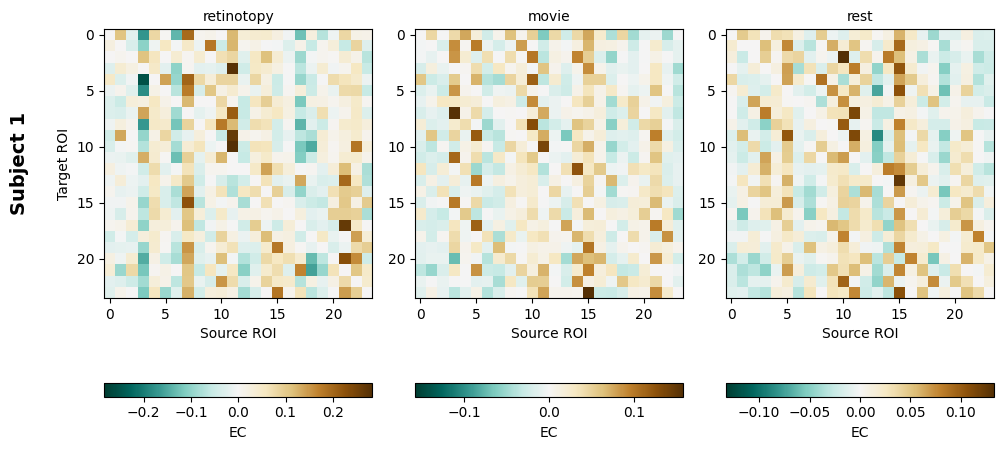

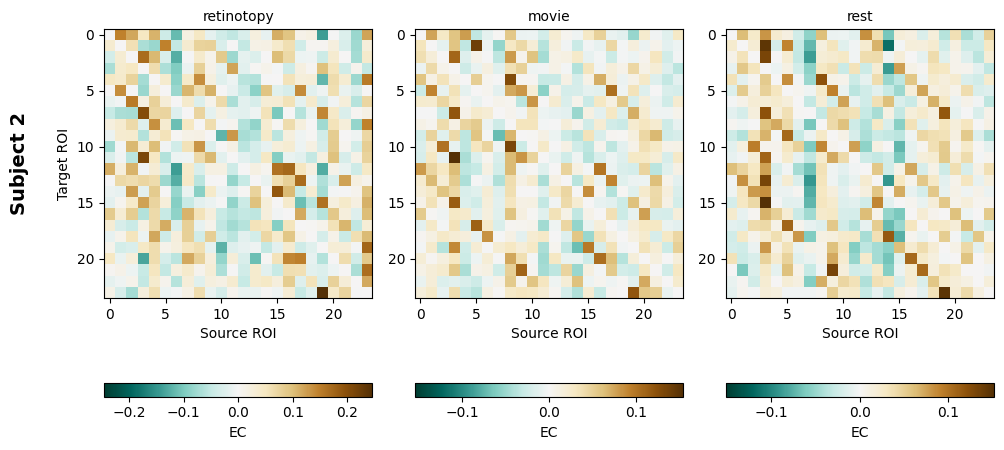

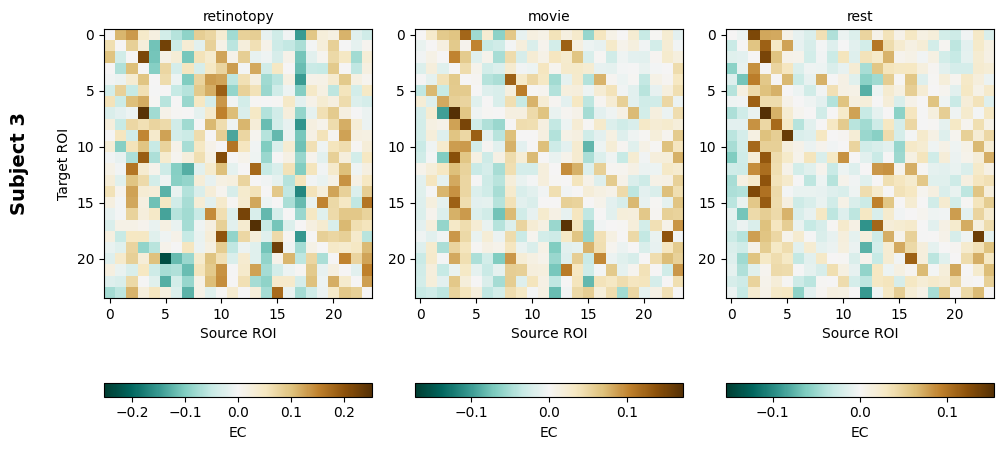

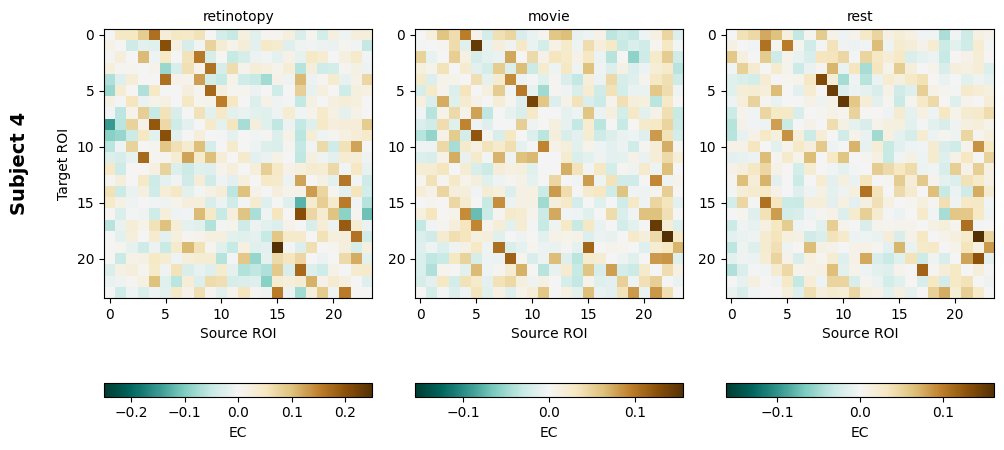

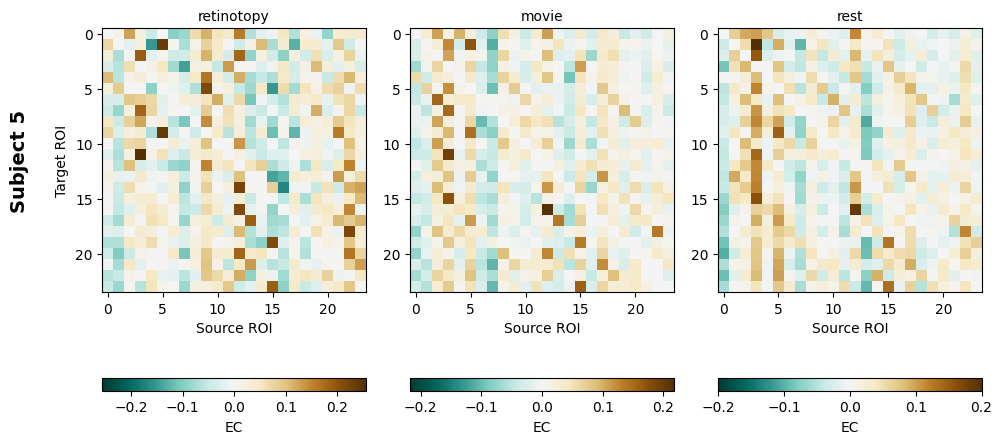

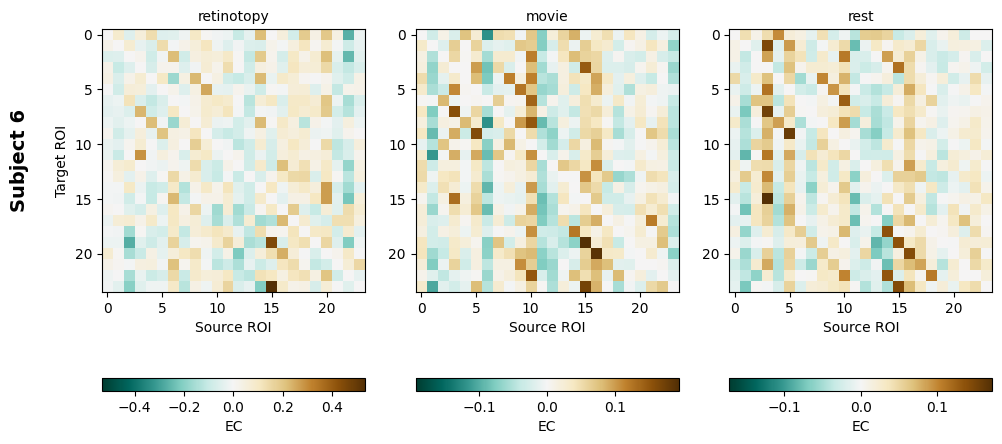

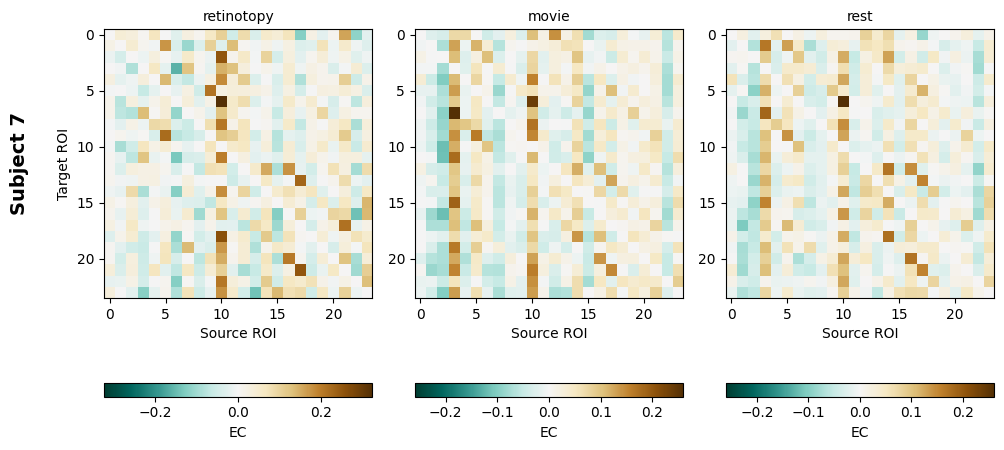

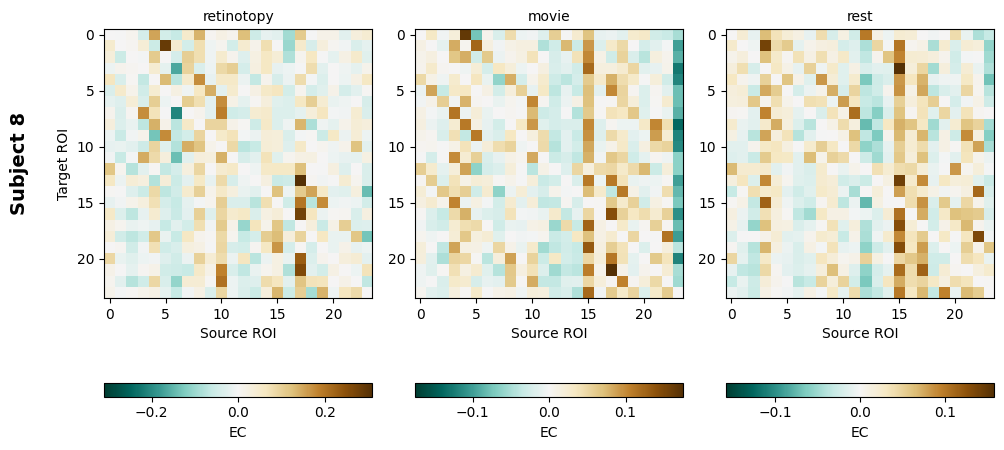

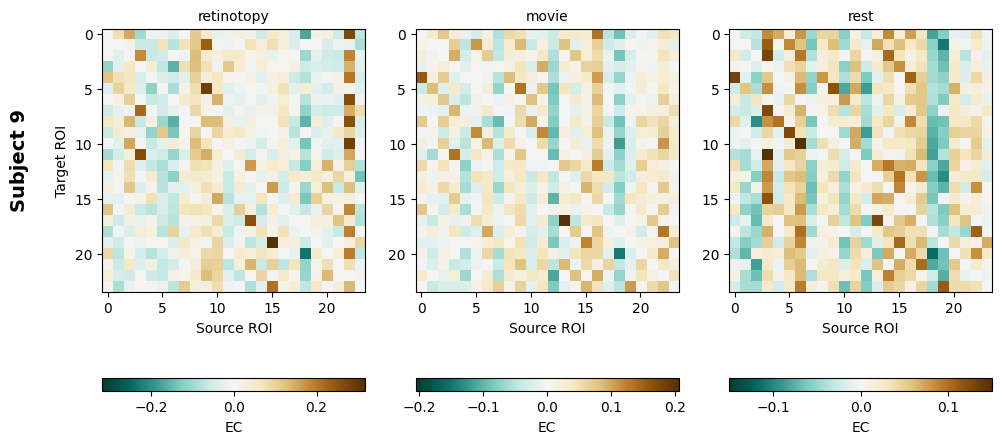

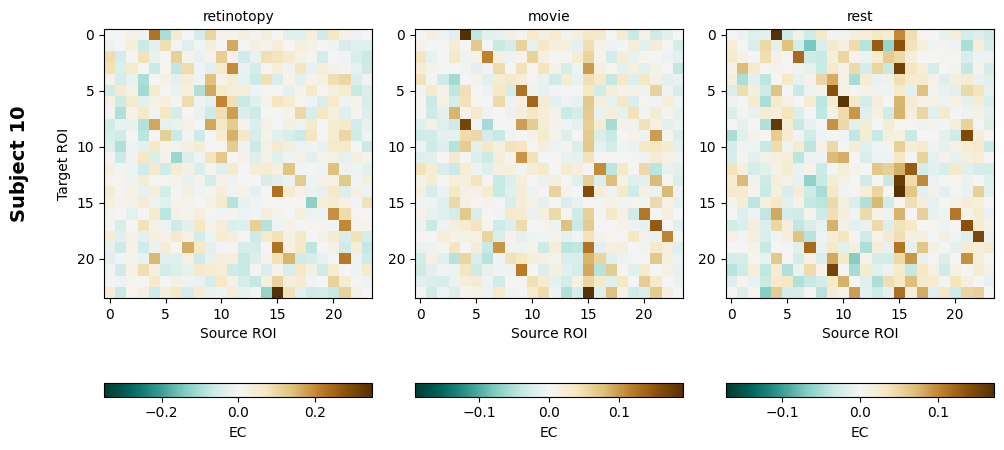

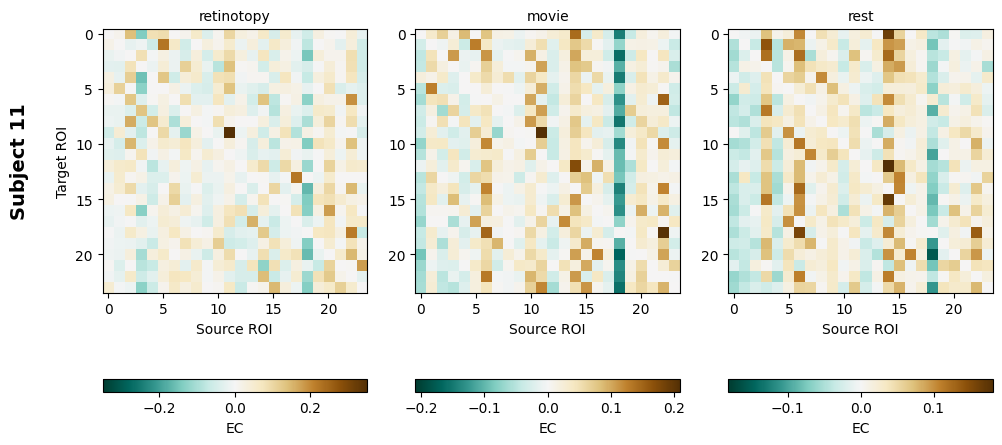

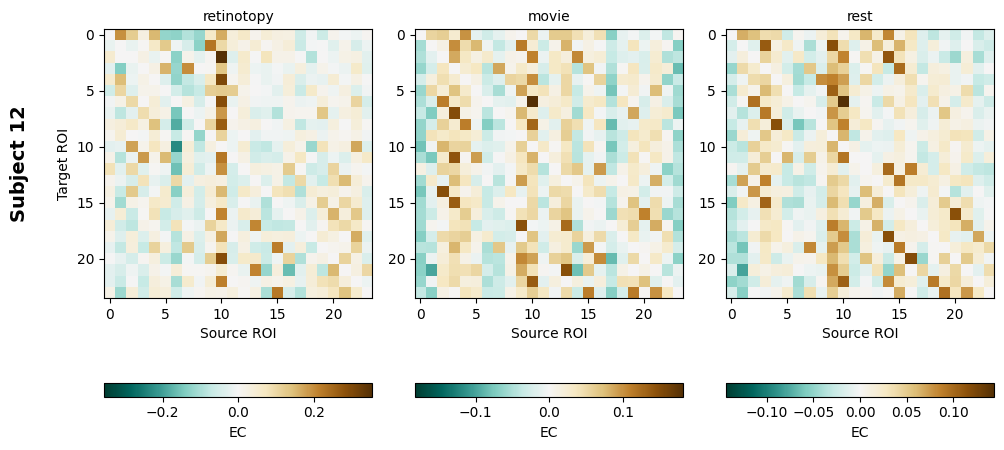

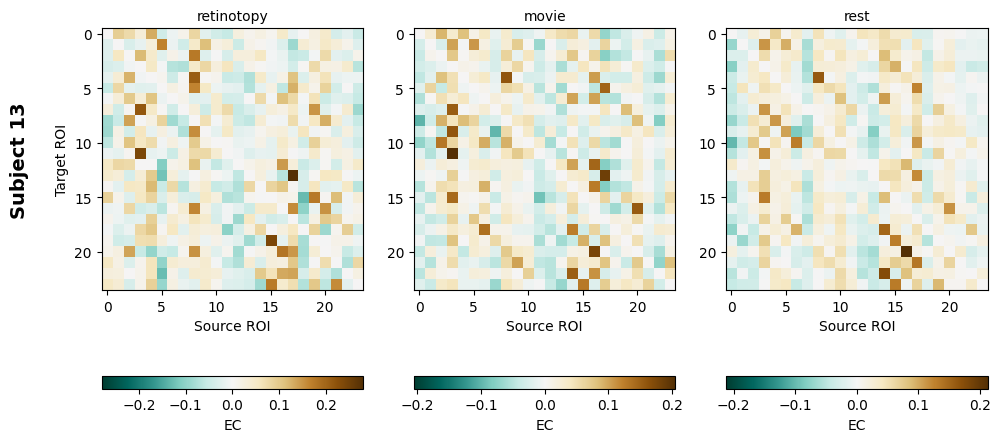

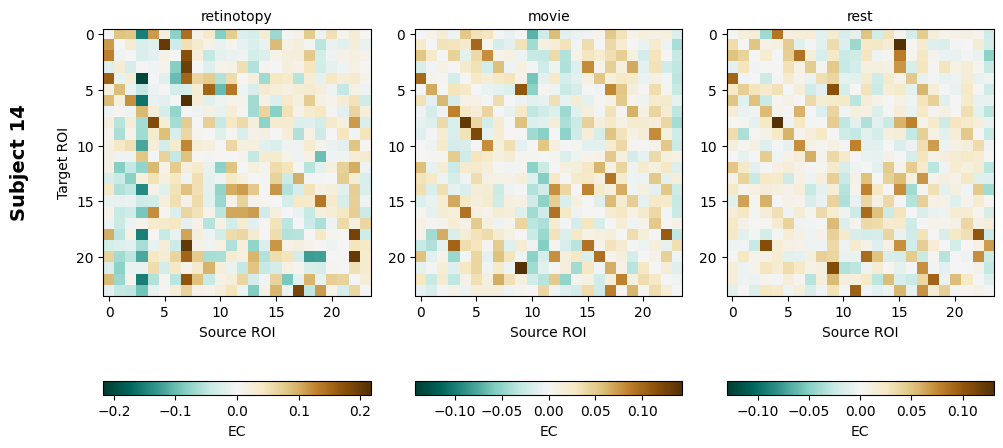

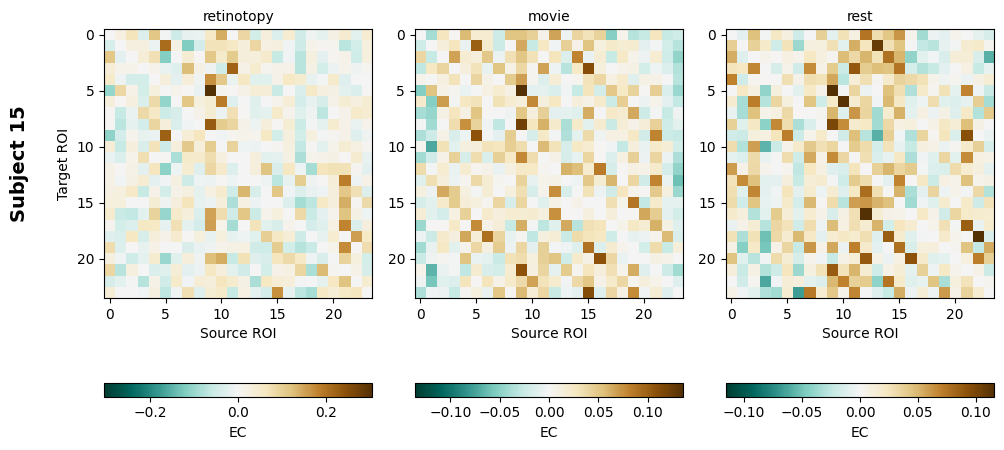

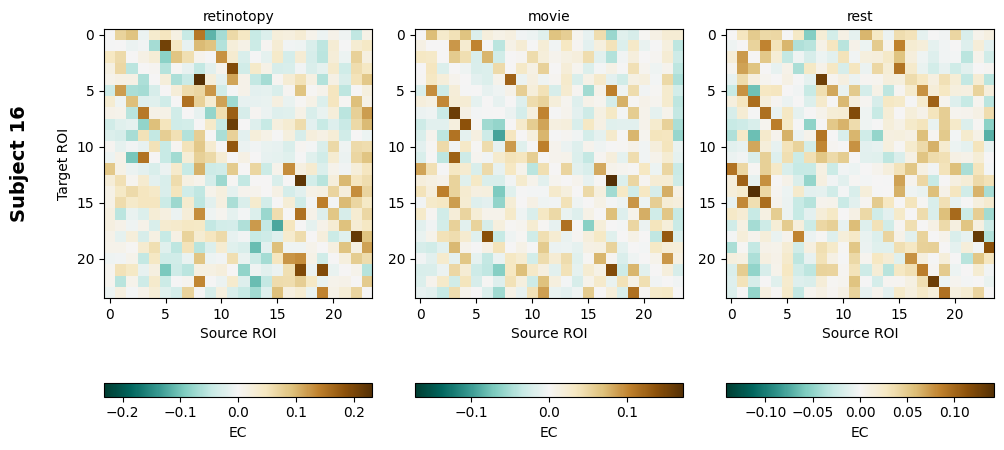

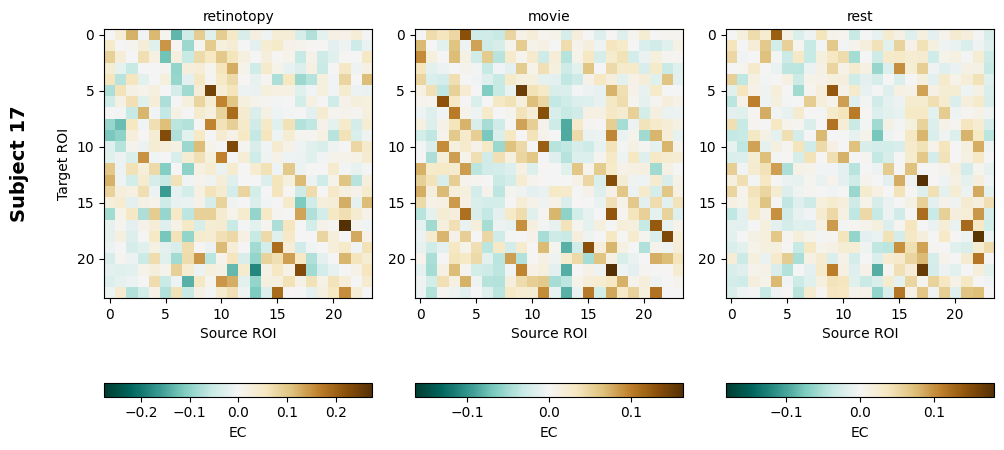

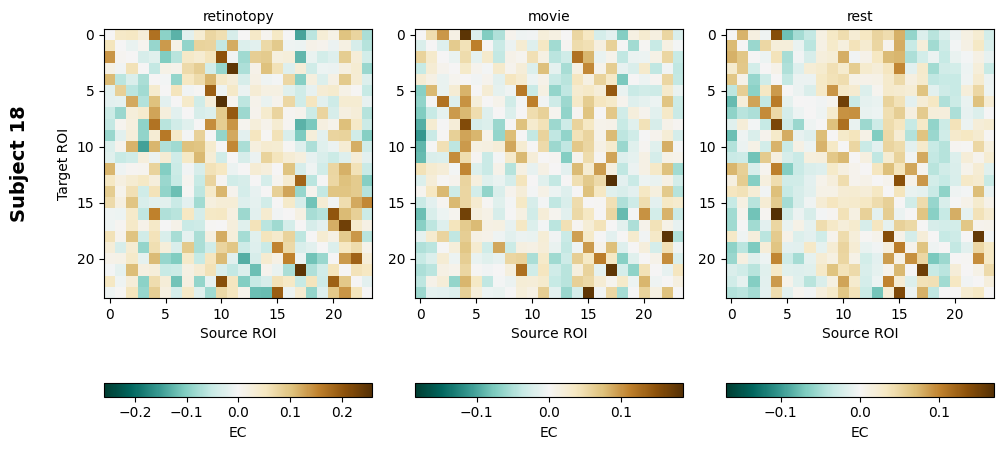

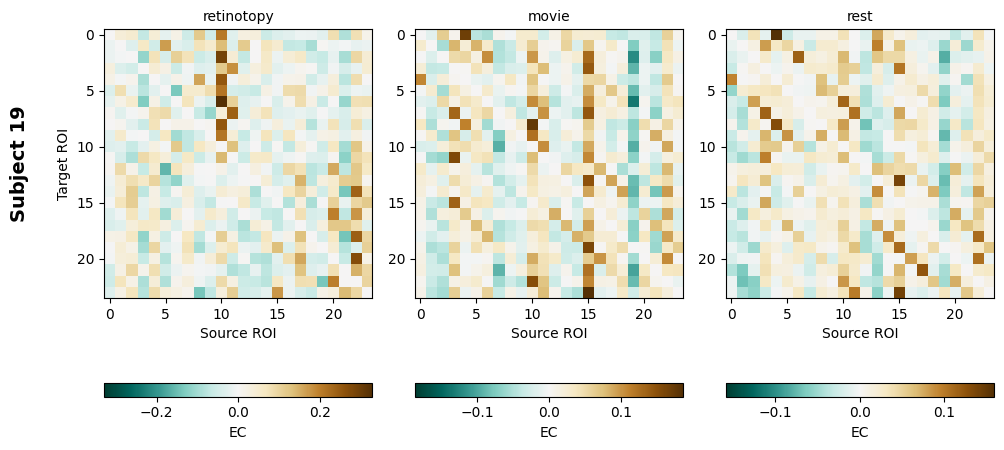

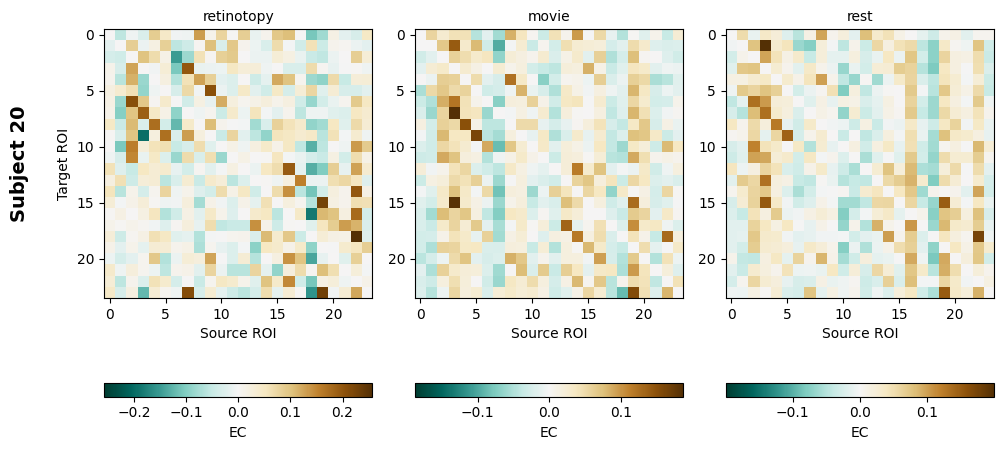

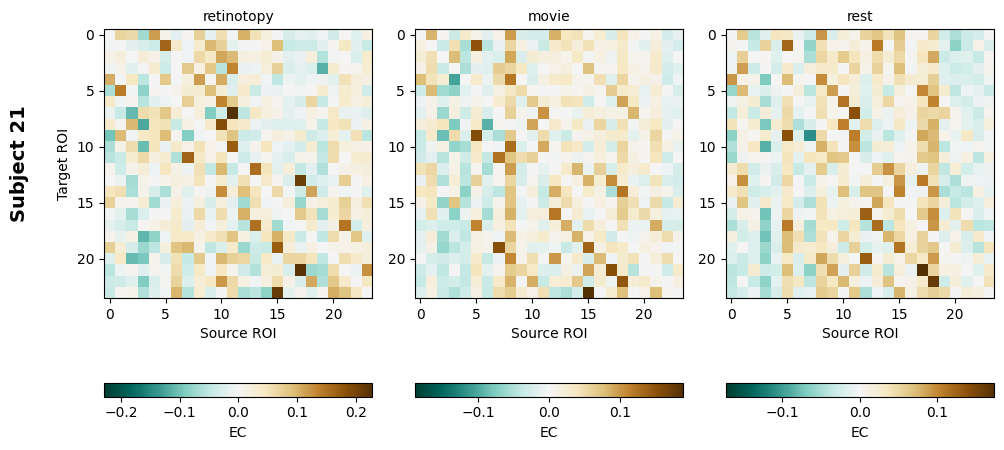

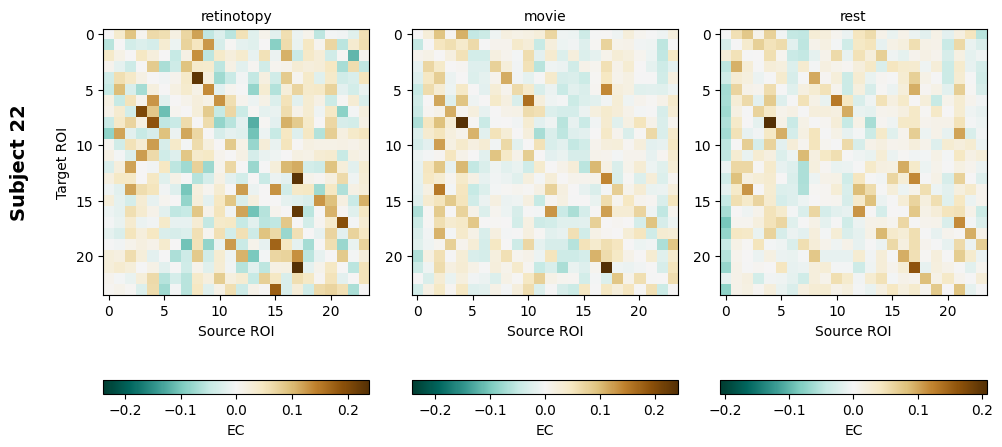

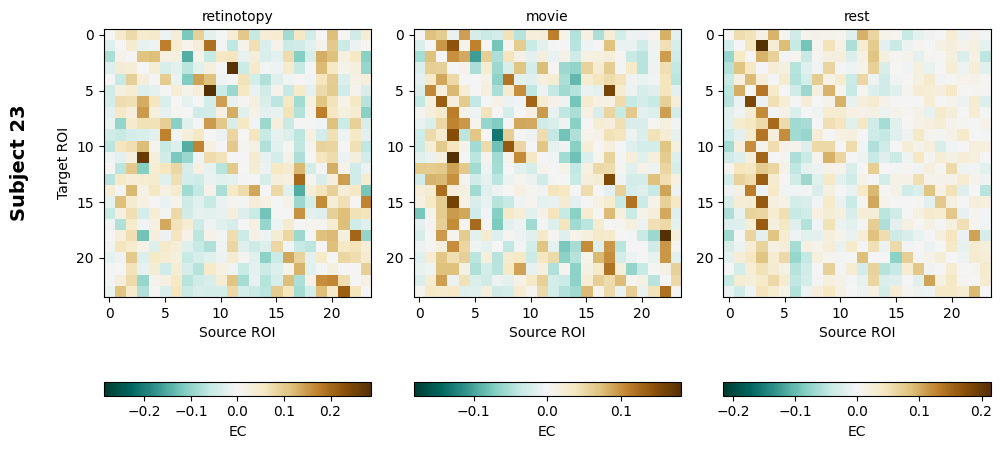

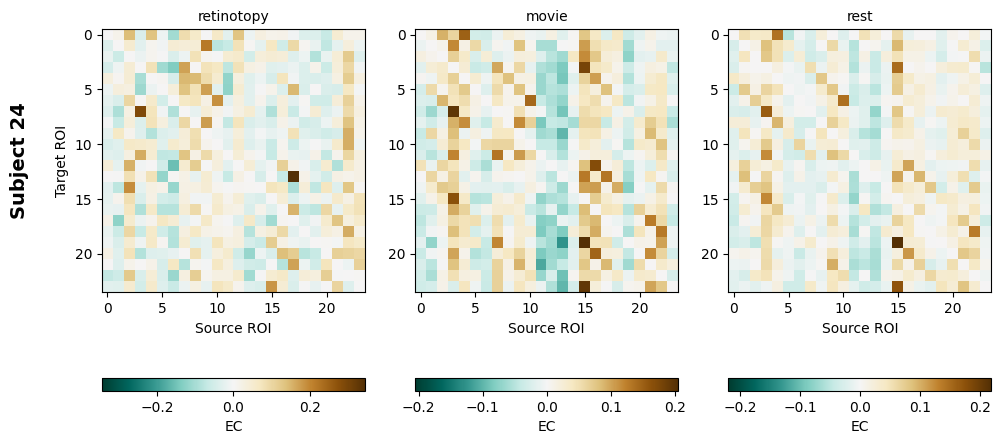

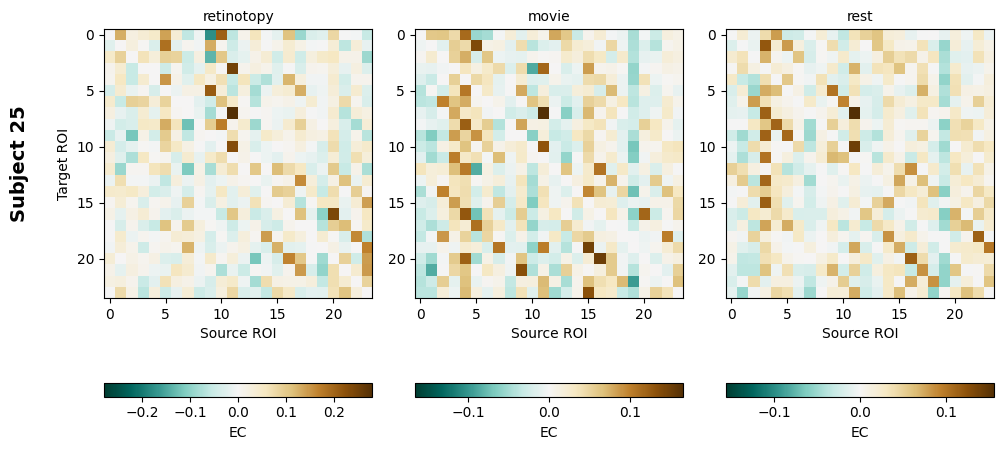

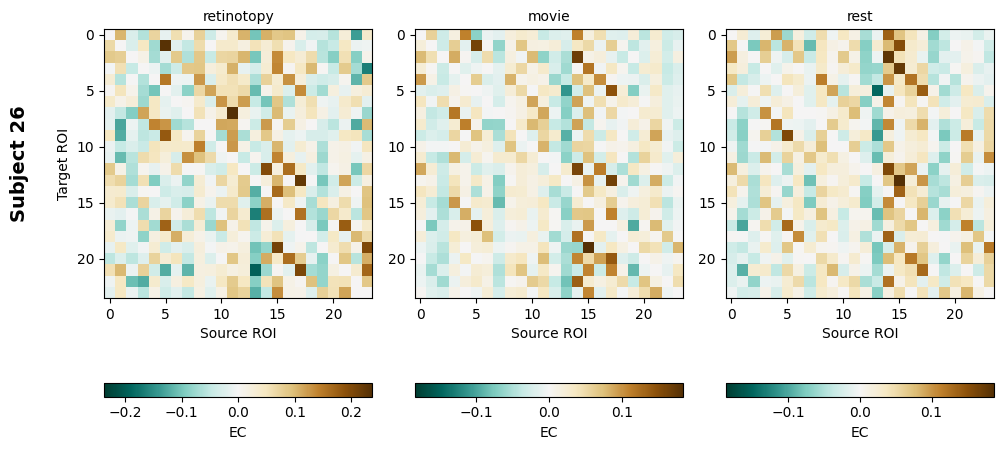

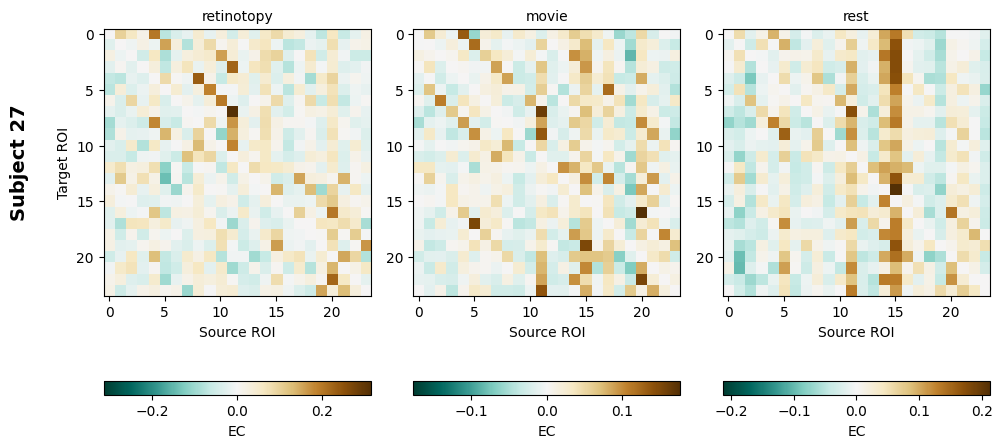

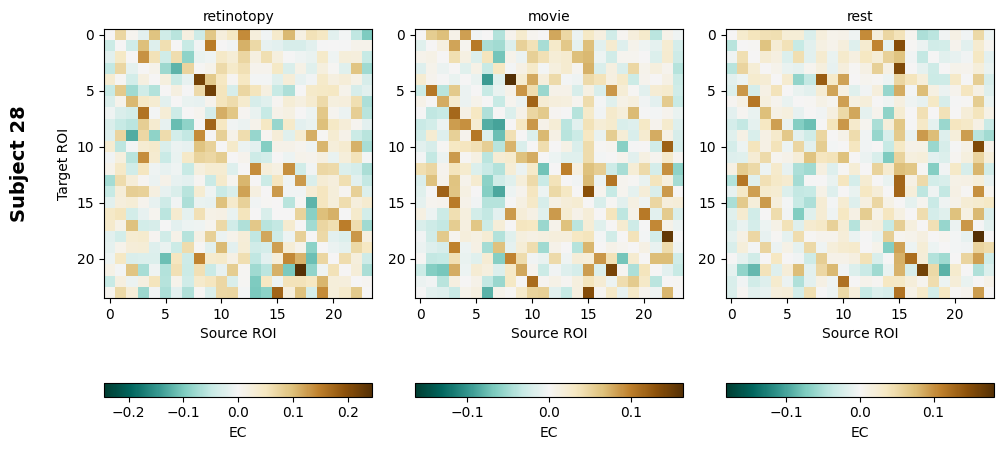

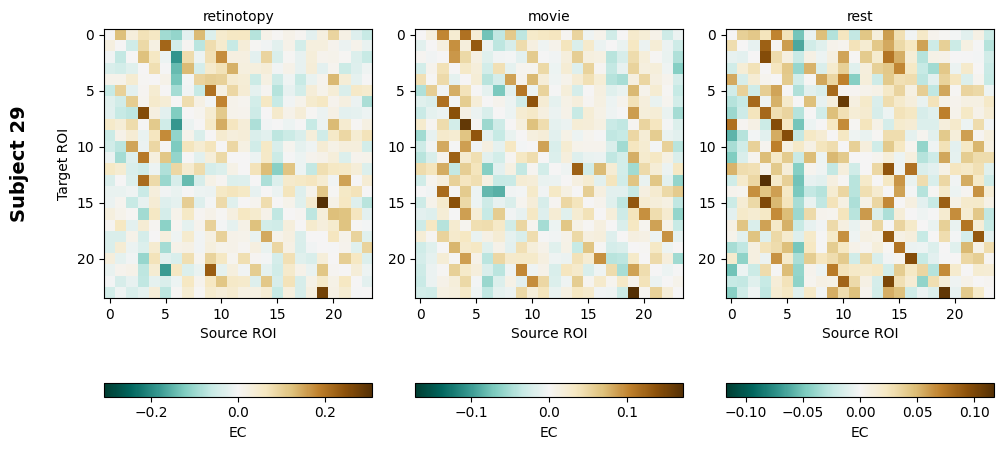

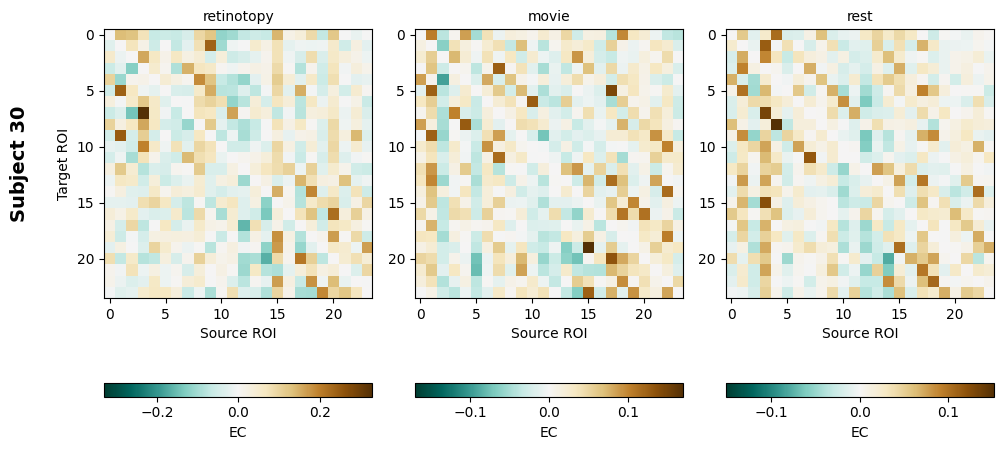

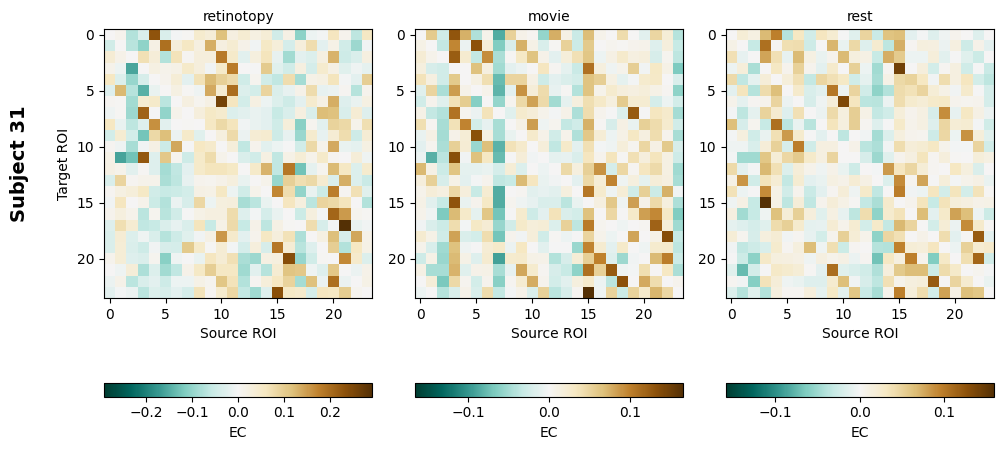

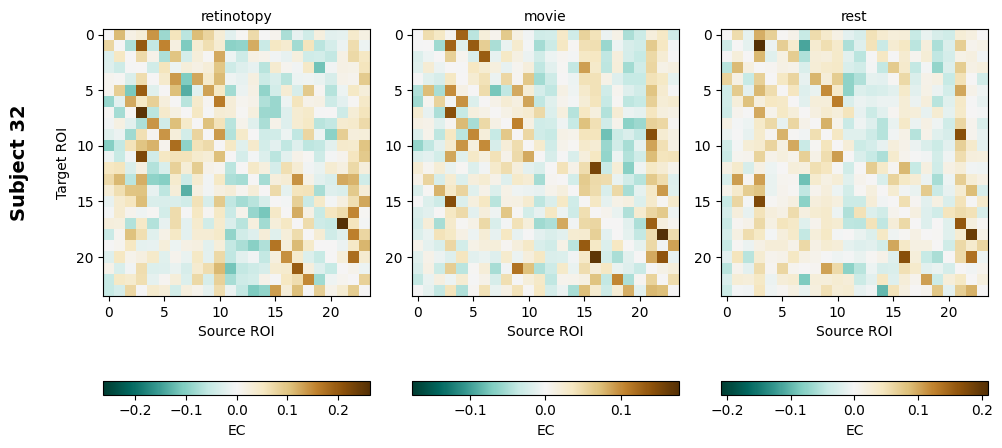

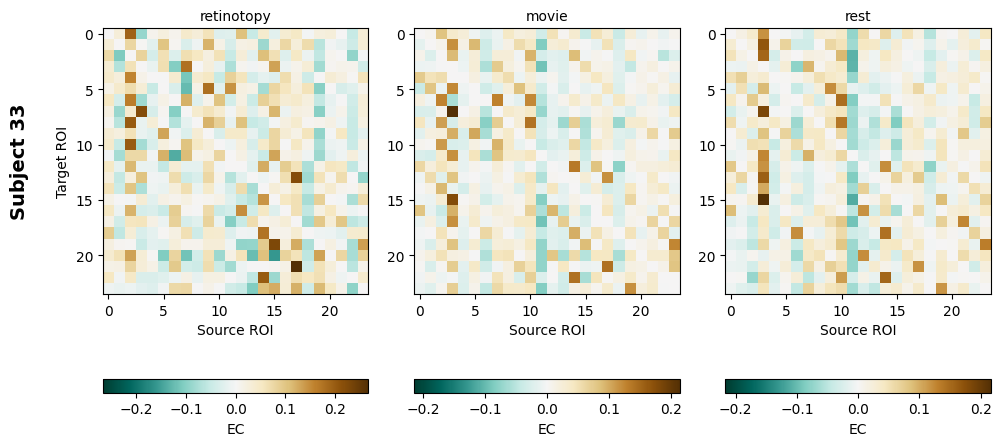

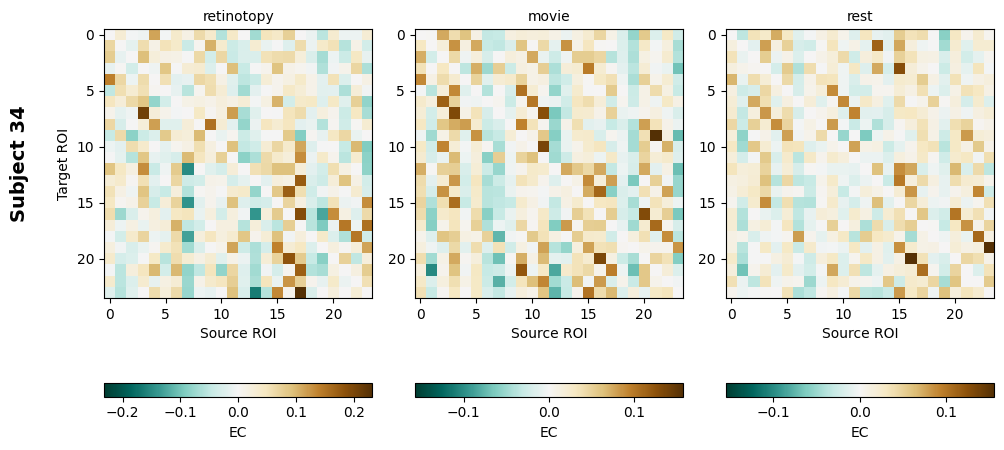

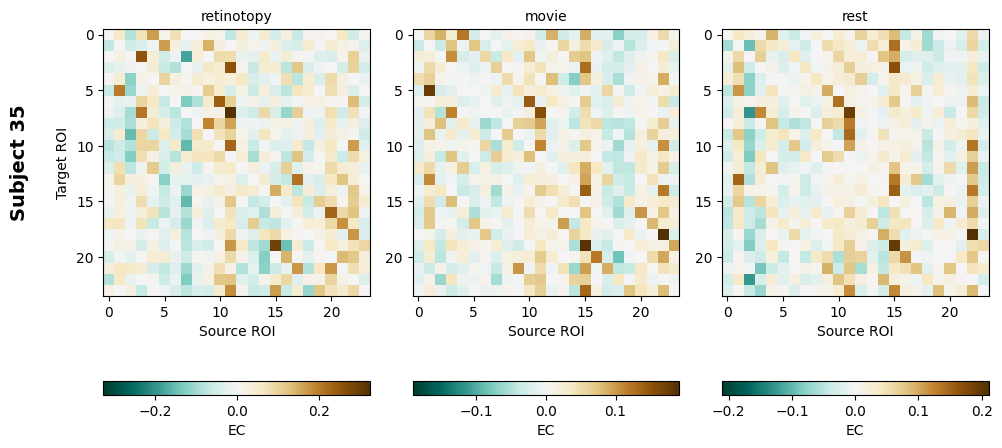

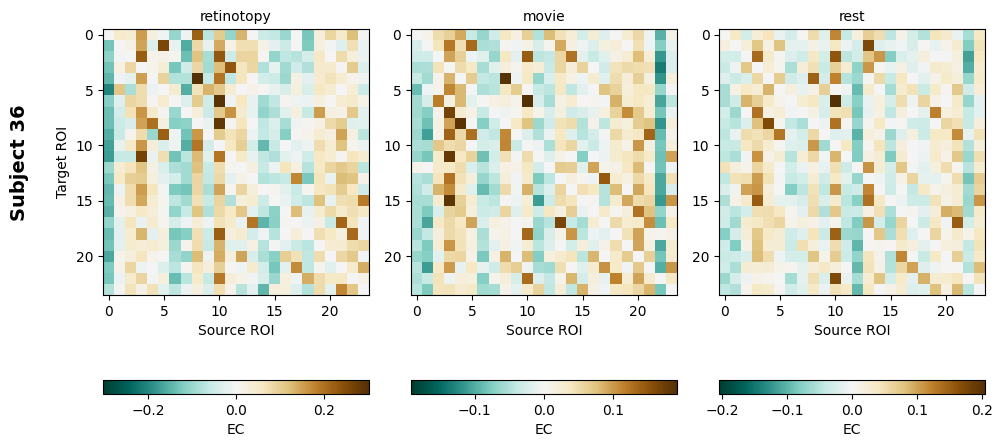

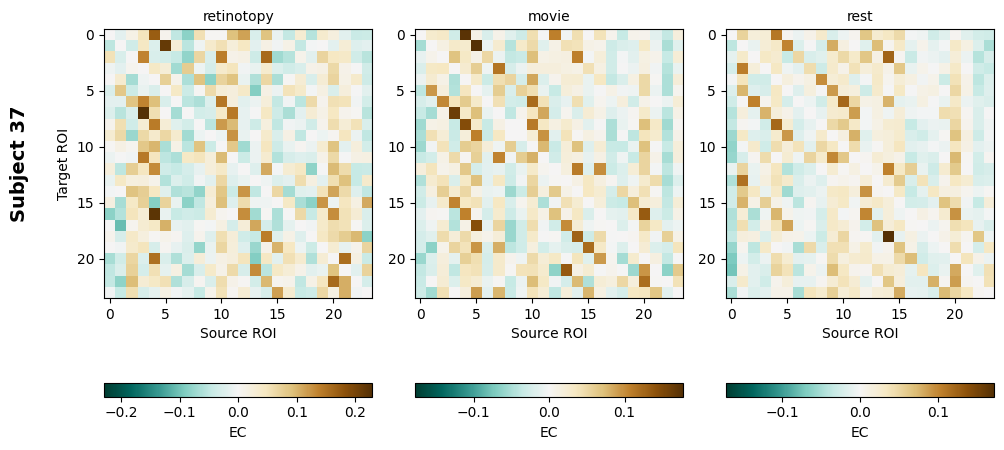

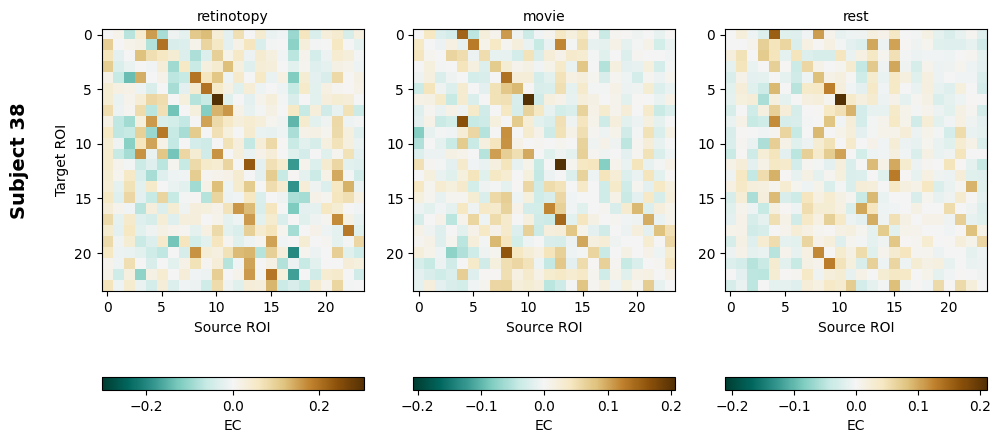

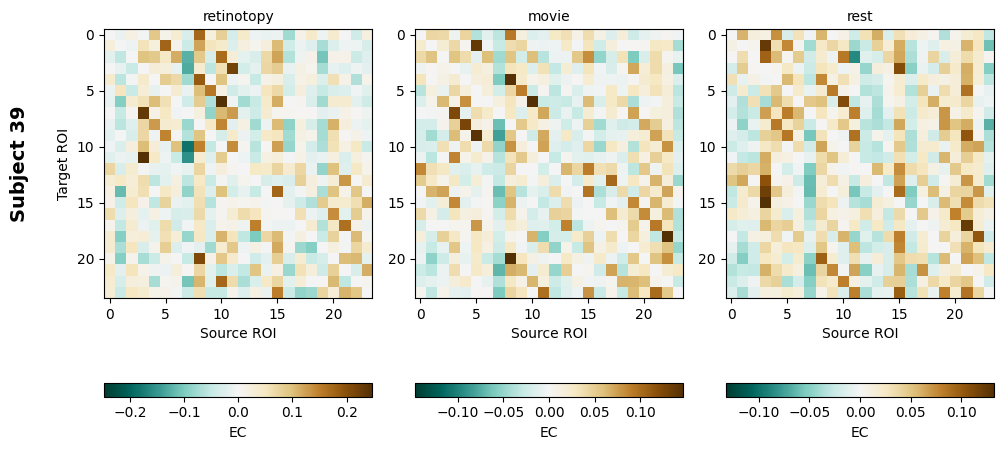

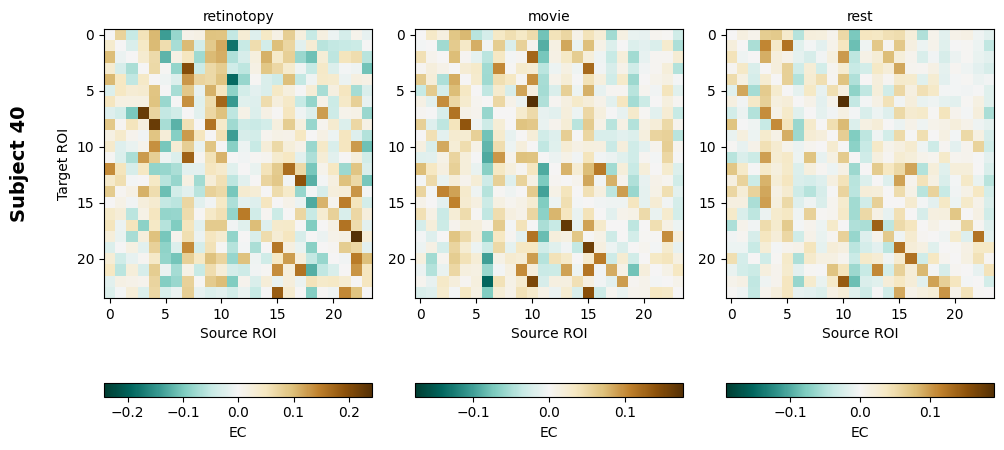

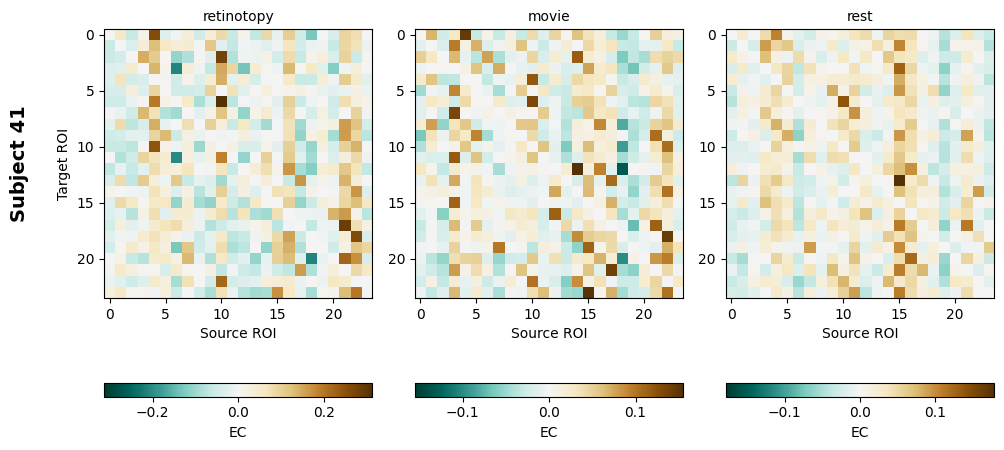

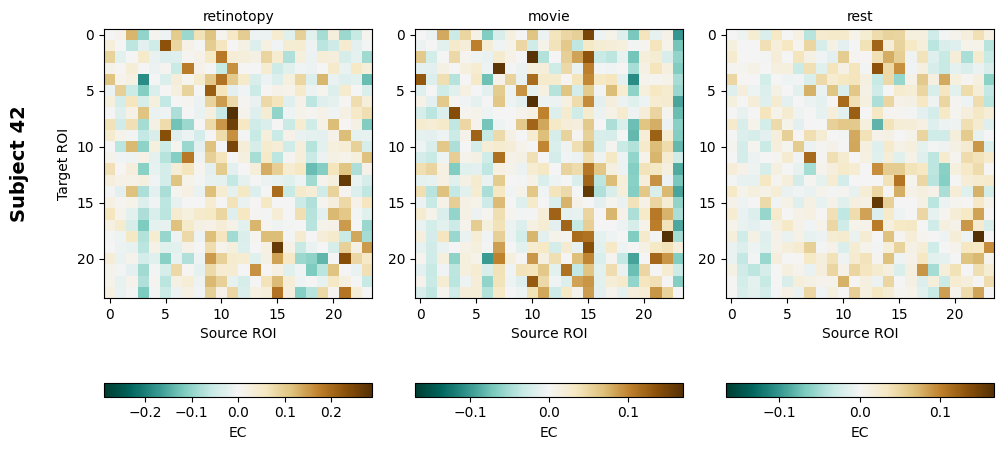

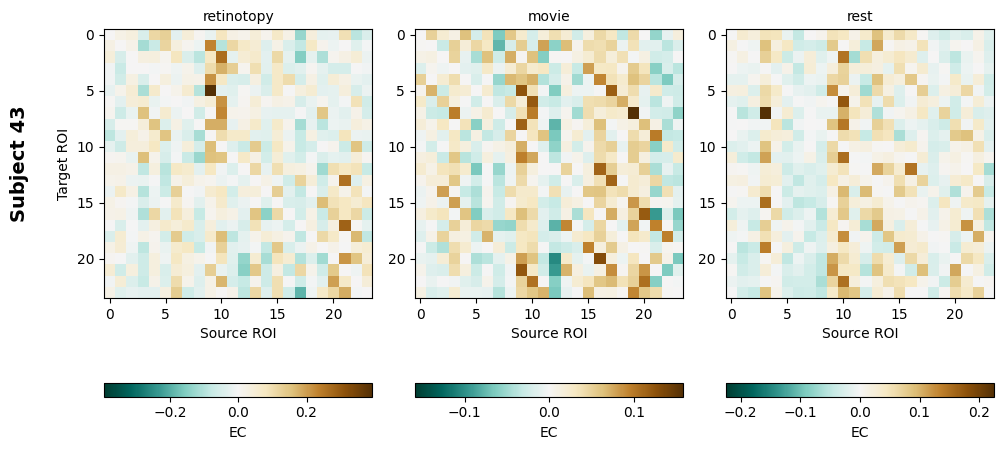

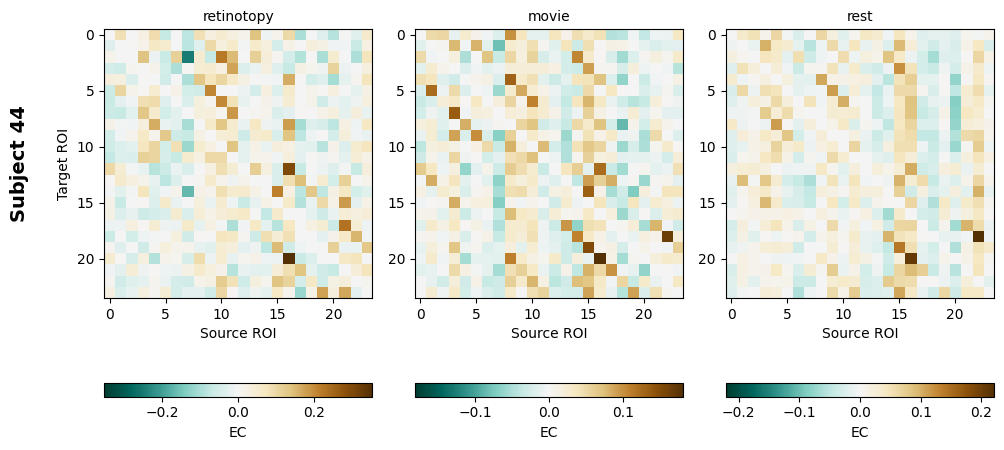

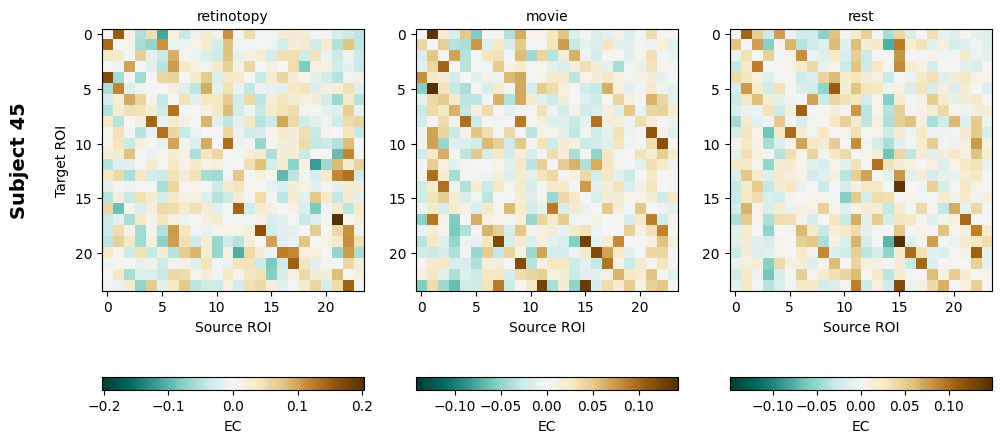

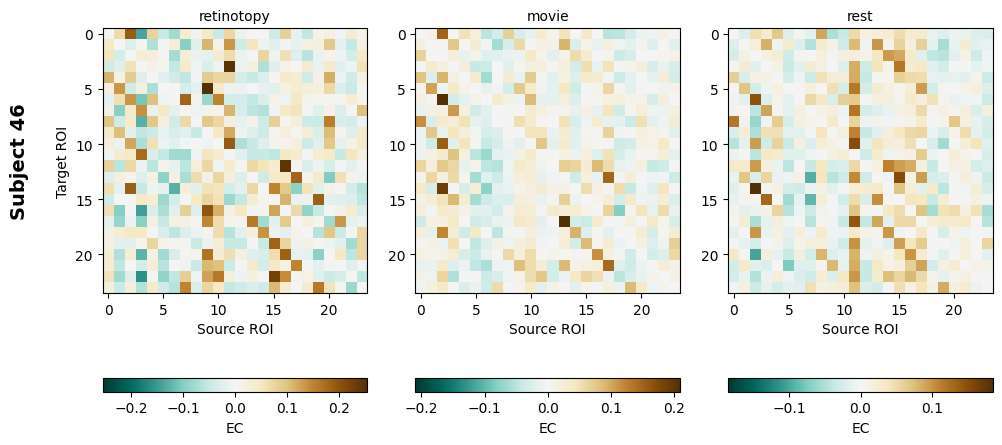

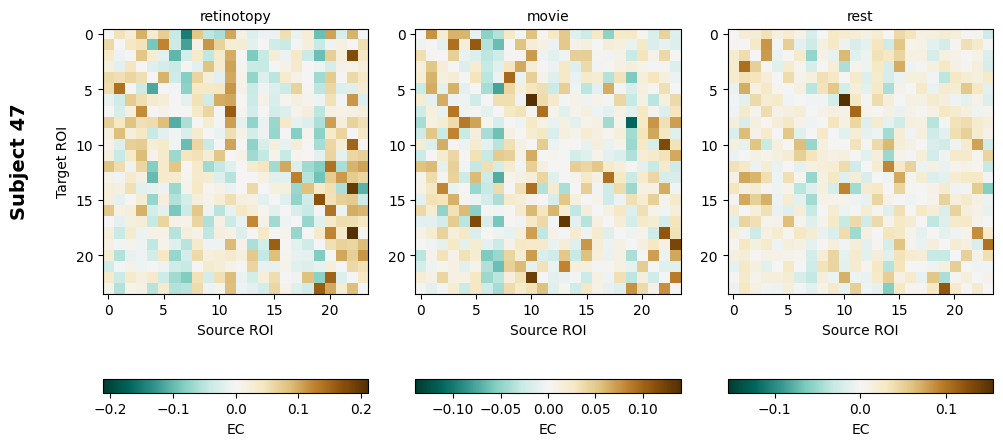

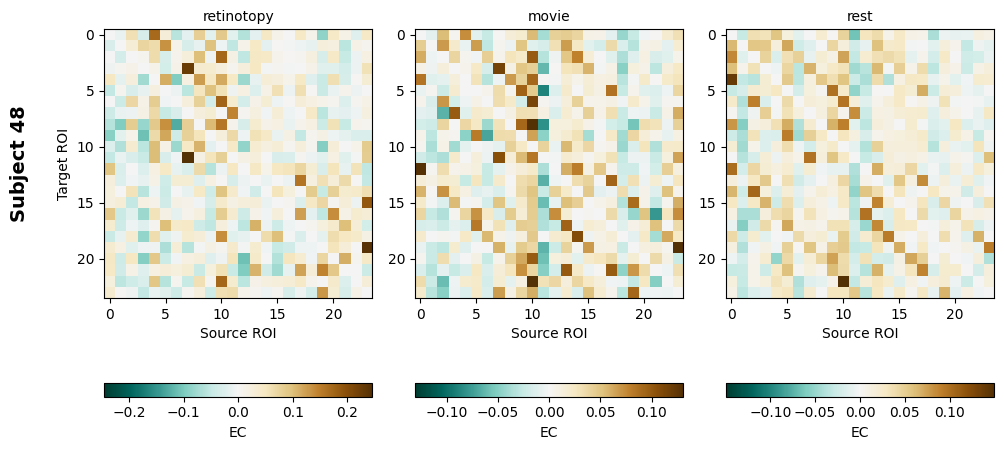

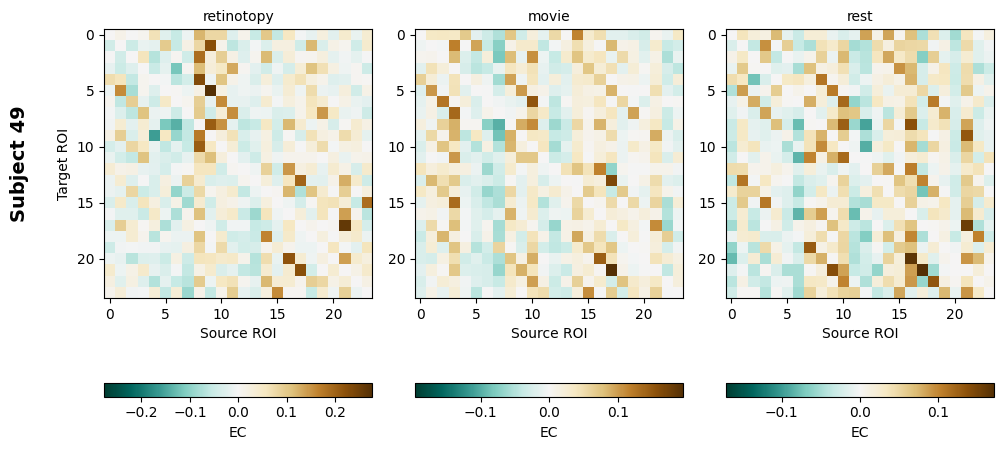

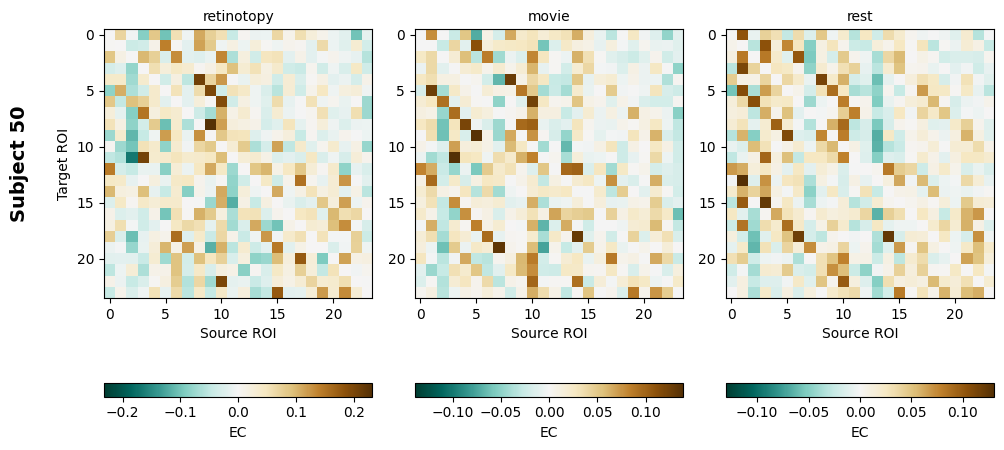

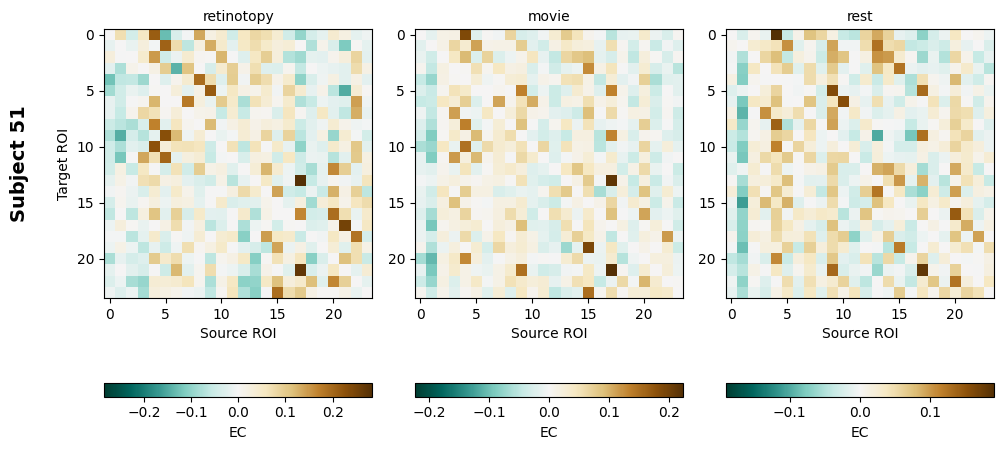

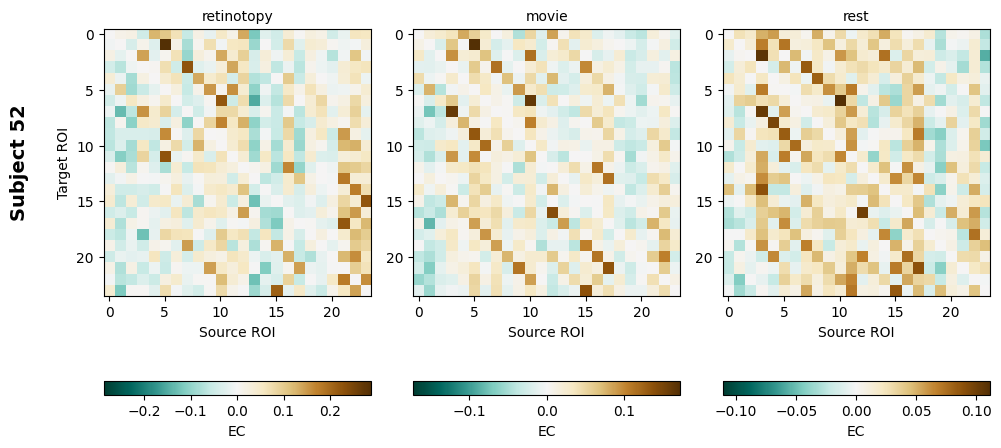

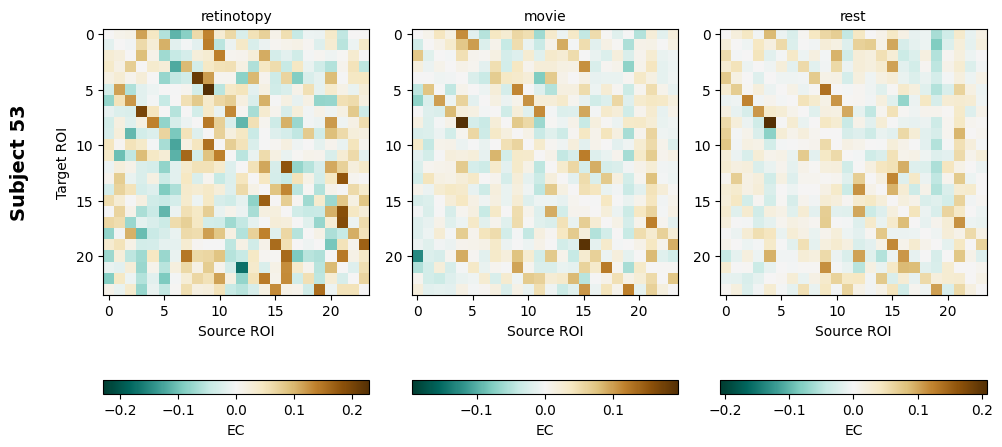

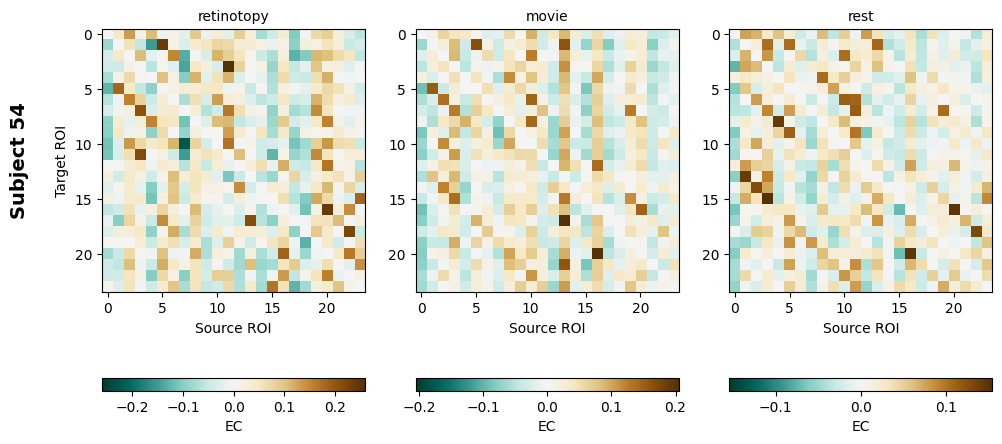

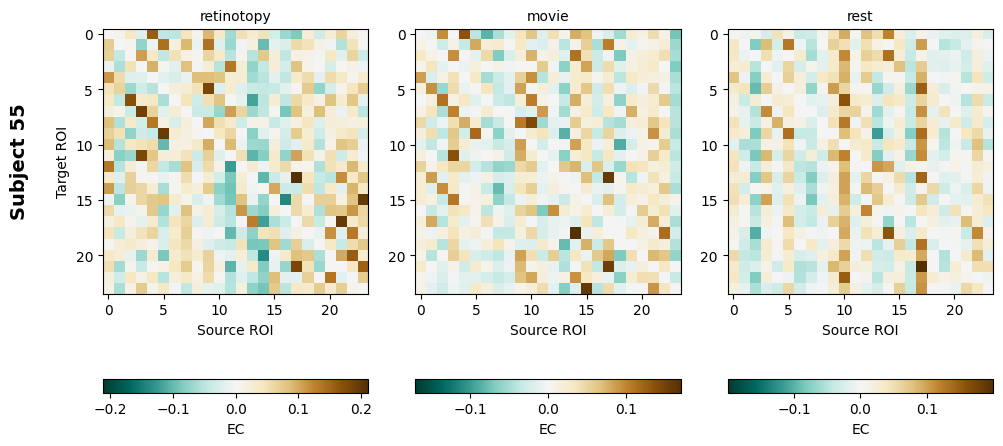

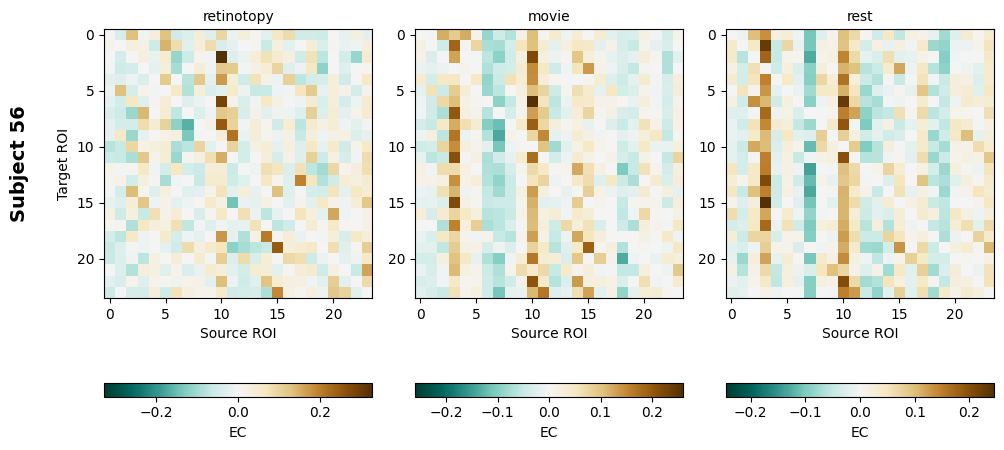

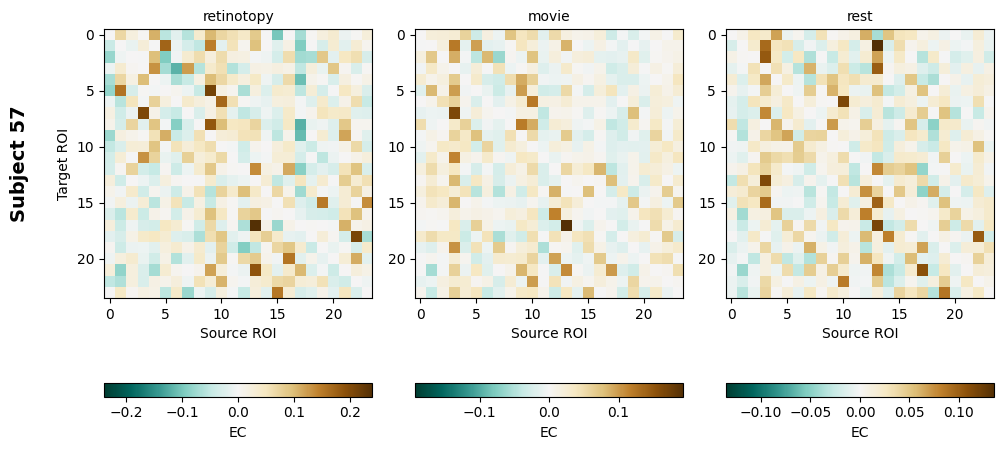

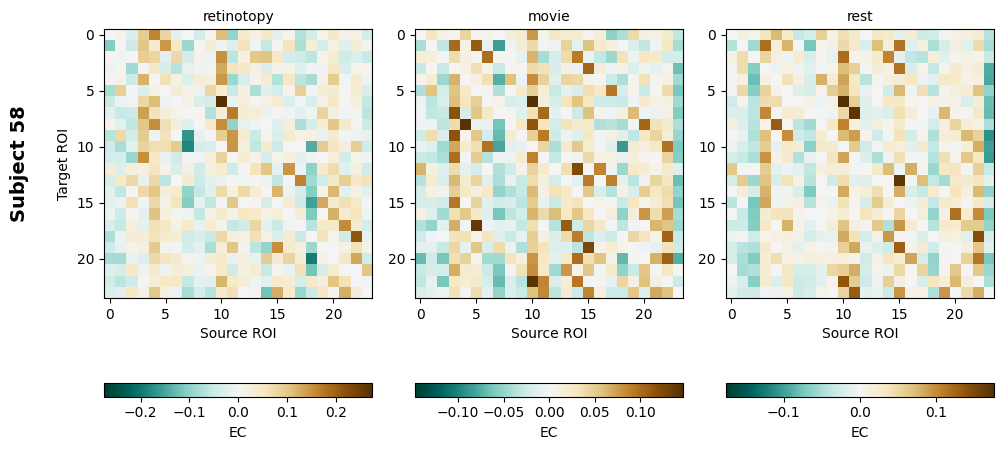

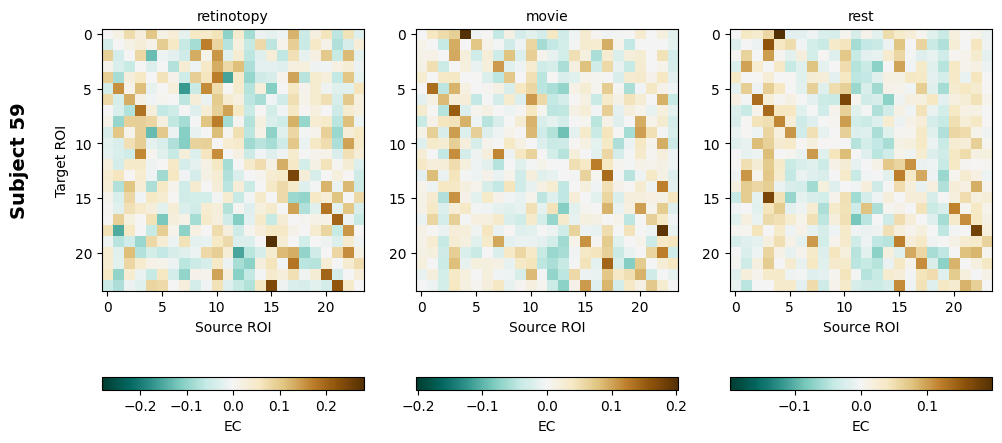

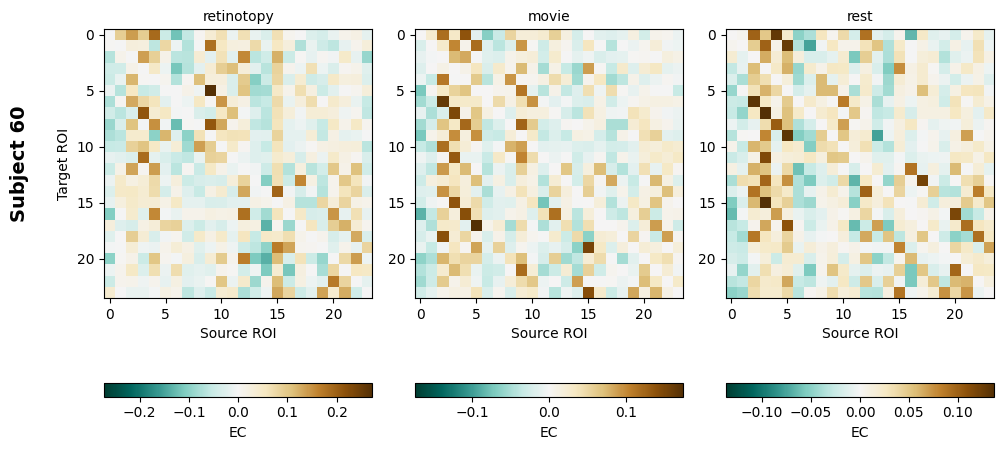

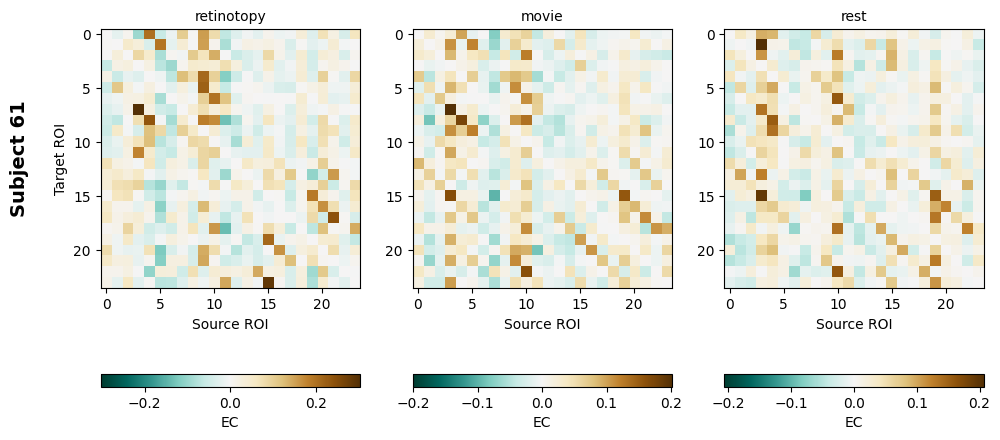

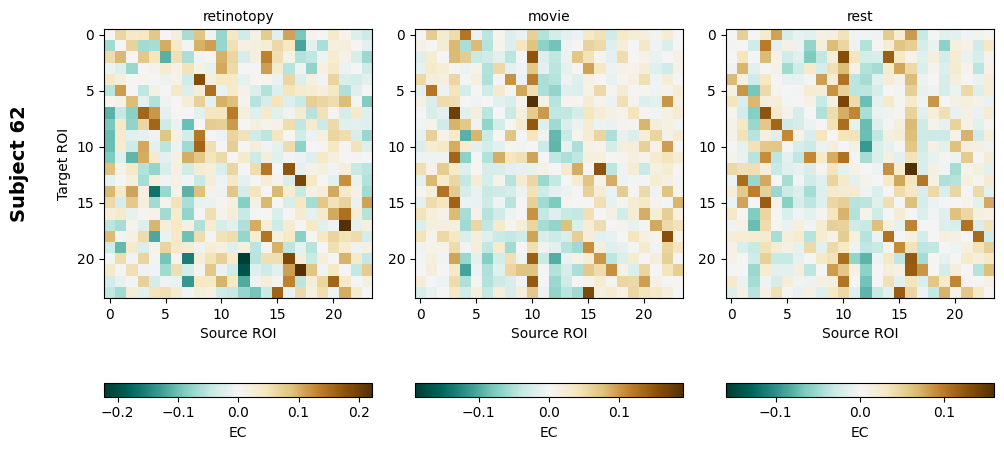

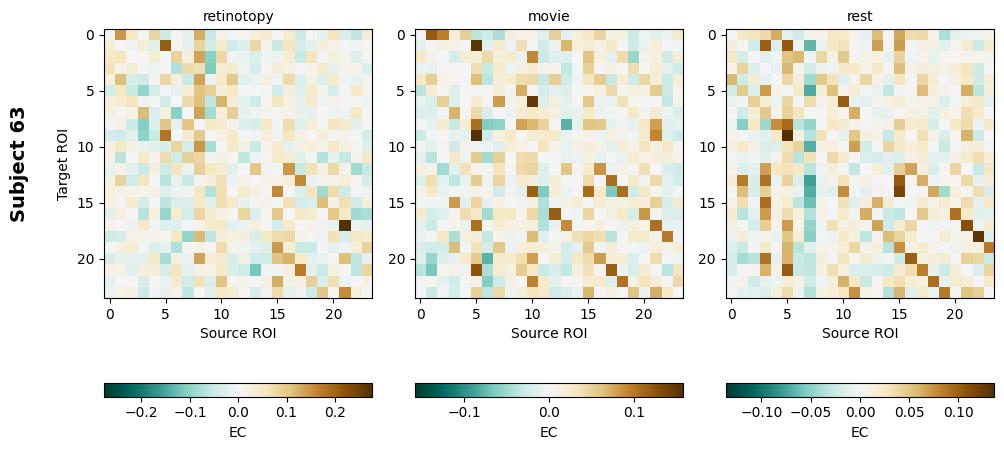

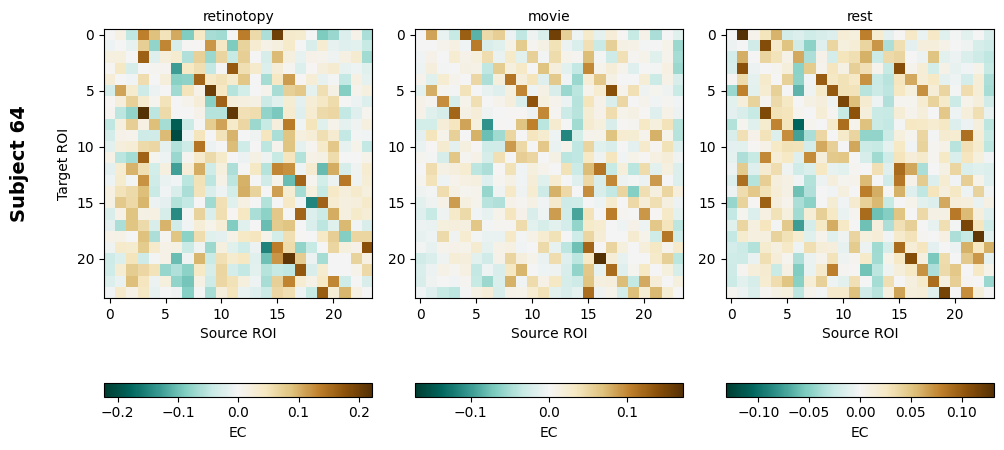

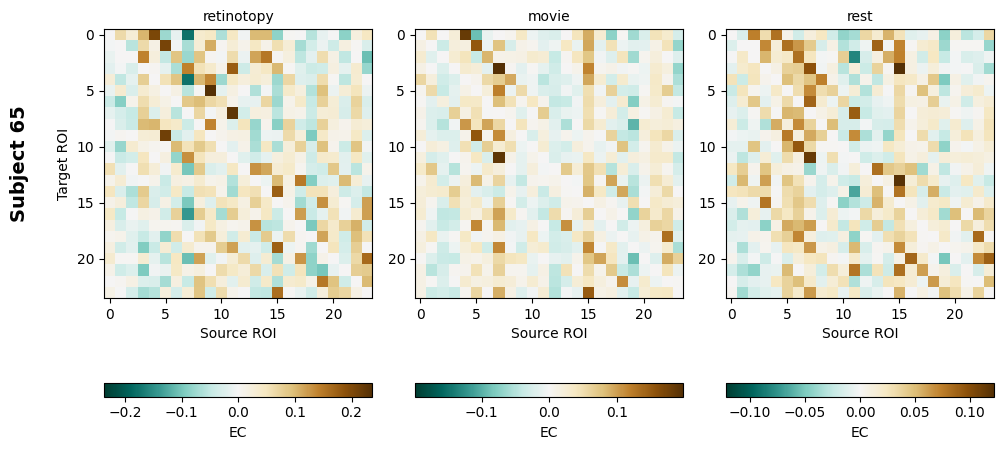

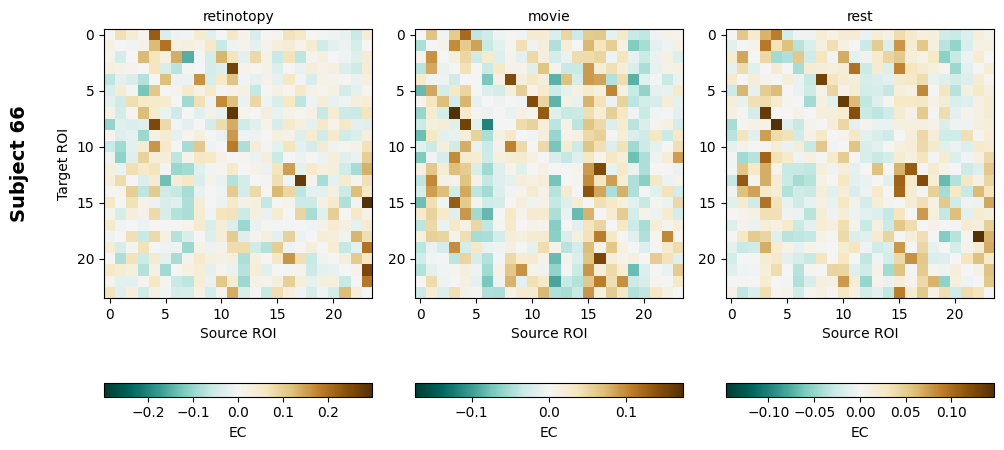

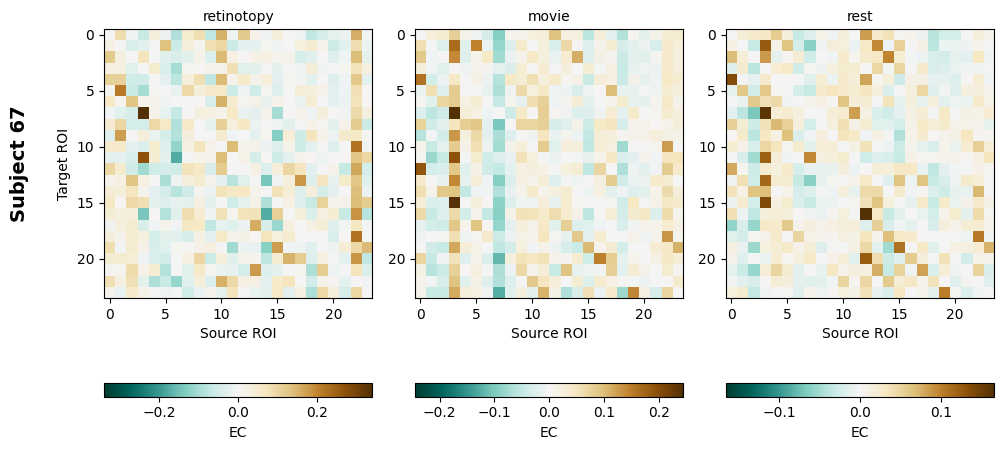

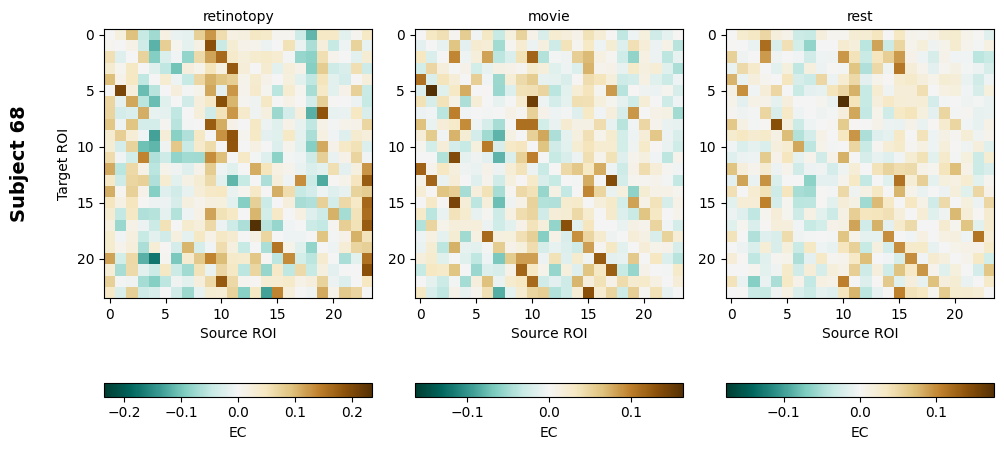

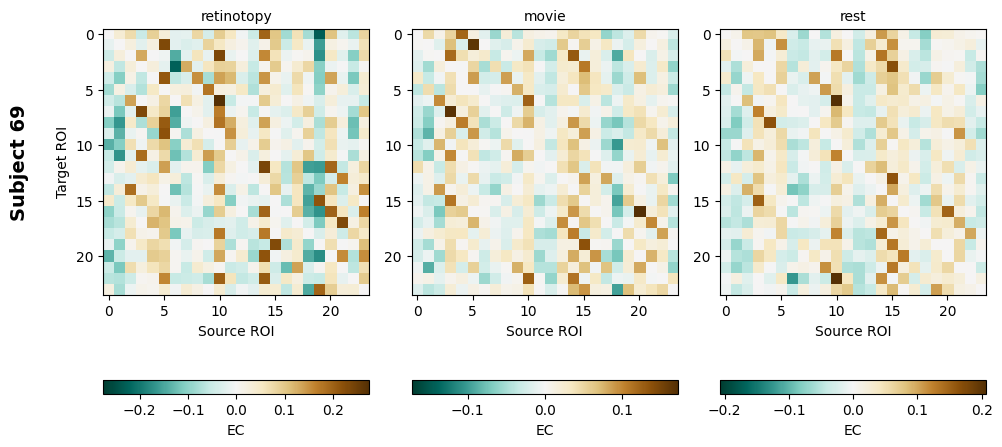

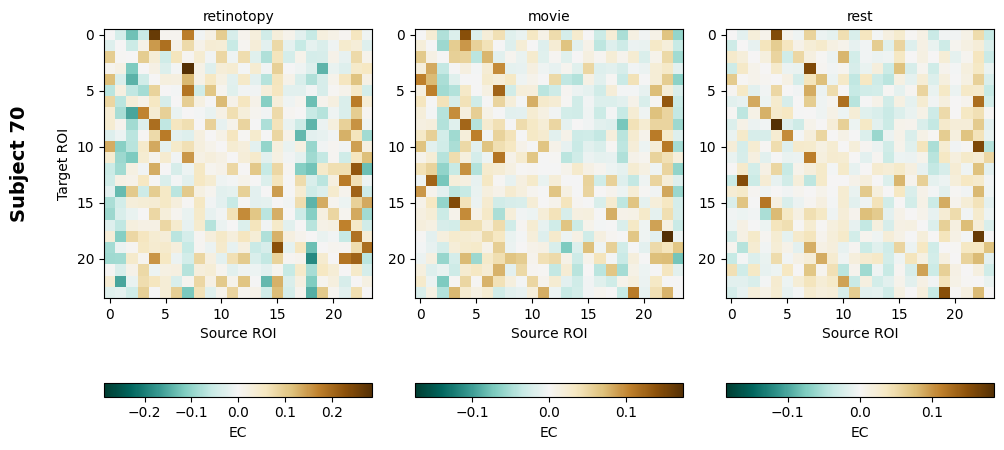

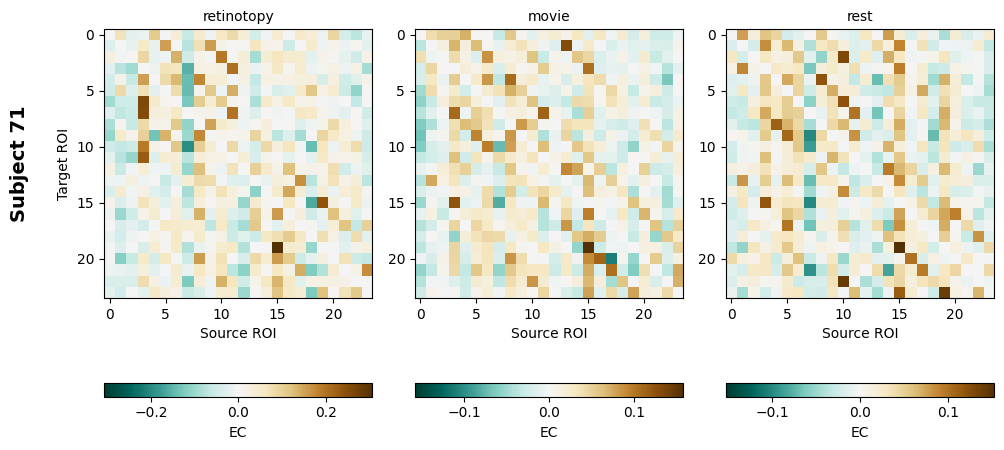

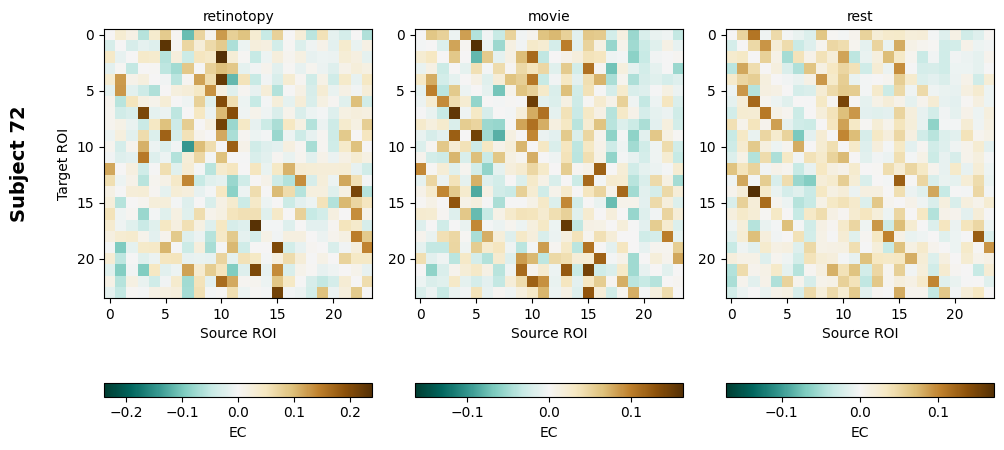

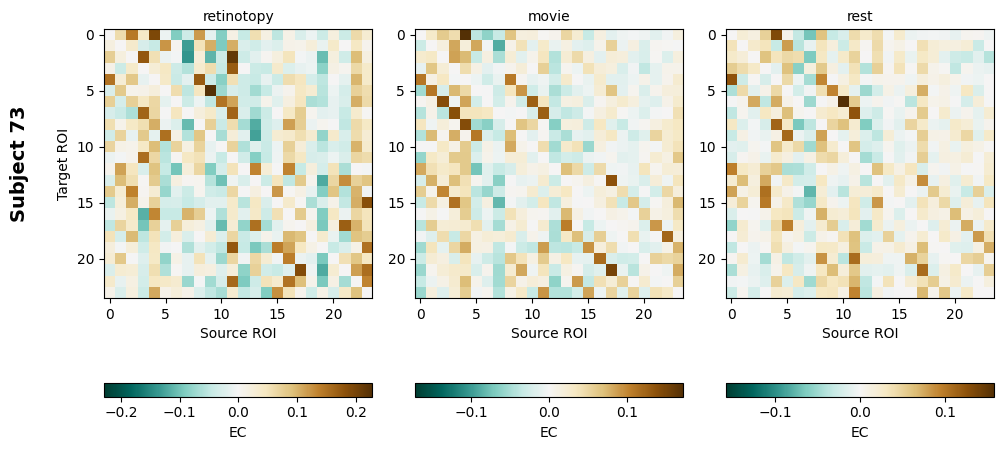

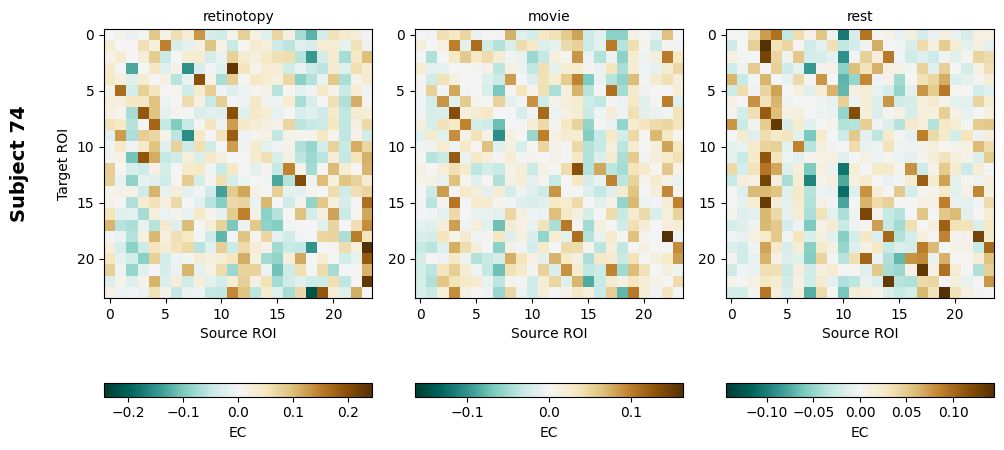

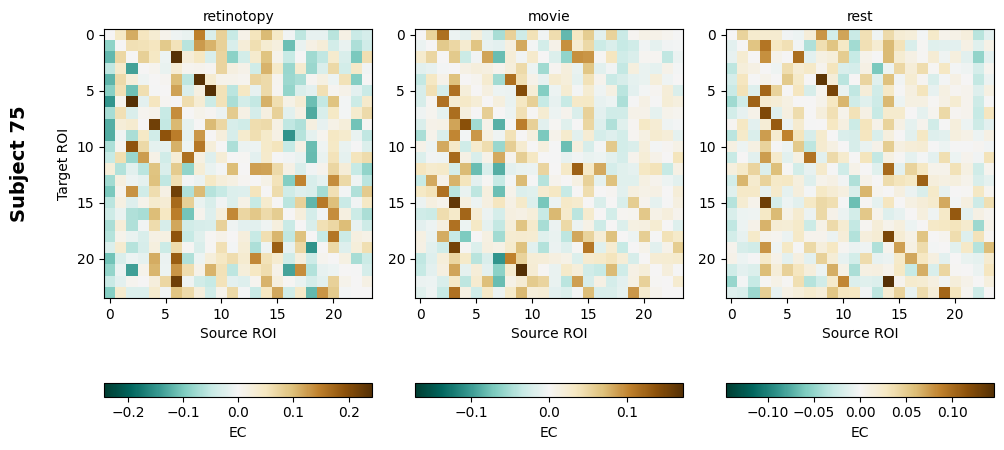

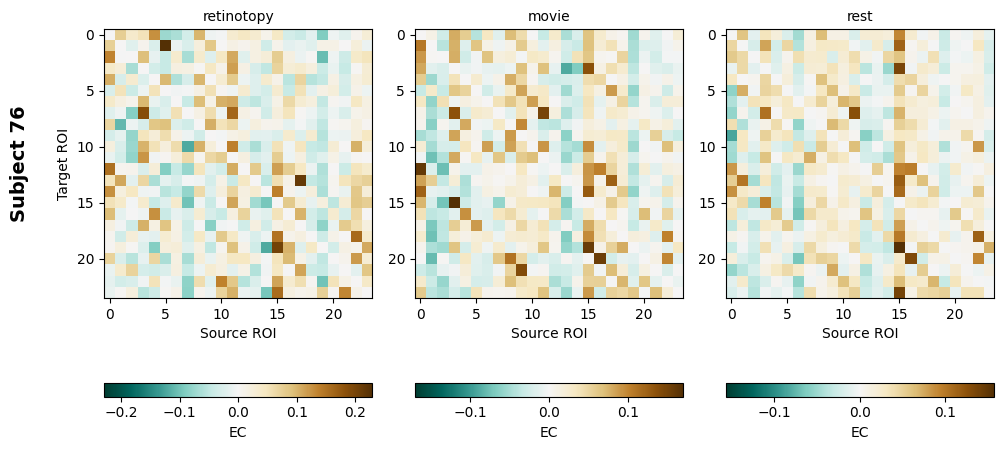

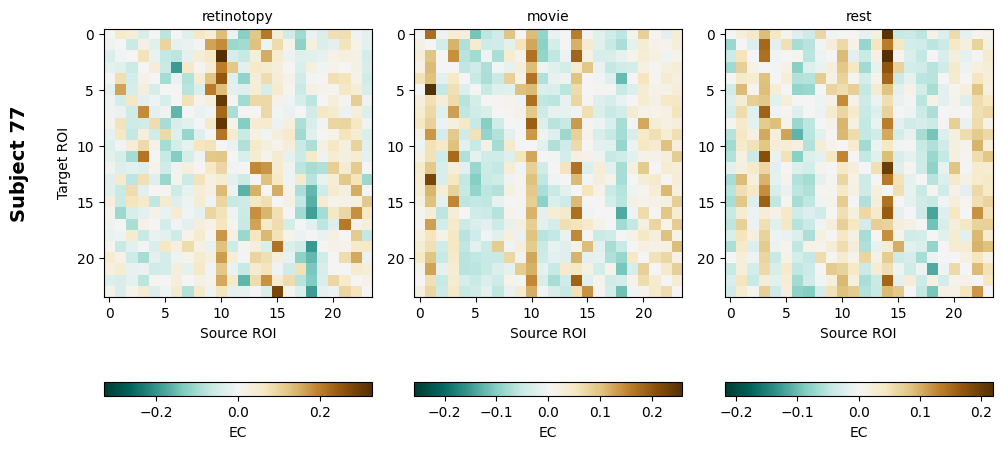

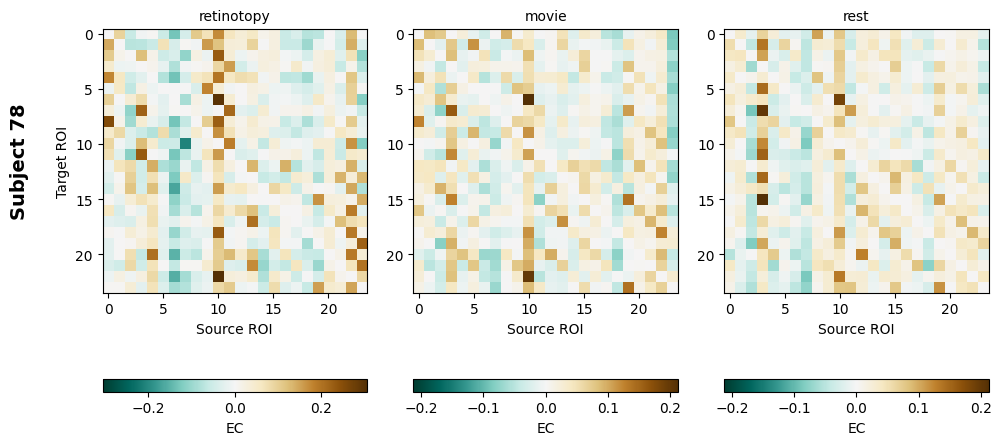

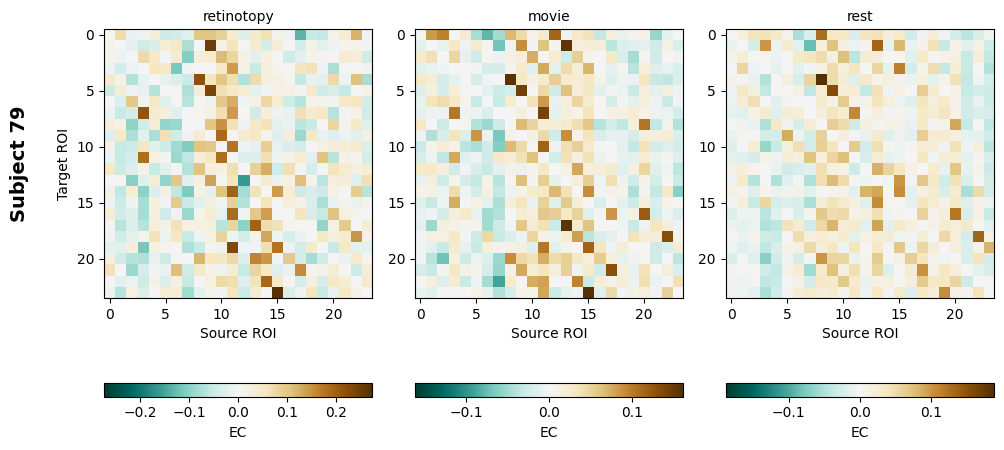

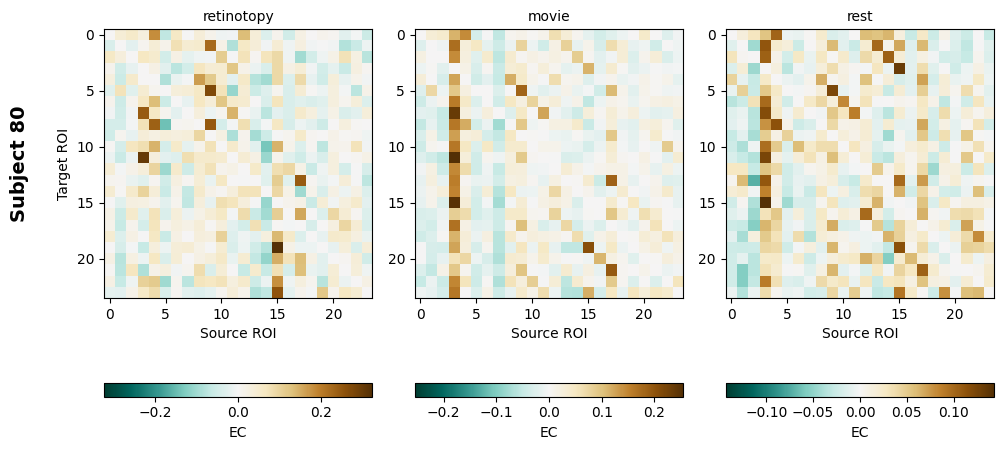

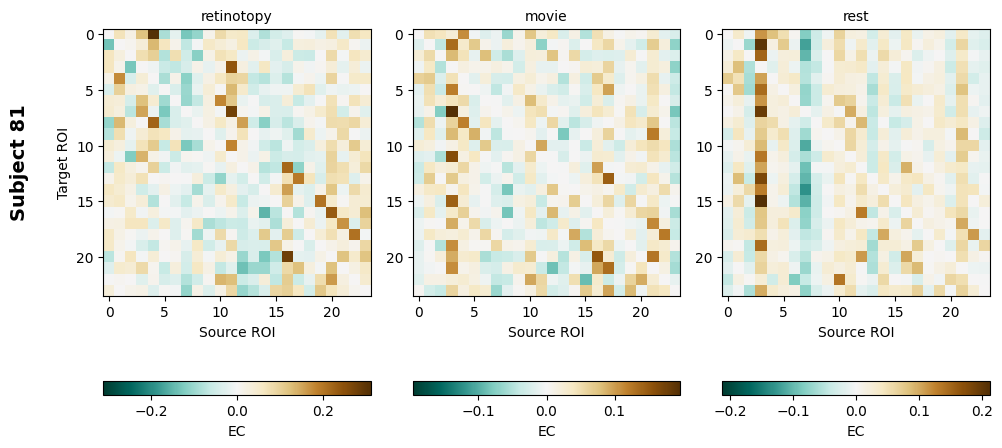

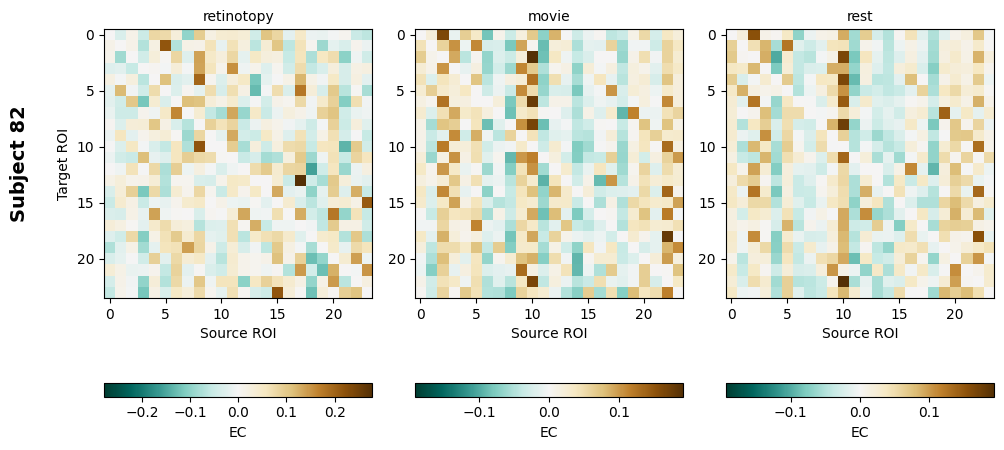

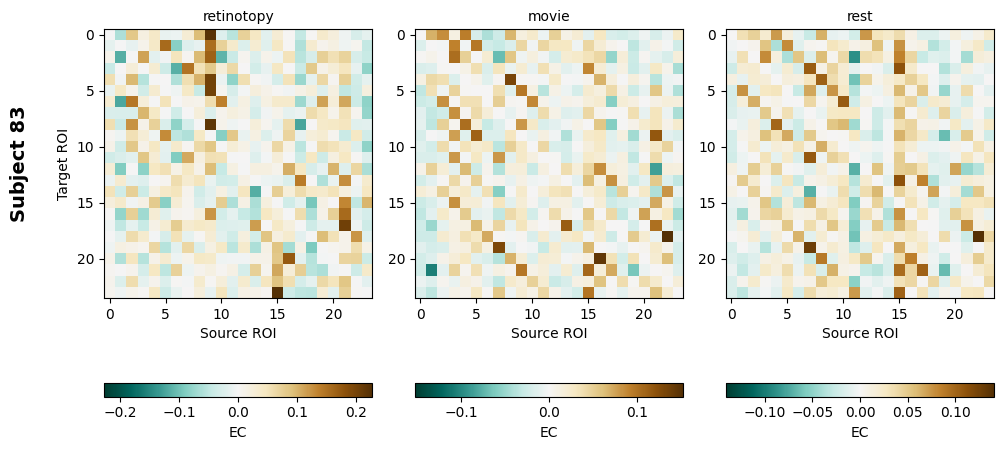

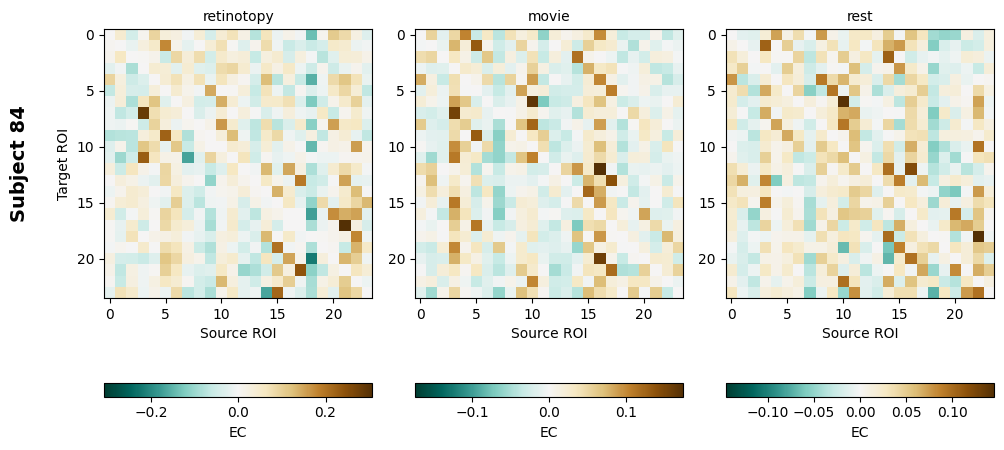

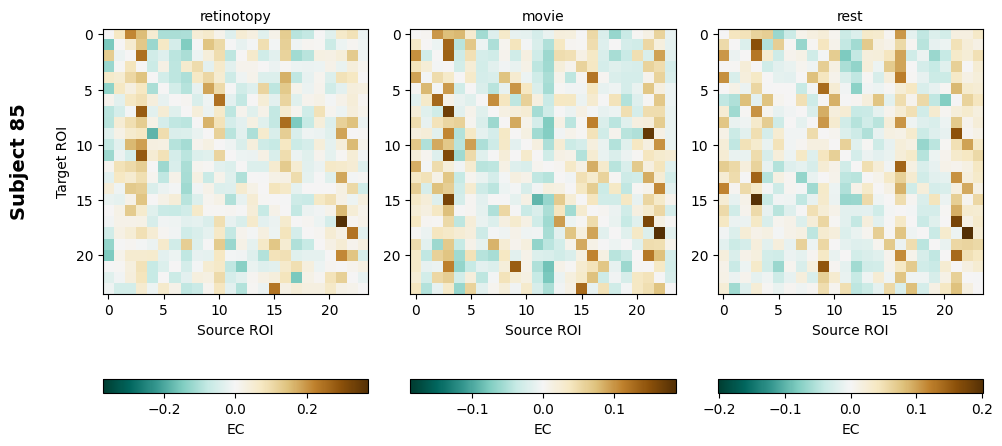

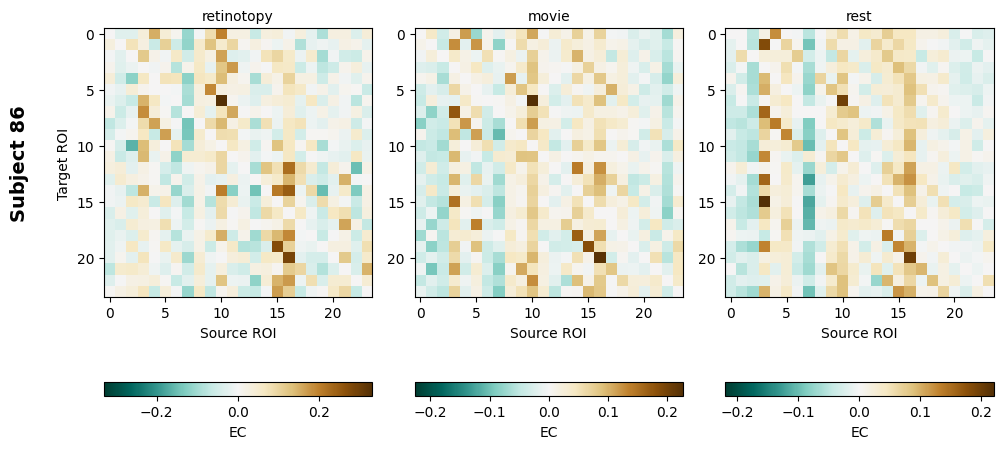

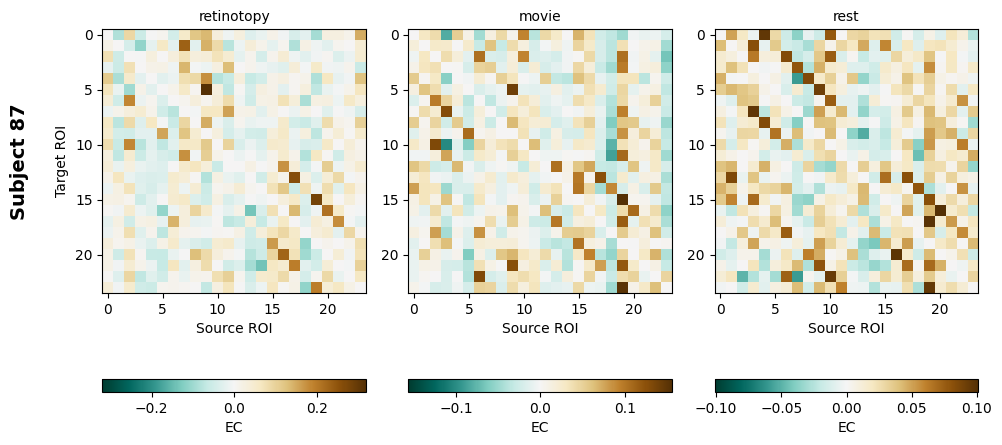

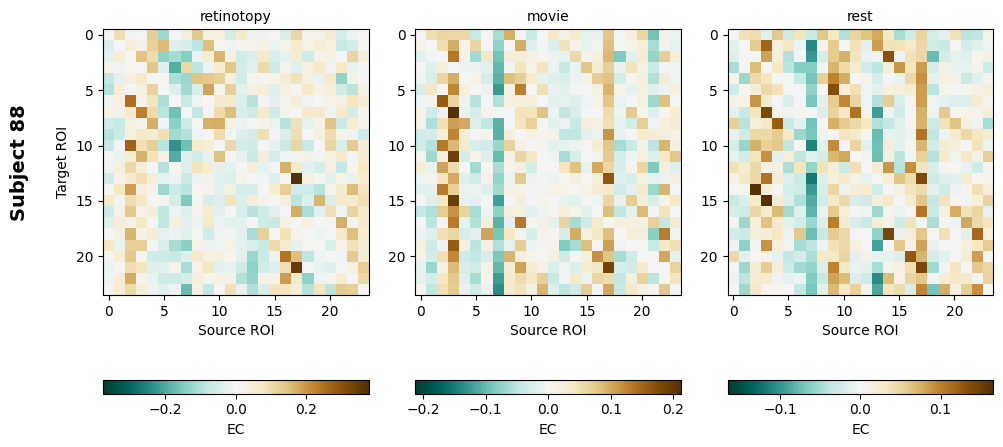

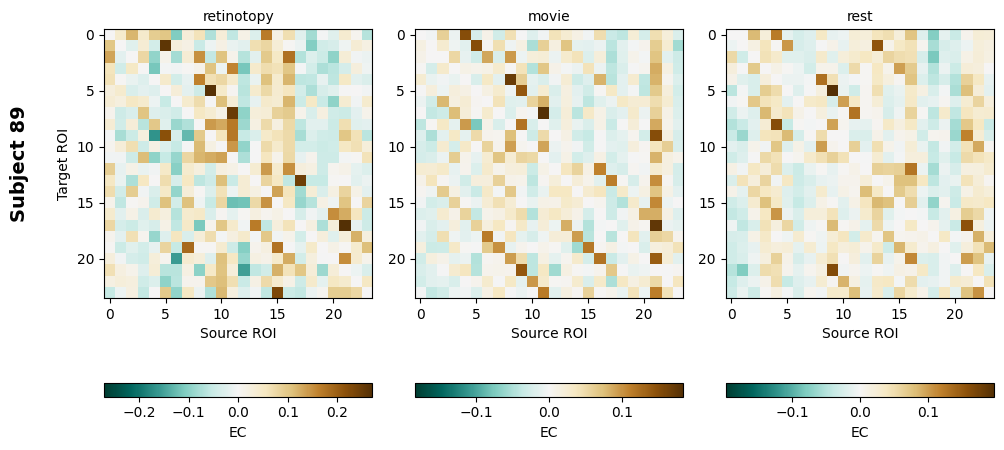

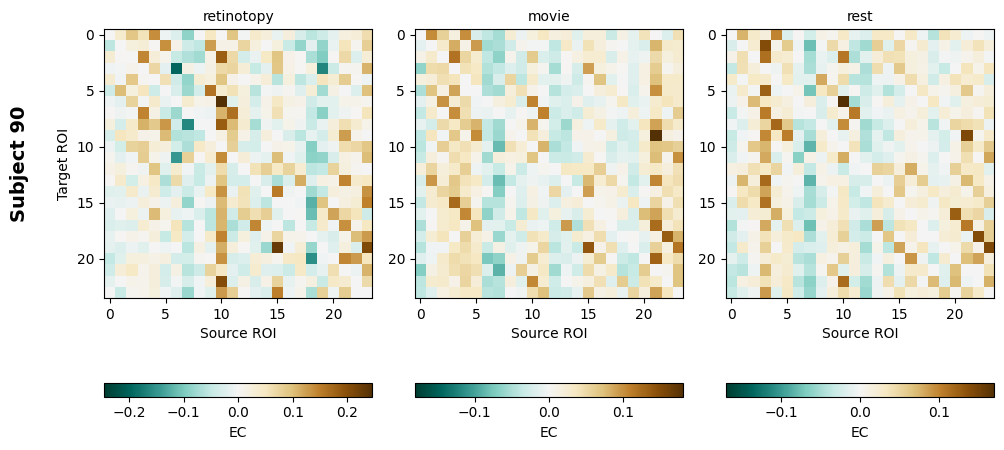

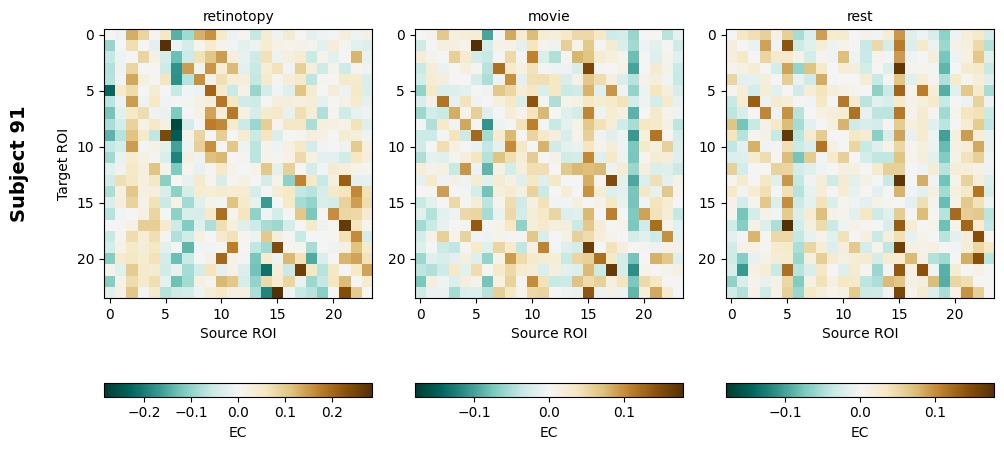

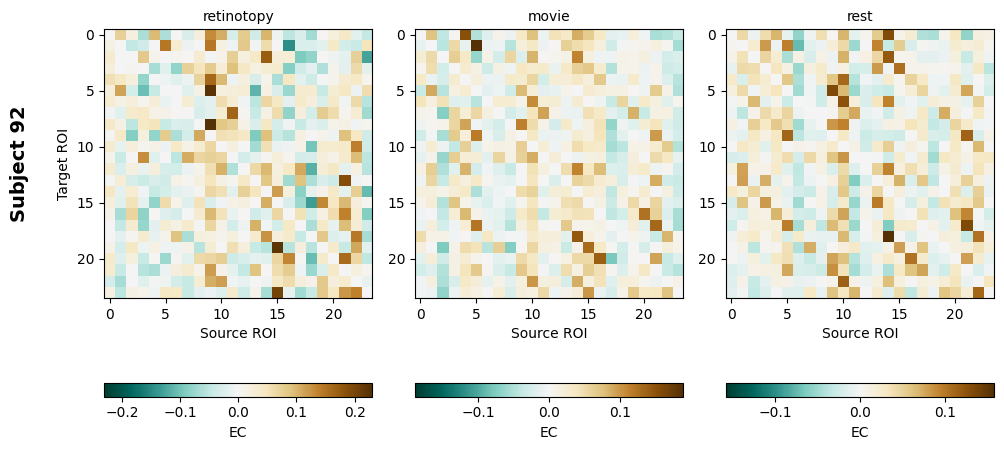

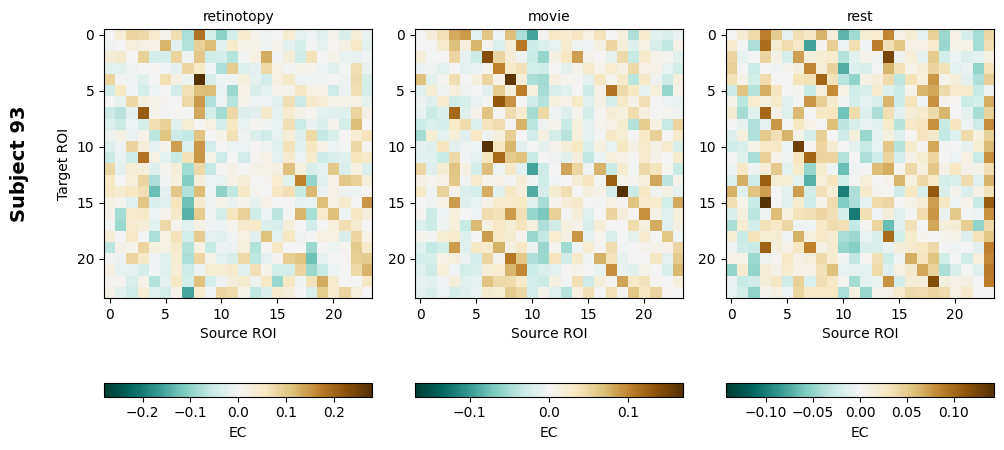

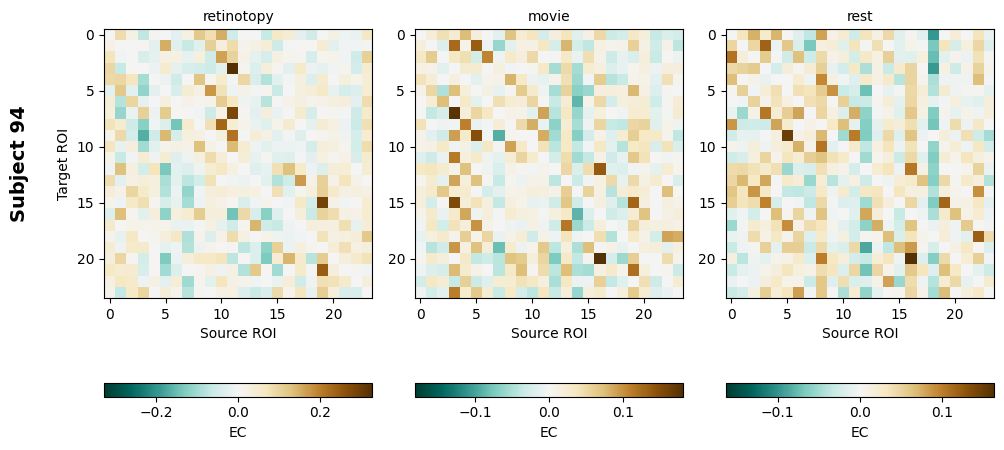

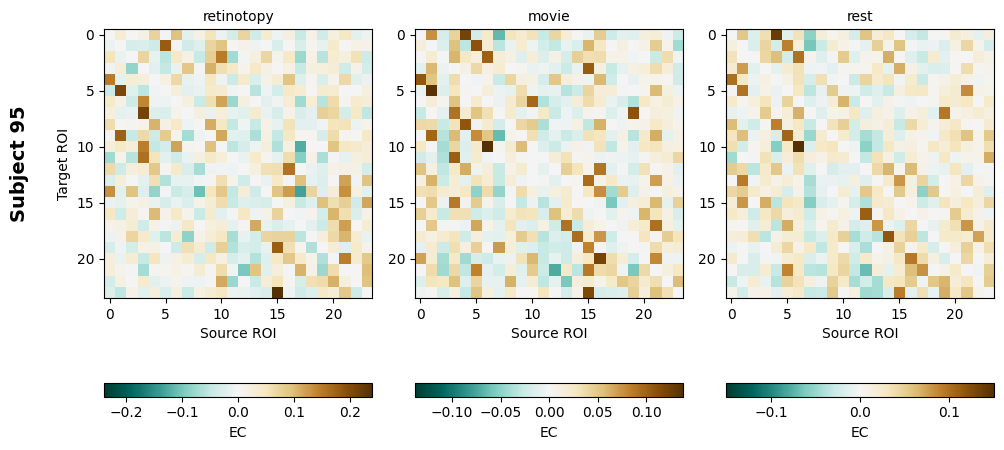

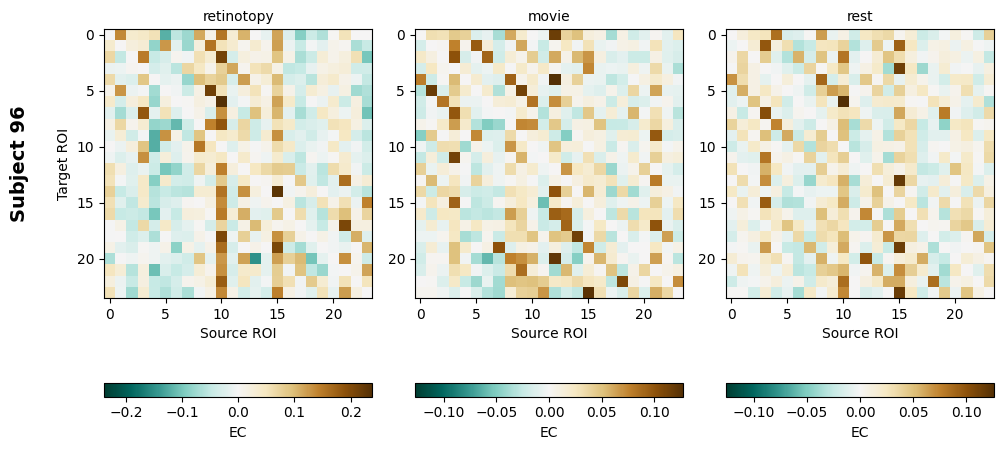

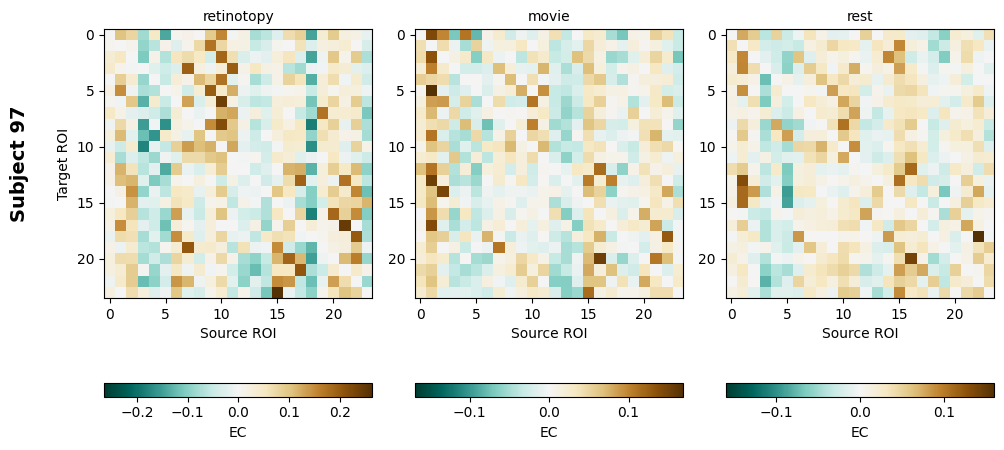

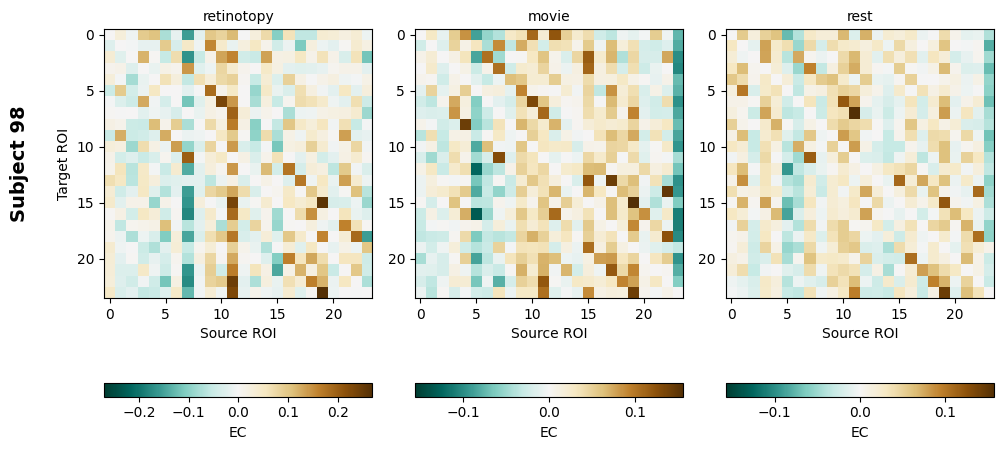

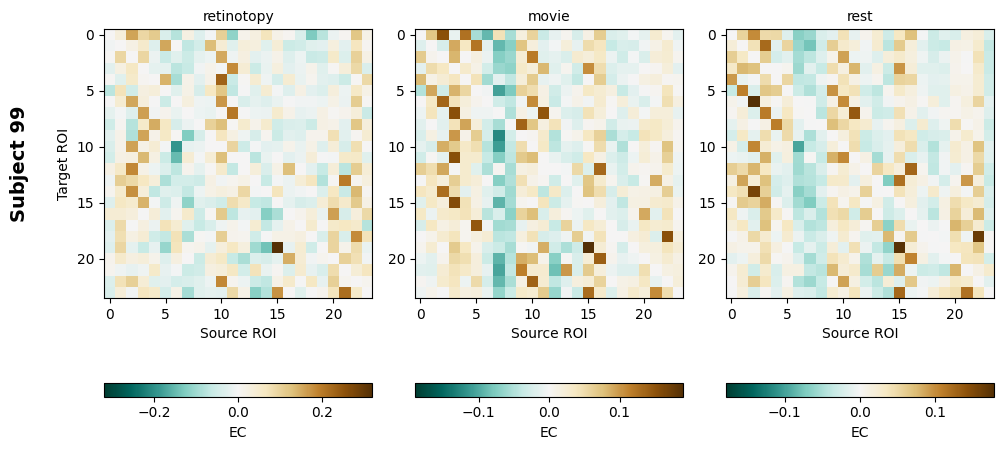

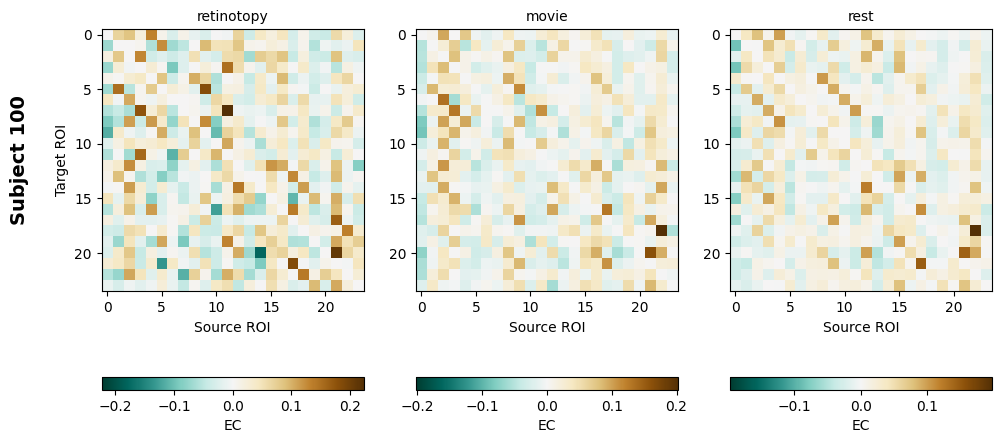

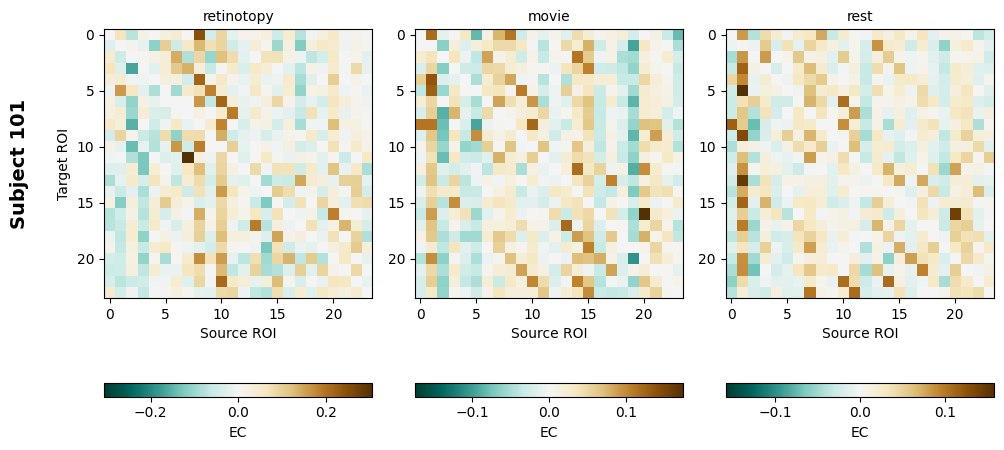

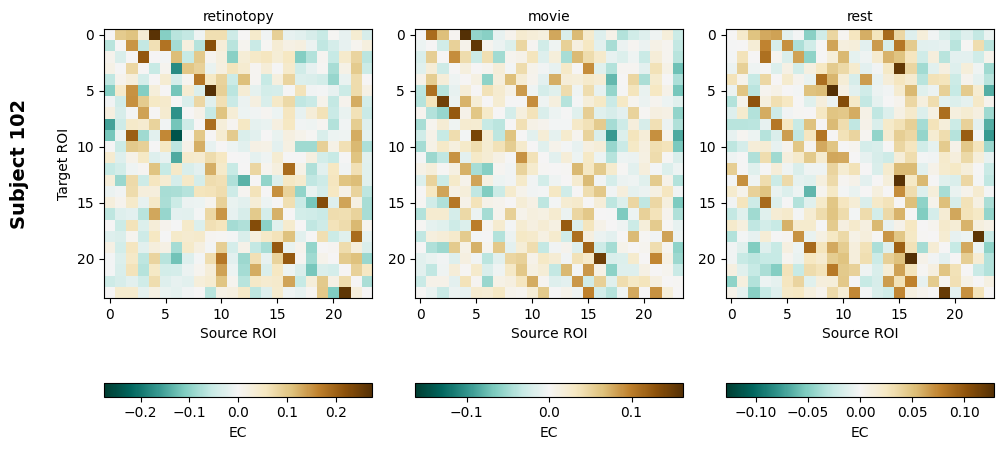

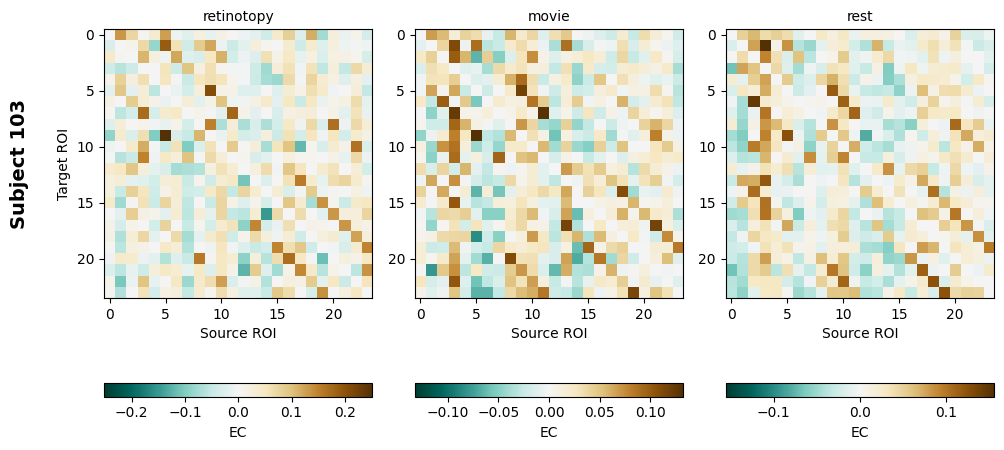

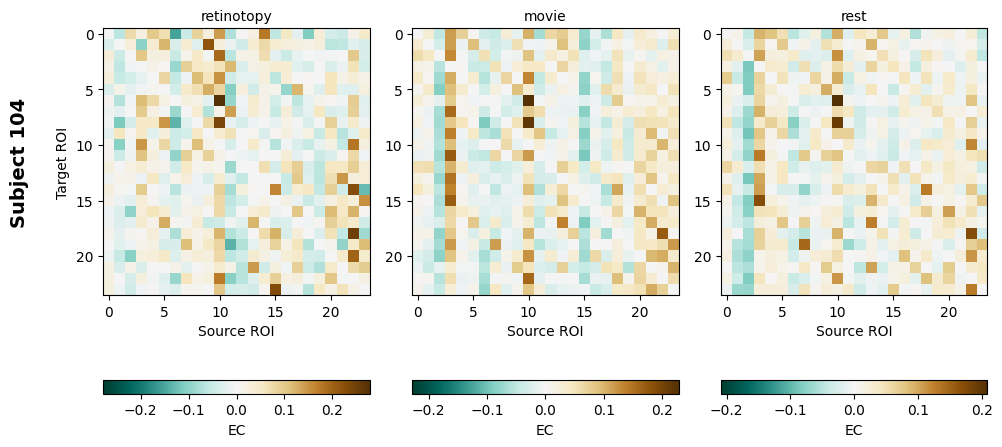

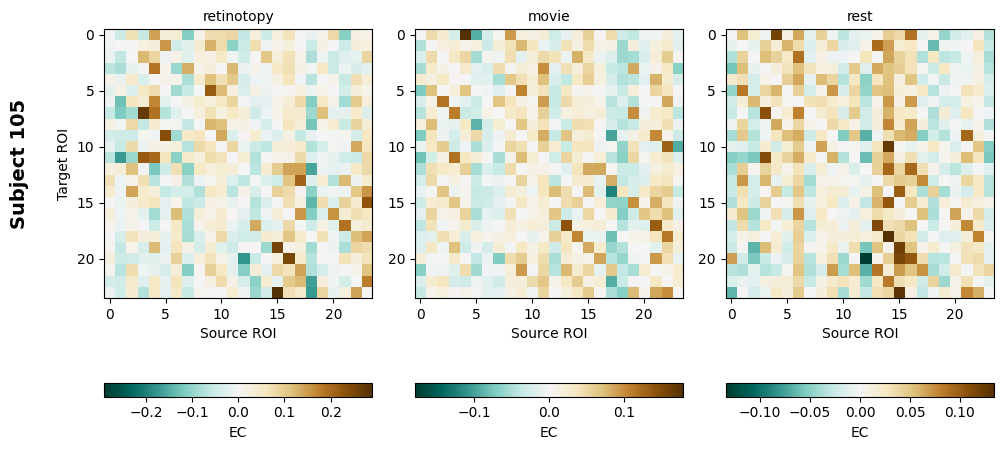

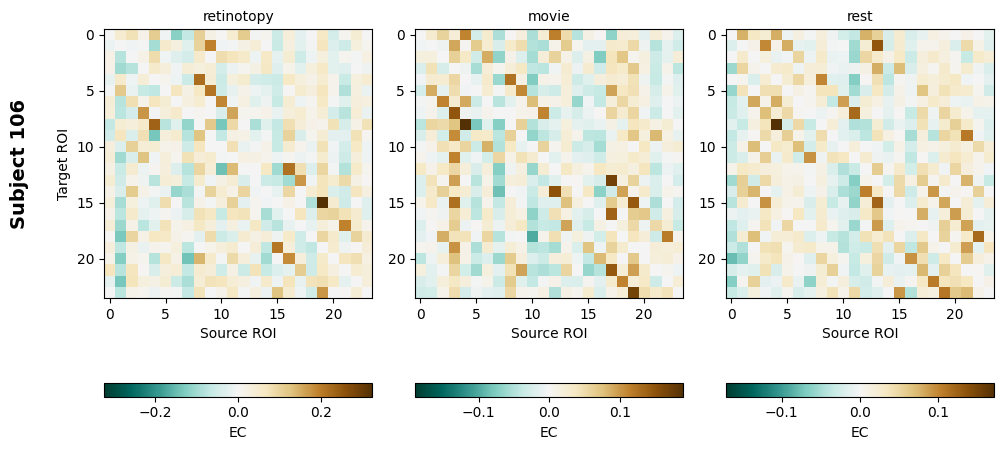

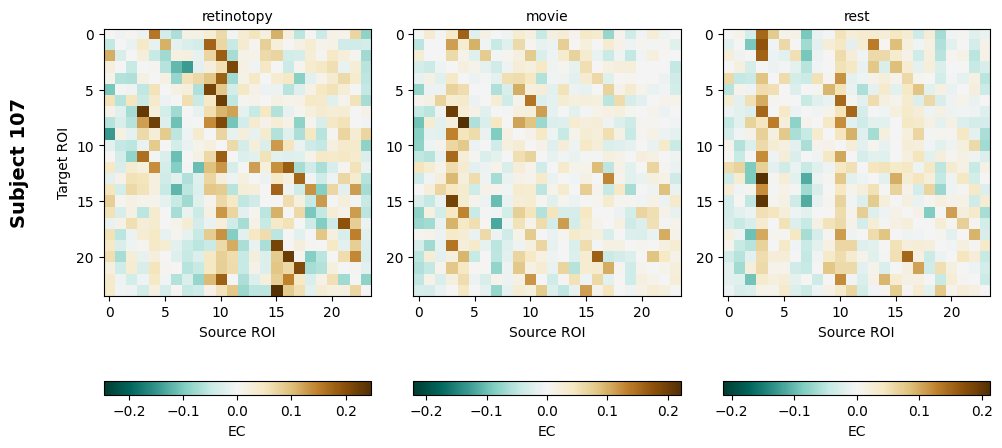

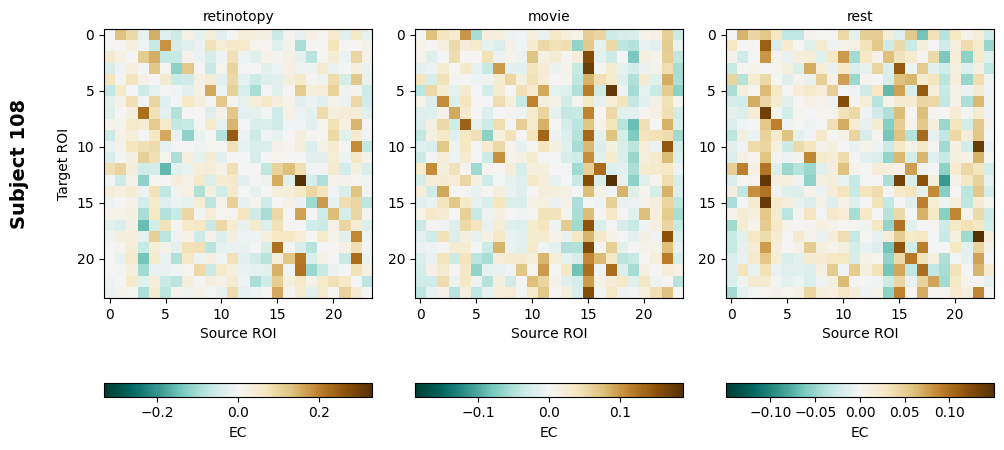

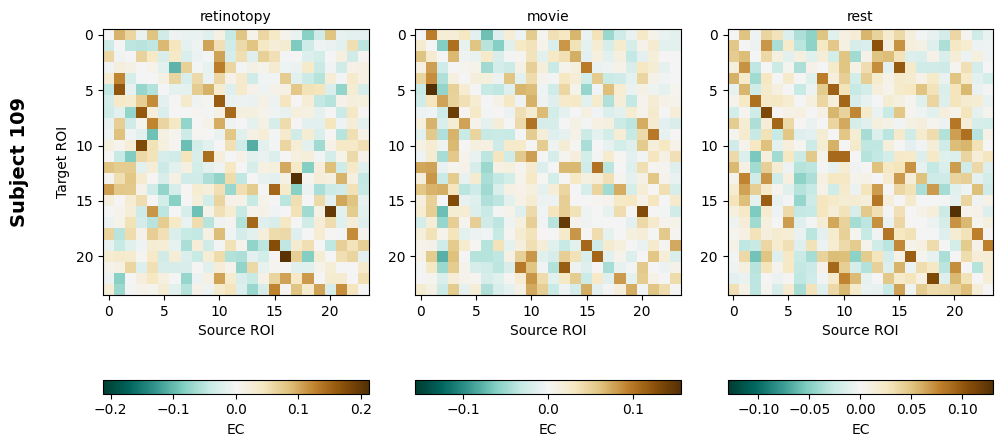

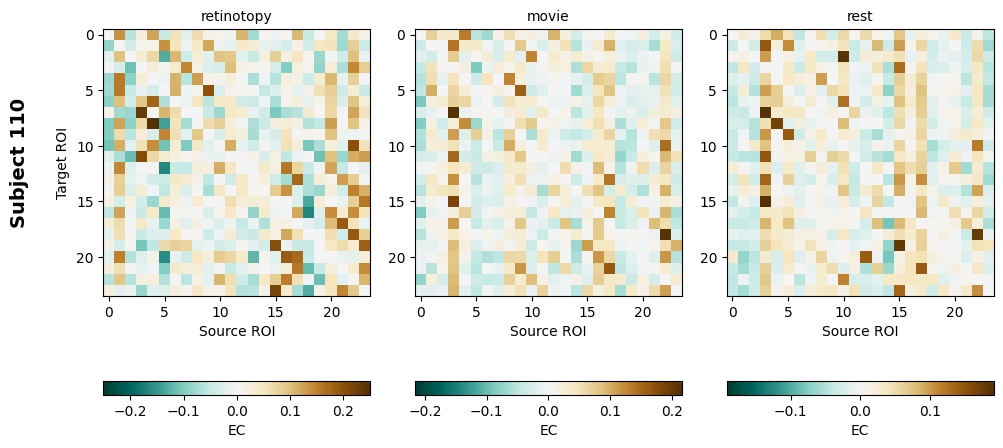

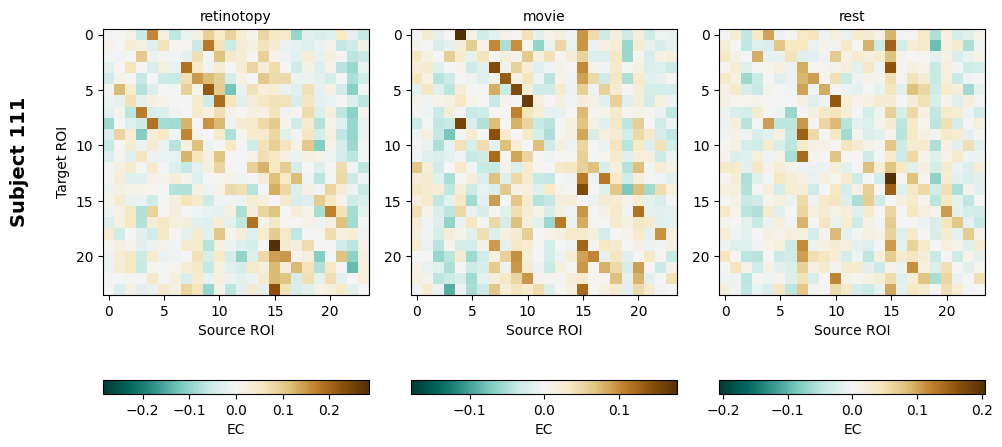

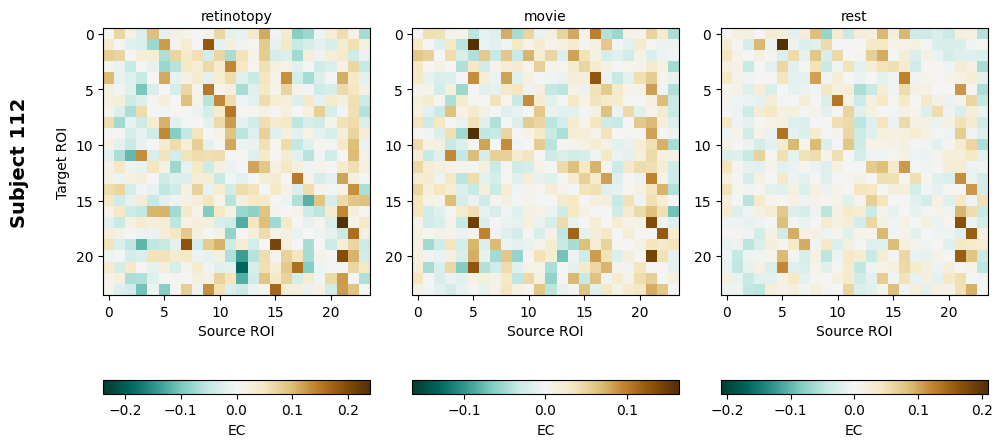

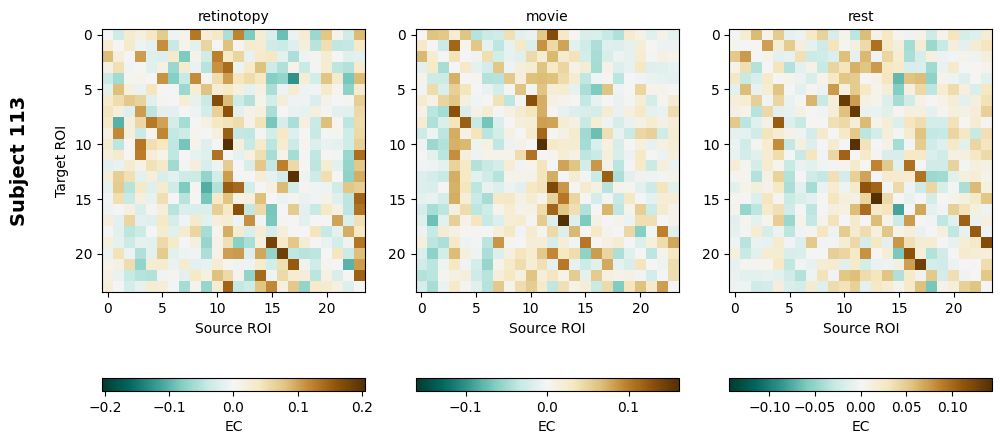

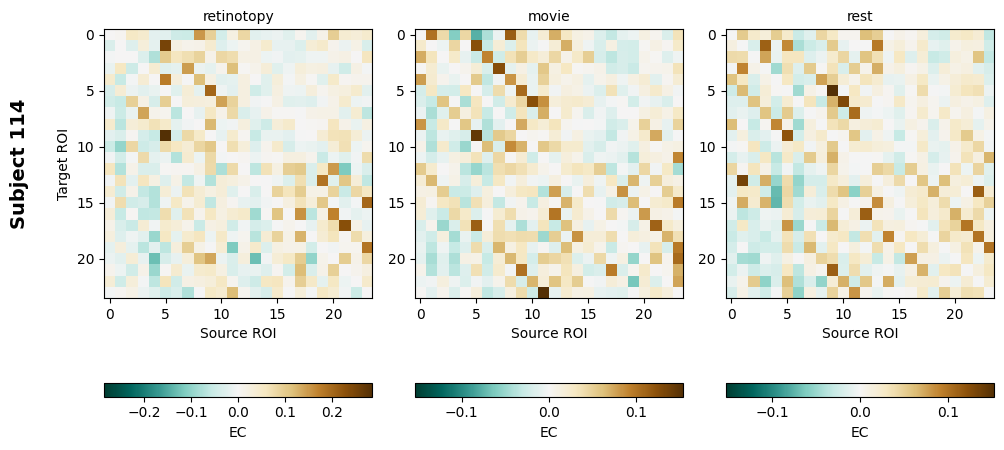

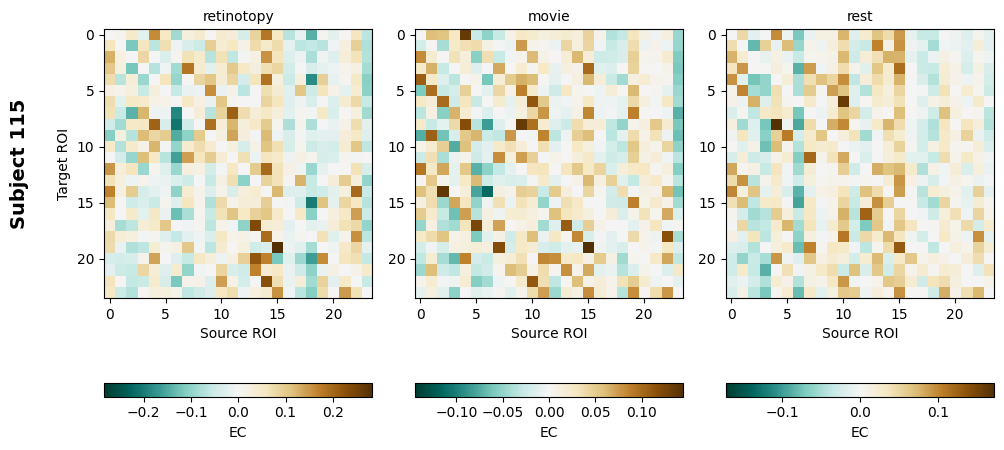

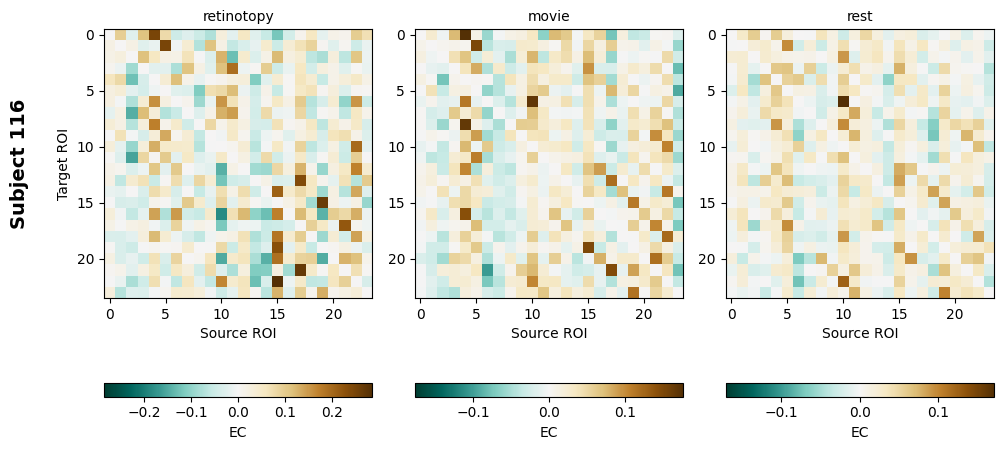

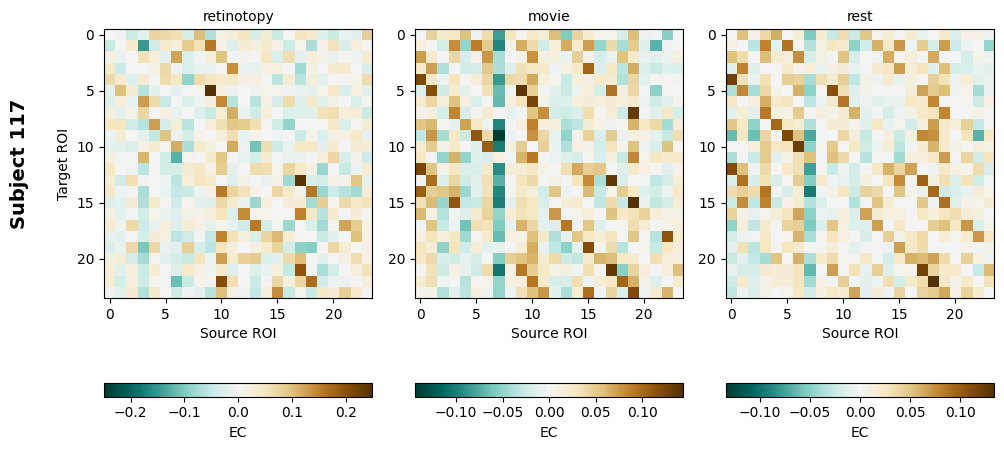

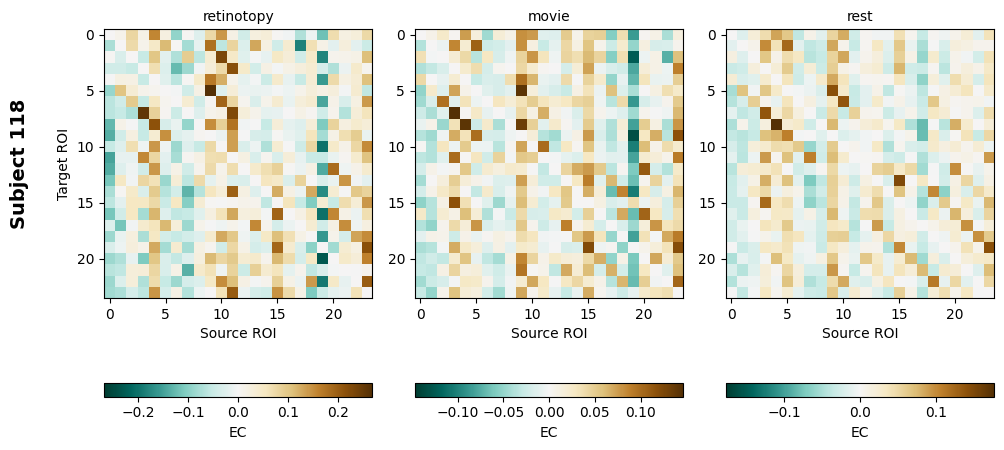

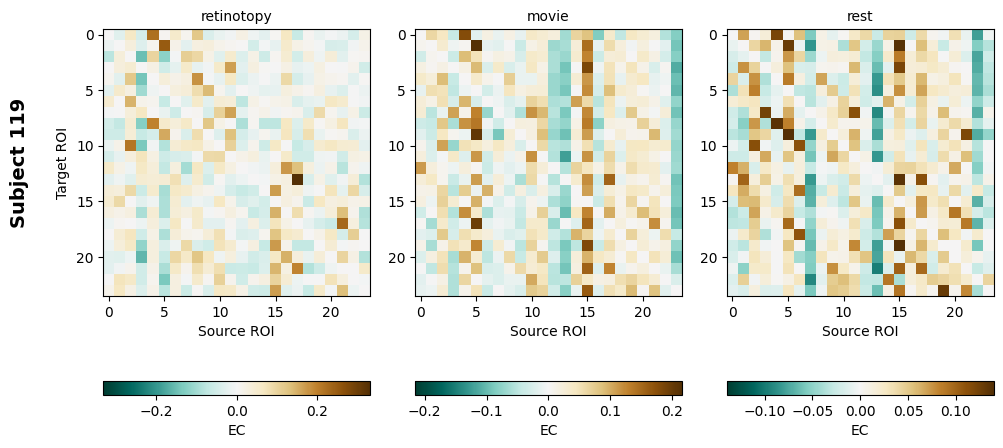

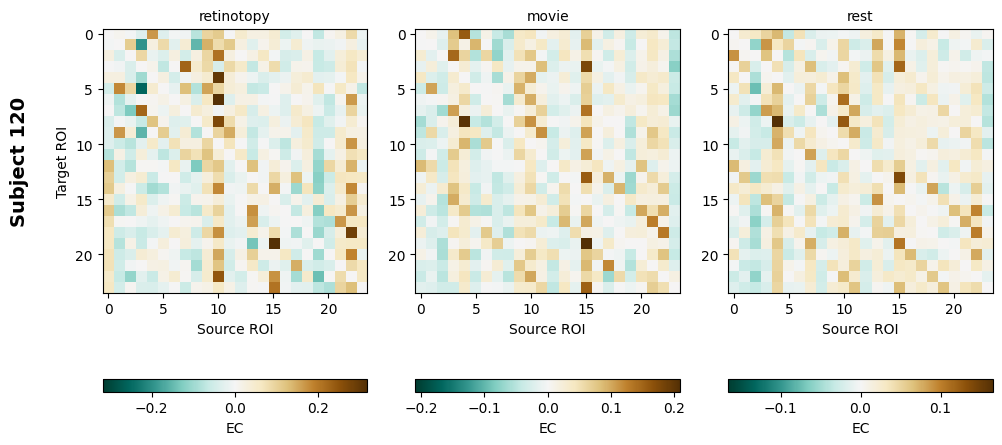

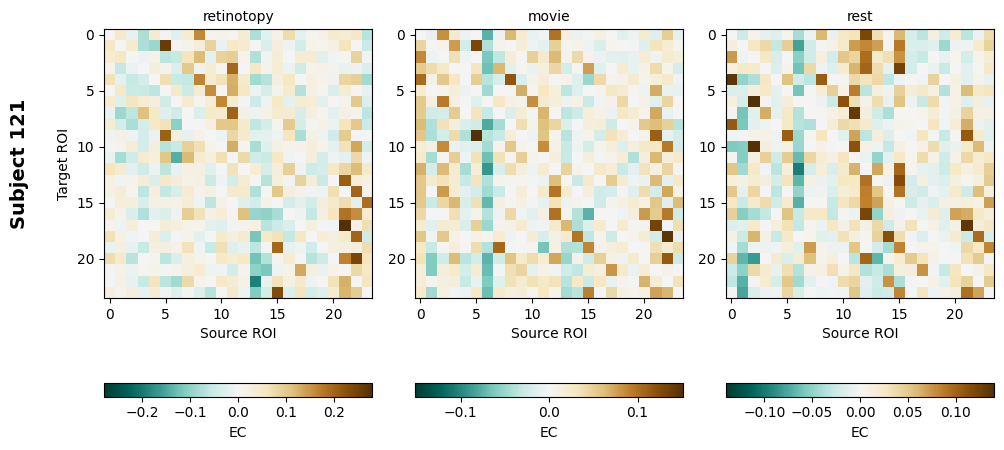

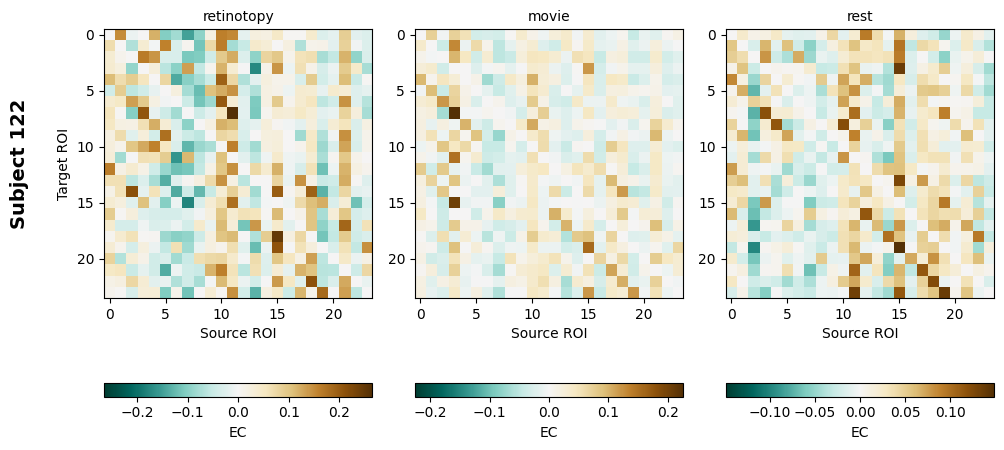

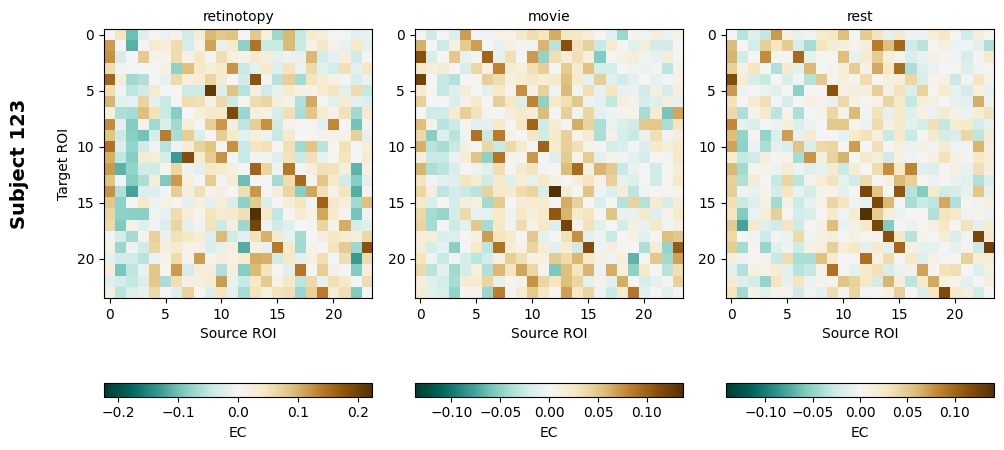

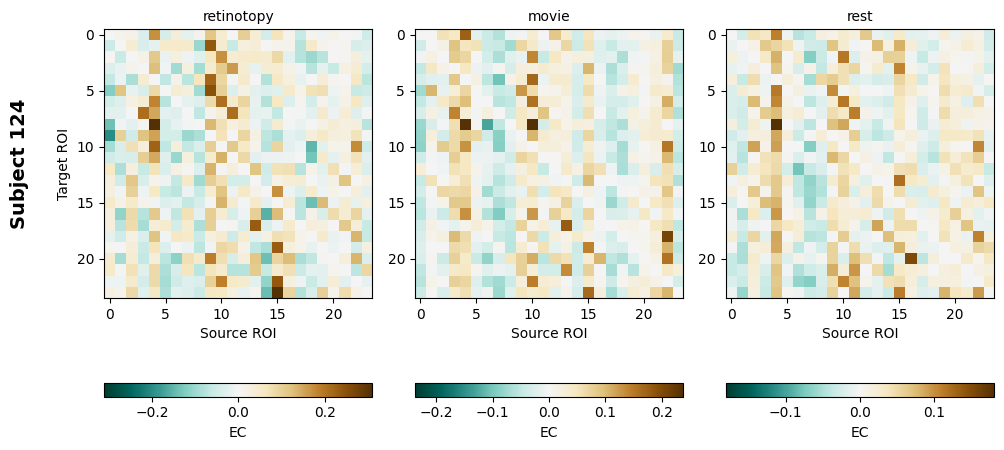

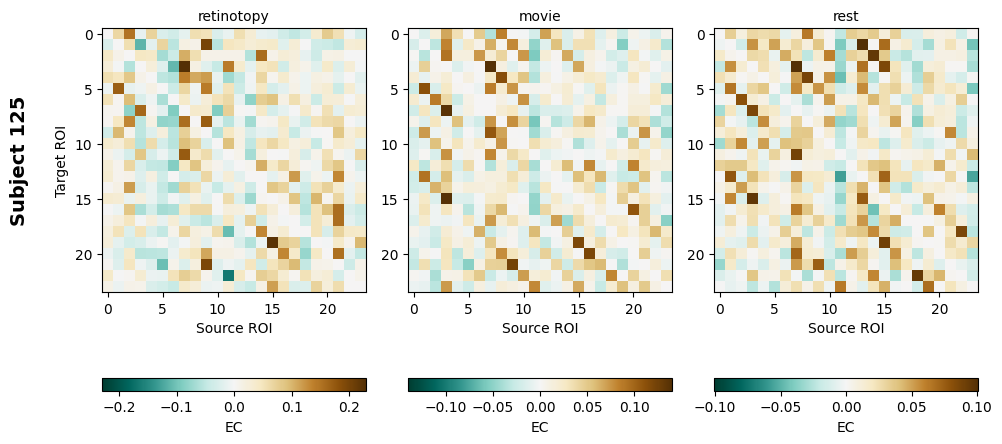

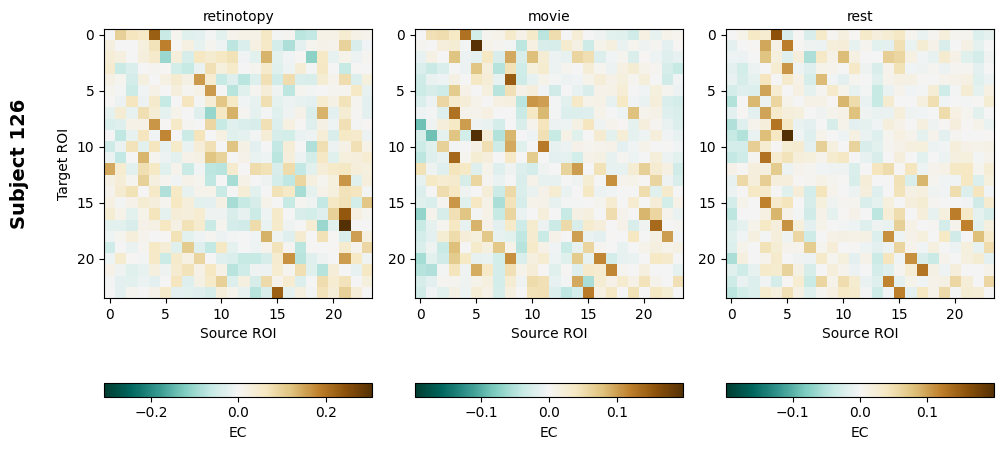

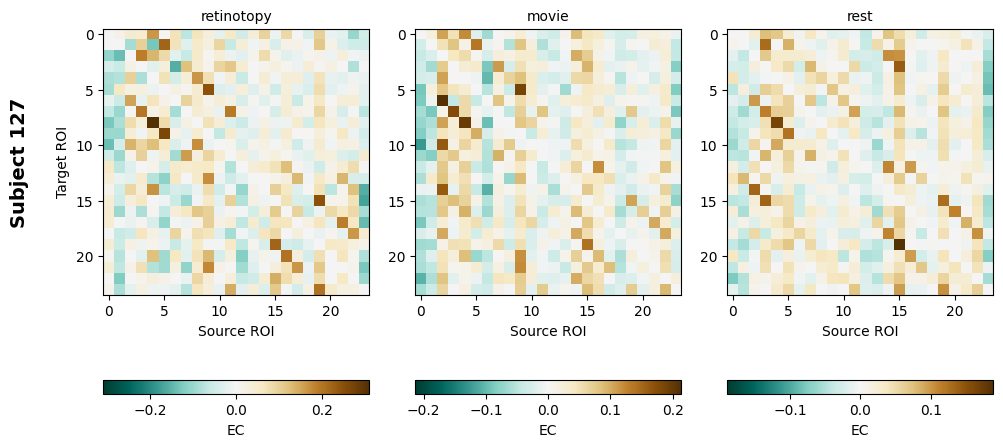

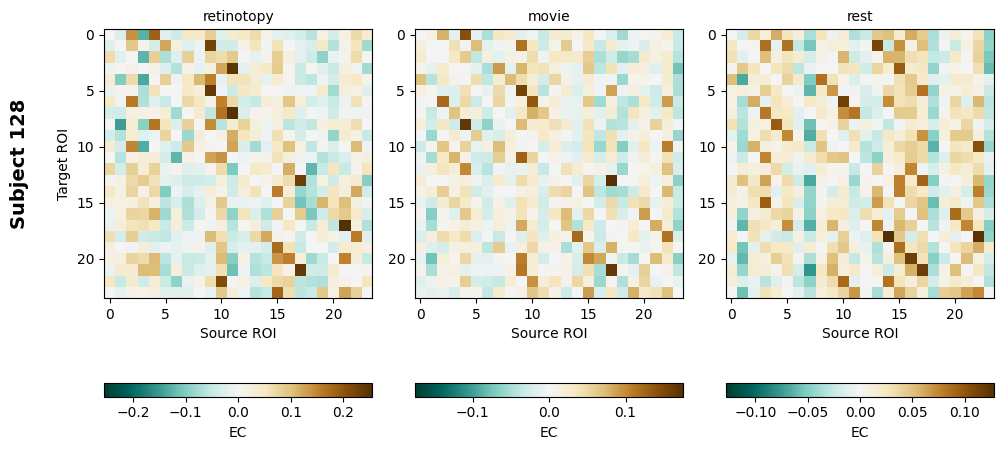

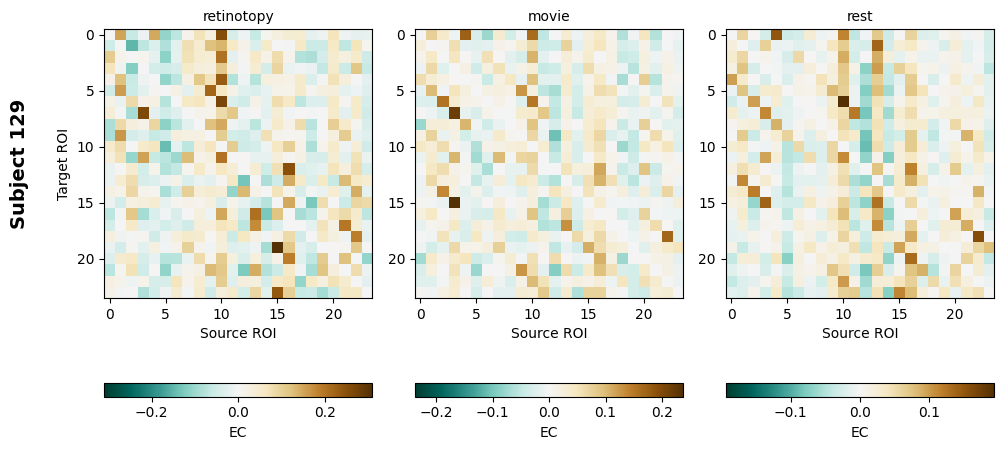

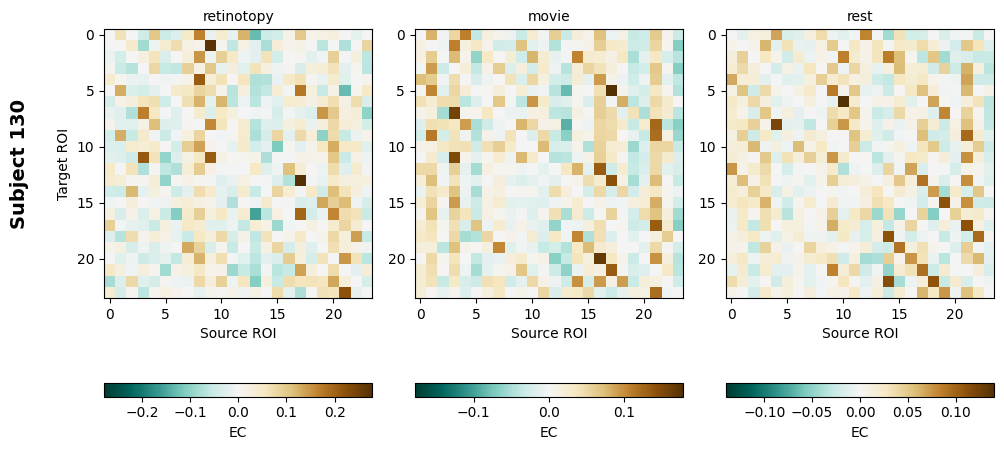

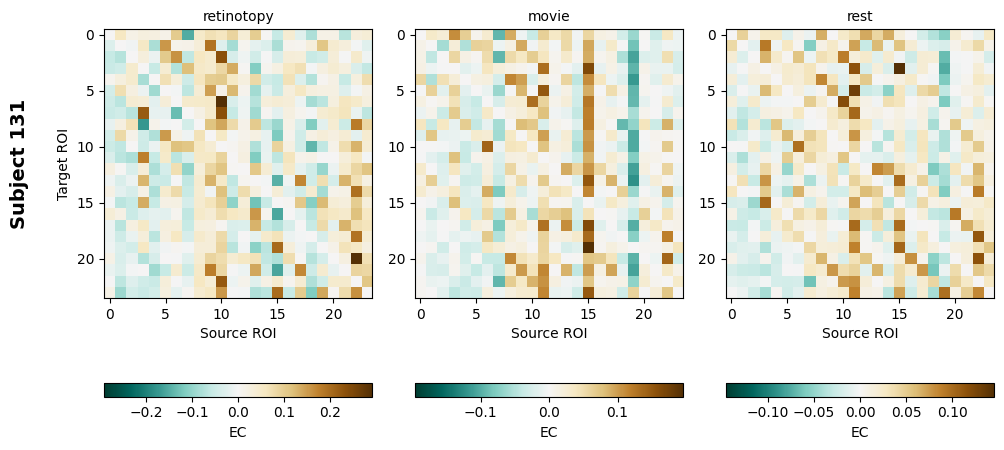

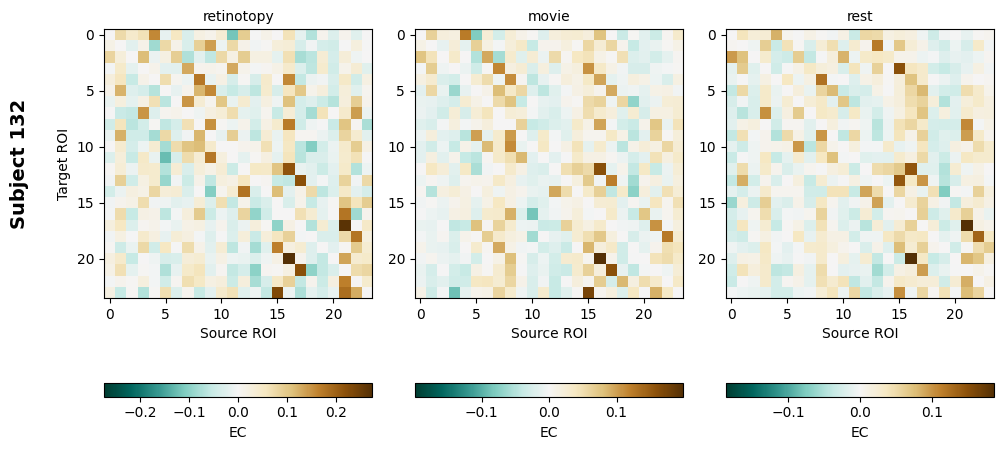

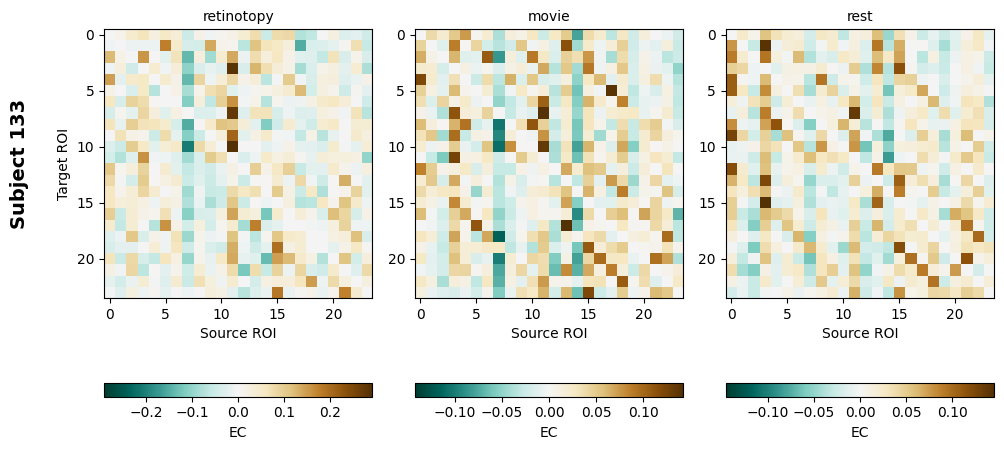

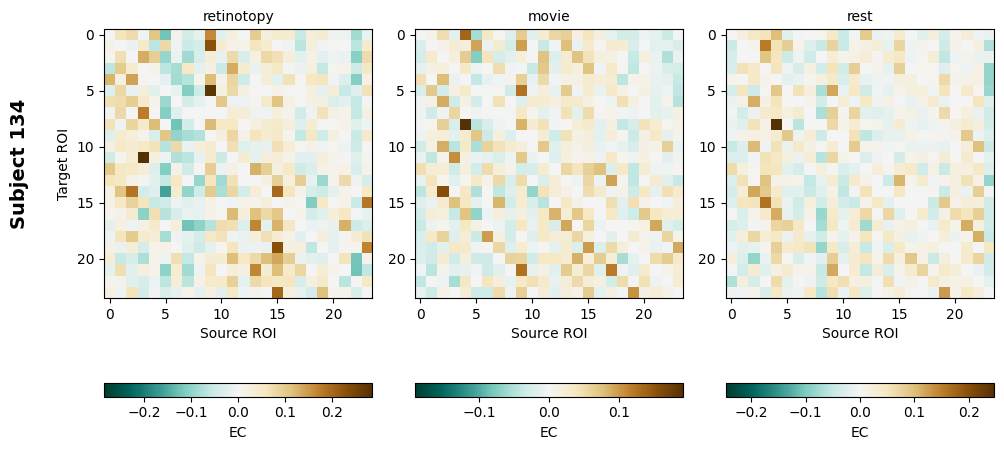

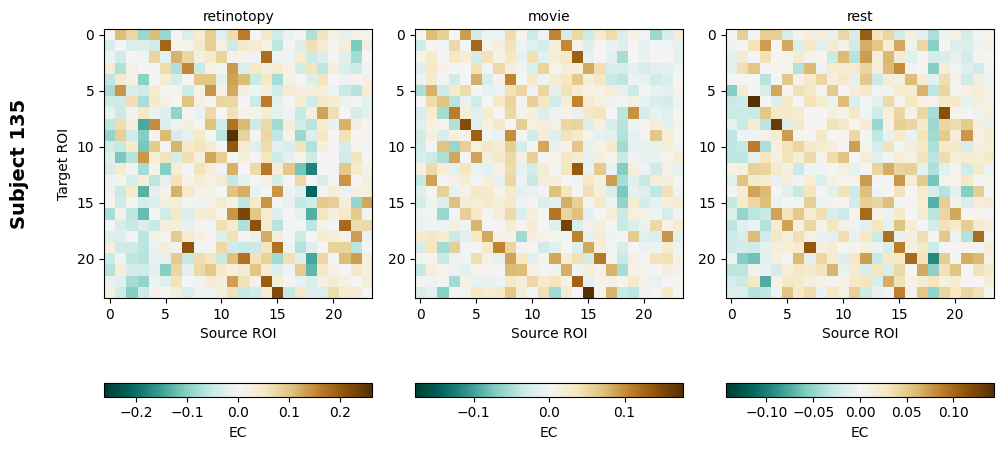

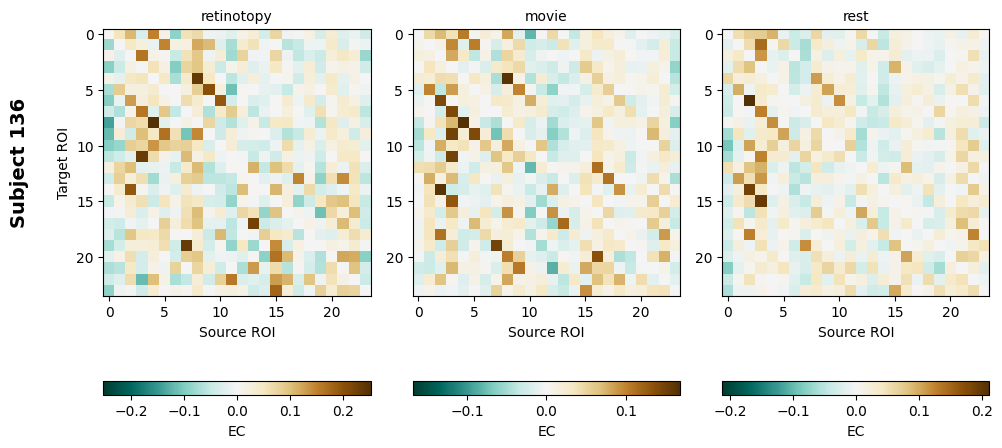

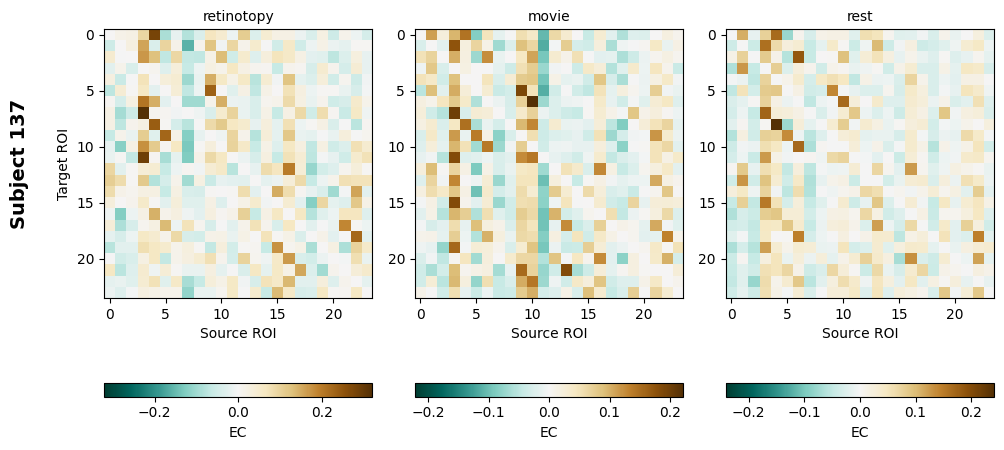

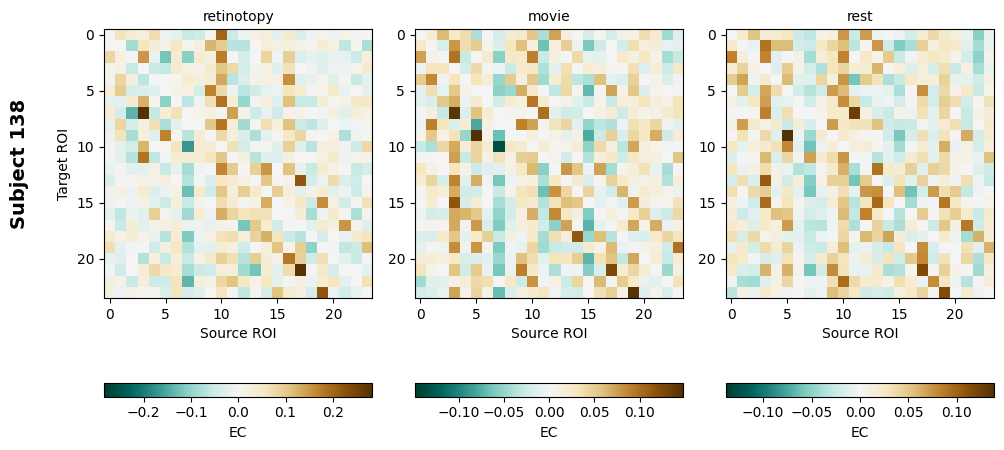

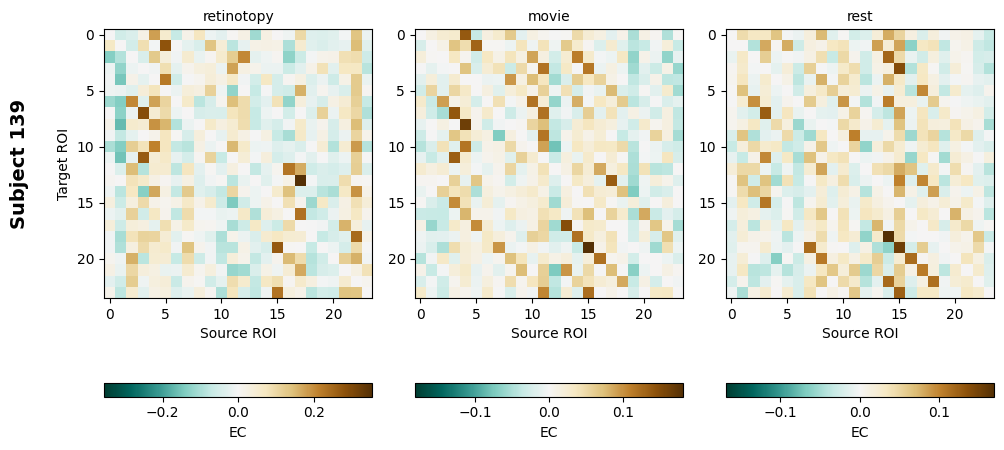

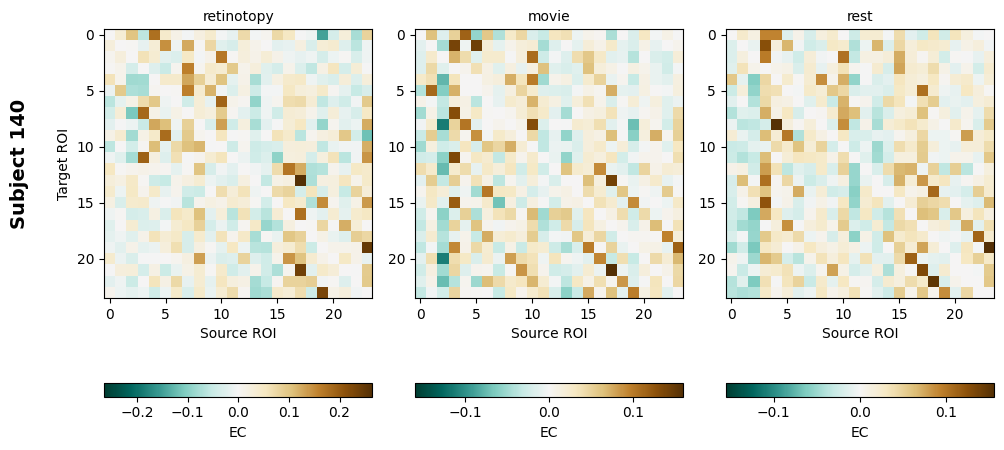

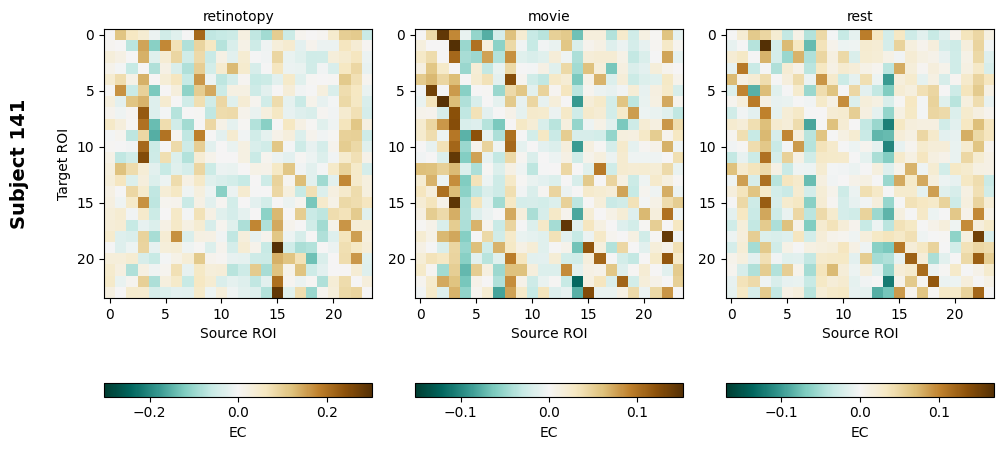

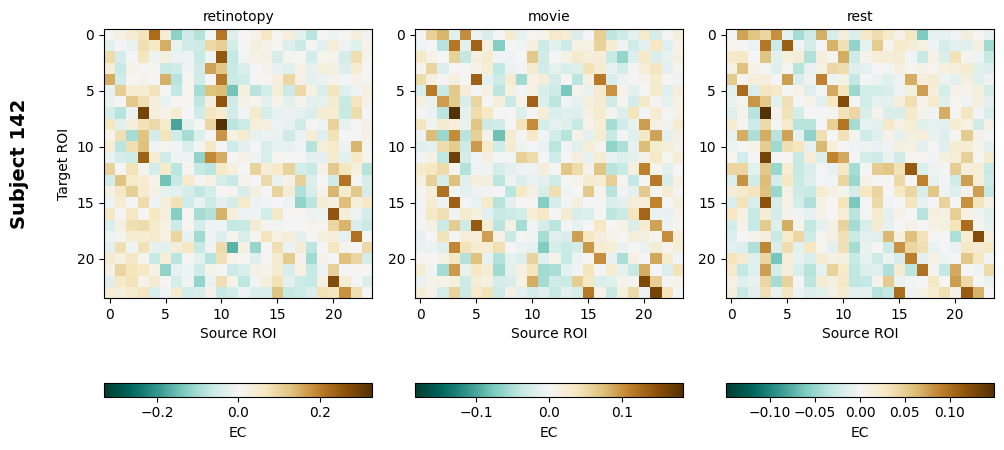

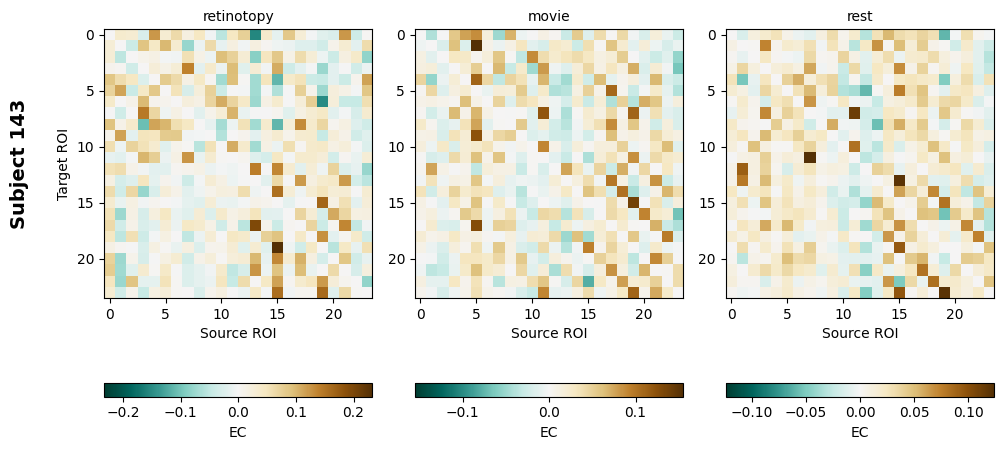

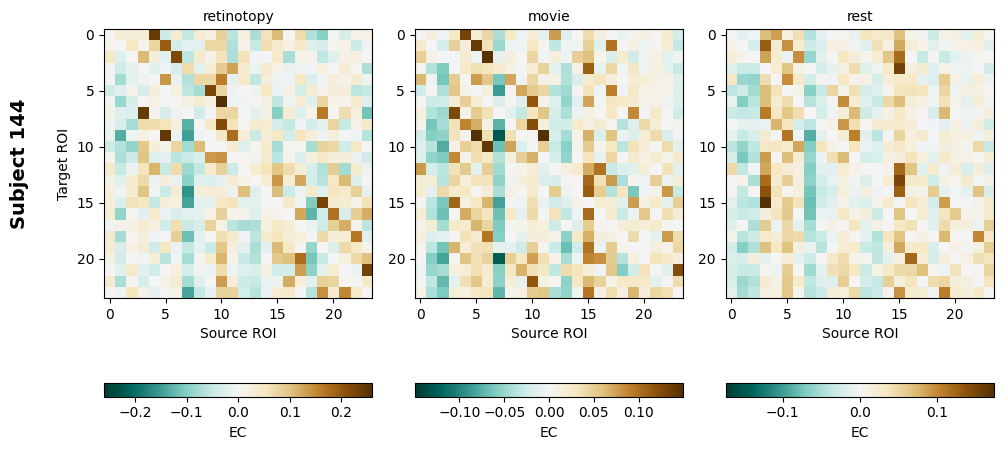

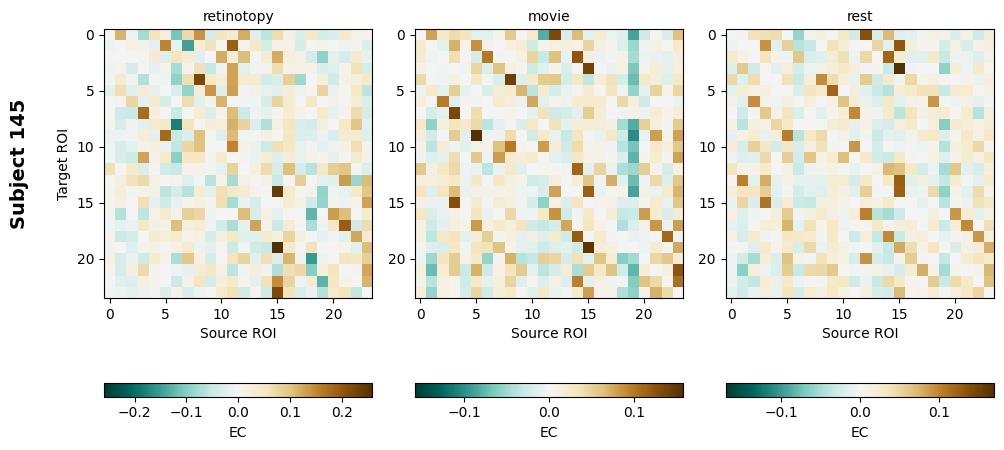

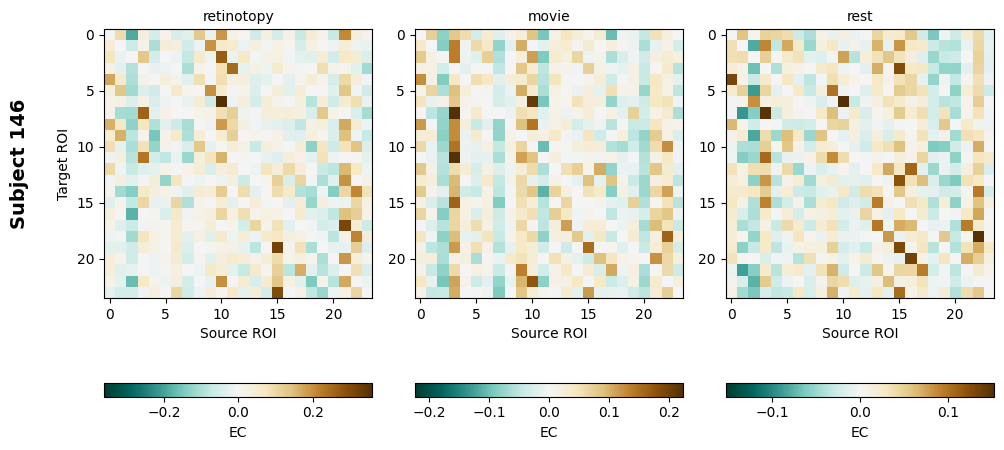

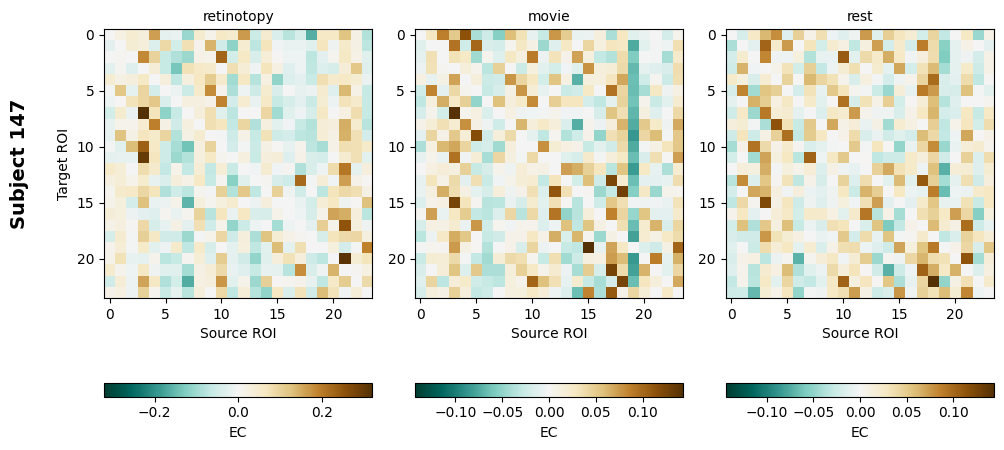

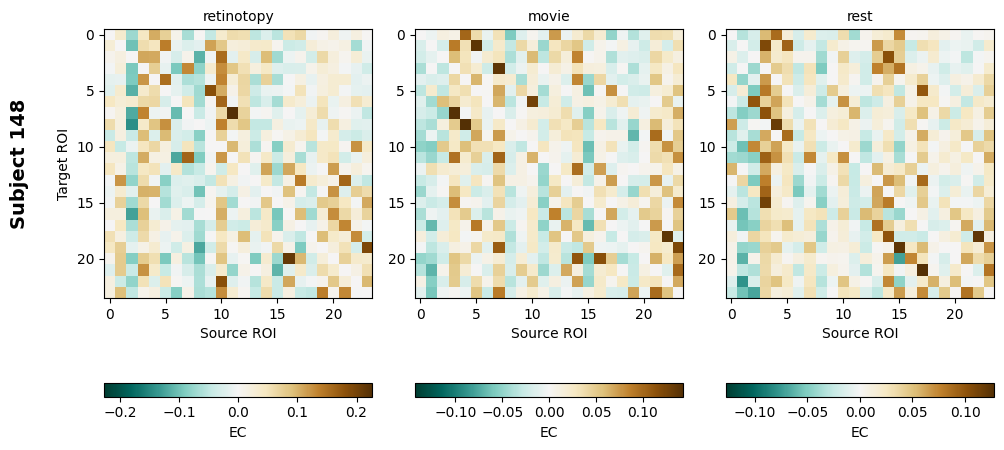

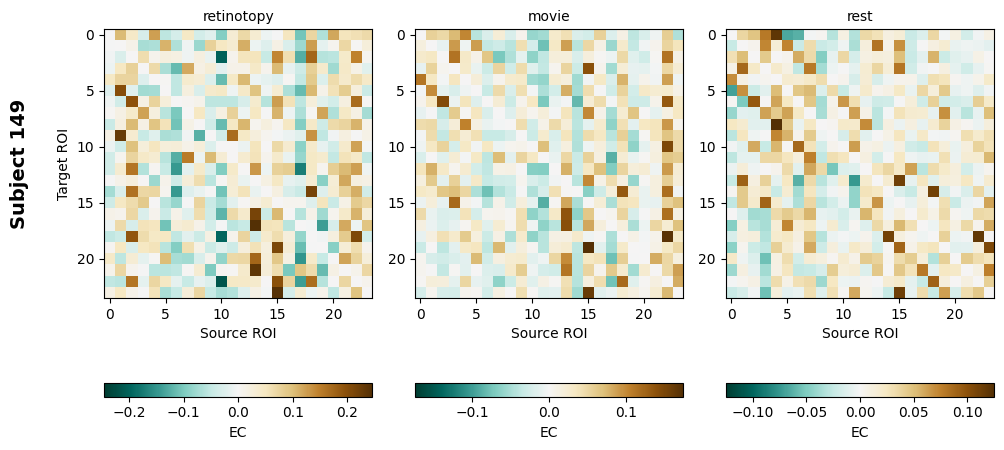

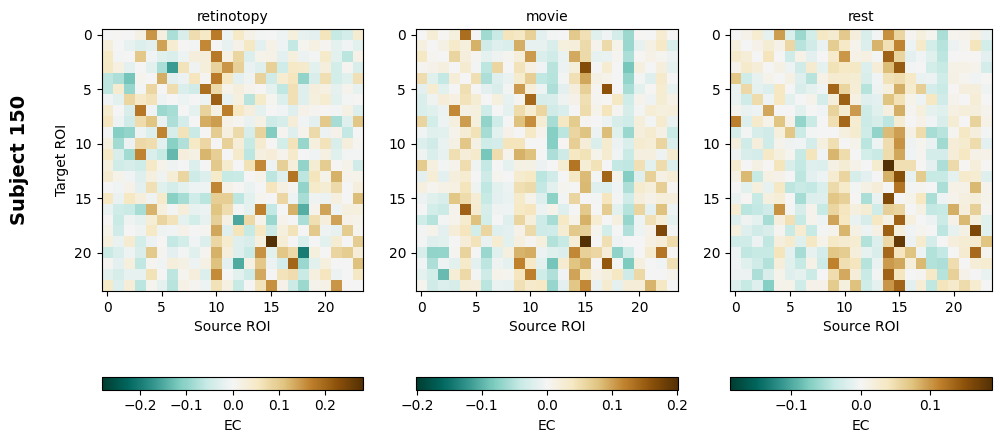

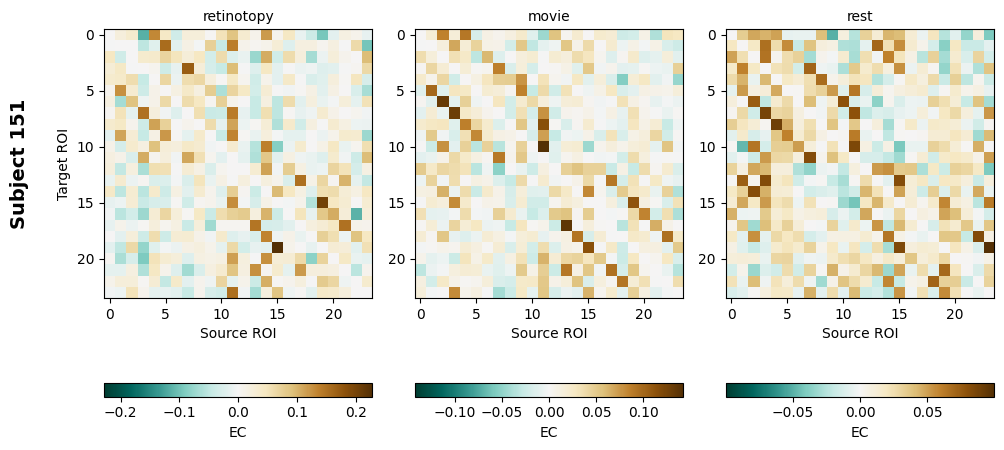

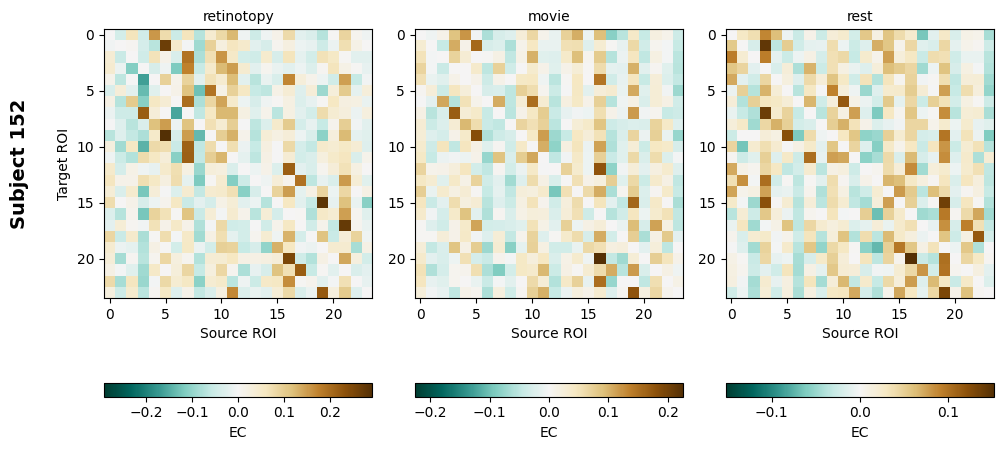

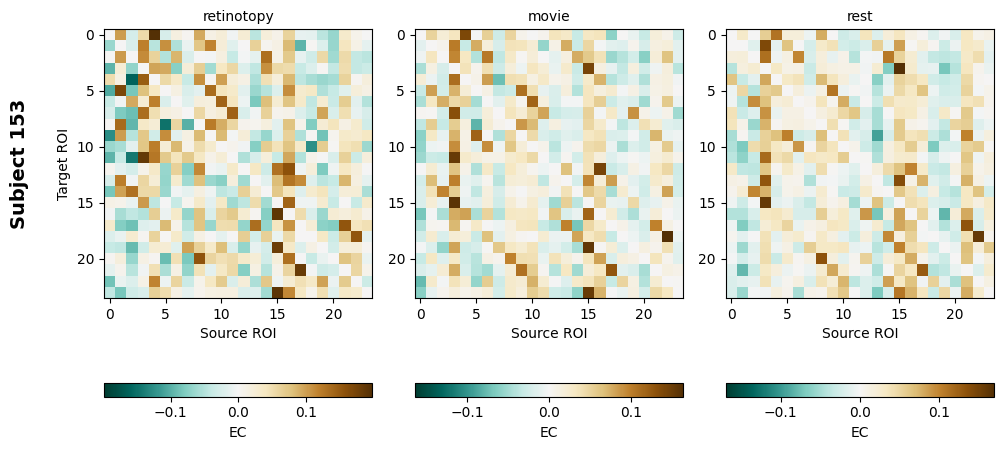

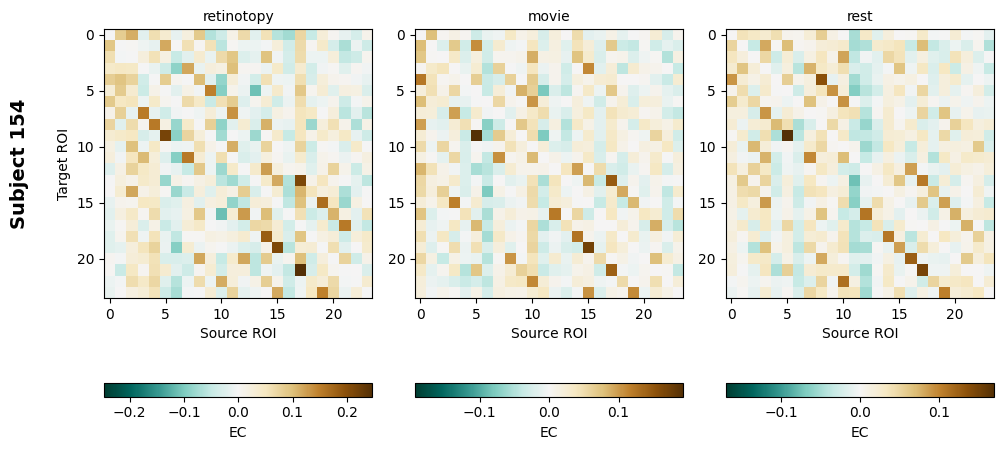

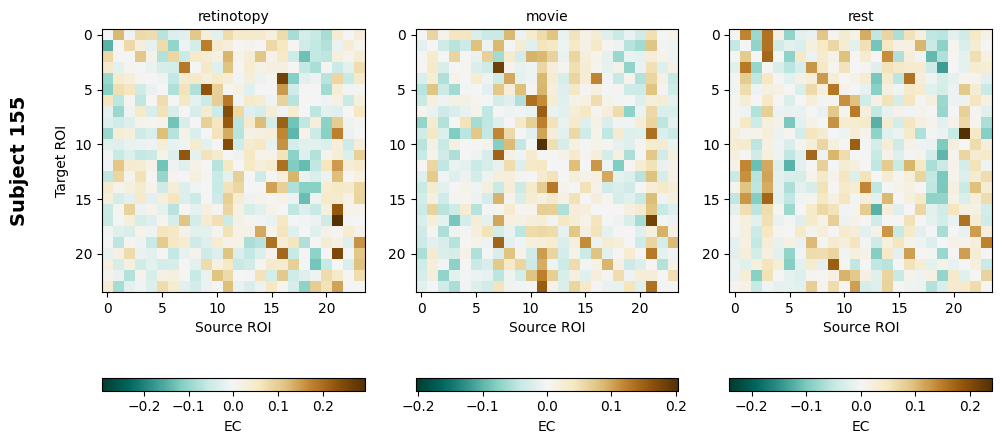

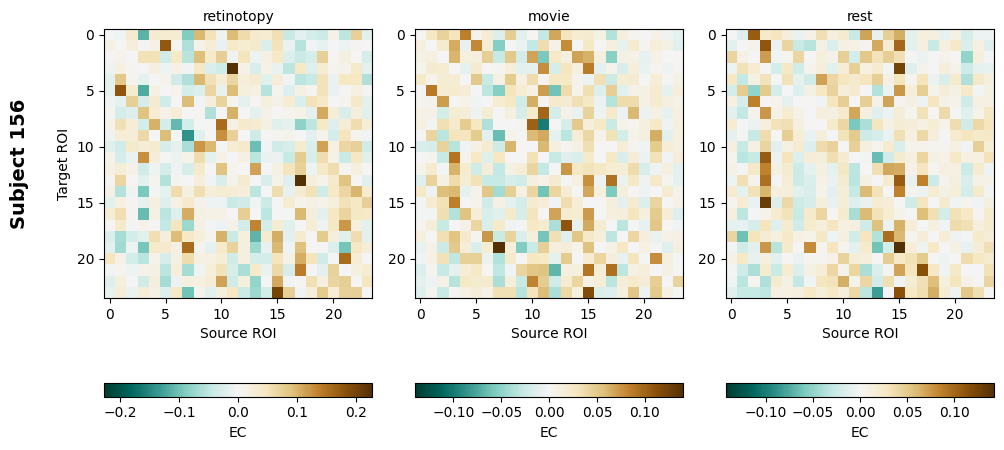

In [7]:
for i_sub in 1:n_sub
    fig, axs = PyPlot.subplots(1, 3, figsize=(10, 6))
    
    # Retinotopy
    PyPlot.sca(axs[1])
    vmax_ret = max(abs(minimum(EC_avg[1, i_sub, :, :])), abs(maximum(EC_avg[1, i_sub, :, :])))
    im0 = PyPlot.imshow(EC_avg[1, i_sub, :, :]', vmin=-vmax_ret, vmax=vmax_ret, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.ylabel("Target ROI", fontsize=10)
    PyPlot.title("retinotopy", fontsize=10)
    PyPlot.colorbar(im0, ax=axs[1], orientation="horizontal", pad=0.15, label="EC")
    
    # Add subject label vertically on the left
    axs[1].text(-0.35, 0.5, "Subject $i_sub", transform=axs[1].transAxes, 
                fontsize=14, fontweight="bold", va="center", rotation=90)

    # Movie
    PyPlot.sca(axs[2])
    vmax_mov = max(abs(minimum(EC_avg[2, i_sub, :, :])), abs(maximum(EC_avg[2, i_sub, :, :])))
    im1 = PyPlot.imshow(EC_avg[2, i_sub, :, :]', vmin=-vmax_mov, vmax=vmax_mov, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.title("movie", fontsize=10)
    PyPlot.colorbar(im1, ax=axs[2], orientation="horizontal", pad=0.15, label="EC")

    # Rest
    PyPlot.sca(axs[3])
    vmax_rest = max(abs(minimum(EC_avg[3, i_sub, :, :])), abs(maximum(EC_avg[3, i_sub, :, :])))
    im2 = PyPlot.imshow(EC_avg[3, i_sub, :, :]', vmin=-vmax_rest, vmax=vmax_rest, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.title("rest", fontsize=10)
    PyPlot.colorbar(im2, ax=axs[3], orientation="horizontal", pad=0.15, label="EC")
    
    PyPlot.tight_layout()
    display(fig)
    PyPlot.close(fig)
end

## Save rDCM posterior and diagonal

In [12]:
out_path = "../../../temp/results_rDCM/"
mkpath(out_path)

# Save EC_avg and diagonals and F_avg in .npy format
npzwrite(joinpath(out_path, "EC_avg_" * model * ".npy"), EC_avg)
npzwrite(joinpath(out_path, "diagonals_" * model * ".npy"), diagonals)
npzwrite(joinpath(out_path, "F_avg_" * model * ".npy"), F_avg)

println("Saved results to: ", abspath(out_path))

Saved results to: /home/nicolas/Documents/GitHubProjects/retNet/temp/results_rDCM/
